Loading new factor file: density0.0333_damping0.005_0S125_bias_summary.pkl
Loading new factor file: density0.0333_damping0.005_0S456_bias_summary.pkl
Loading new factor file: density0.0333_damping0.005_0S_bias_summary.pkl
Loading new factor file: density0.0333_damping0.010_0S125_bias_summary.pkl
Loading new factor file: density0.0333_damping0.010_0S456_bias_summary.pkl
Loading new factor file: density0.0333_damping0.010_0S_bias_summary.pkl
Loading new factor file: density0.0333_damping0.015_0S_bias_summary.pkl
Loading new factor file: density0.0333_damping0.020_0S125_bias_summary.pkl
Loading new factor file: density0.0333_damping0.020_0S456_bias_summary.pkl
Loading new factor file: density0.0333_damping0.020_0S_bias_summary.pkl
Loading new factor file: density0.0333_damping0.025_0S_bias_summary.pkl
Loading new factor file: density0.0333_damping0.030_0S_bias_summary.pkl
Loading new factor file: density0.1667_damping0.005_0S125_bias_summary.pkl
Loading new factor file: density0.1667_damp

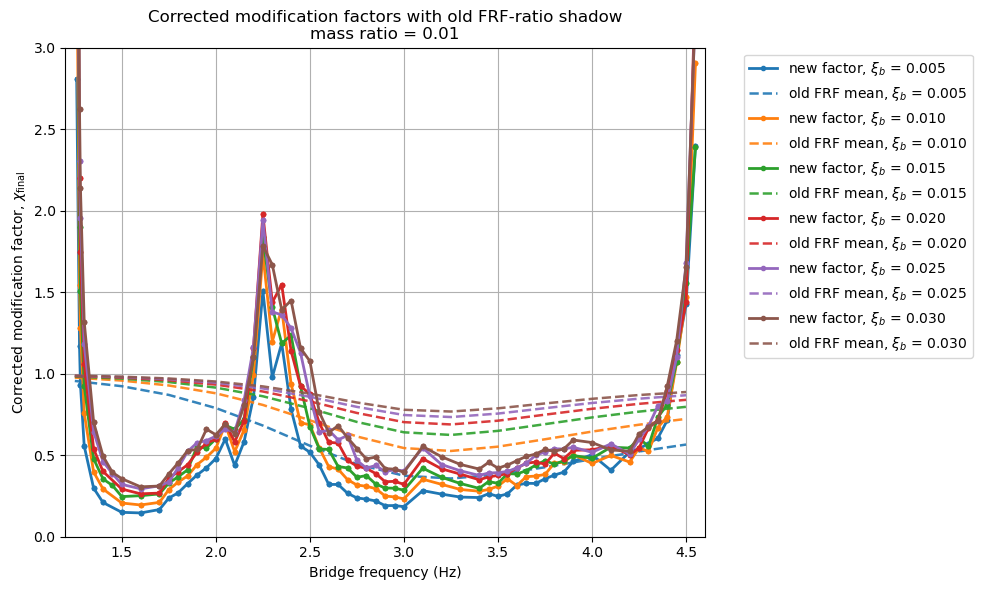

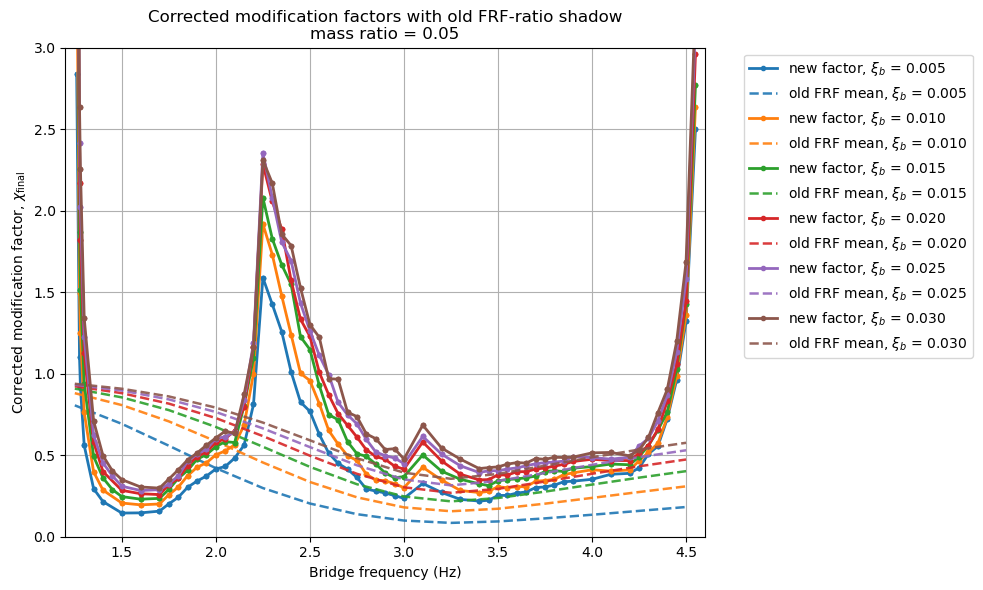

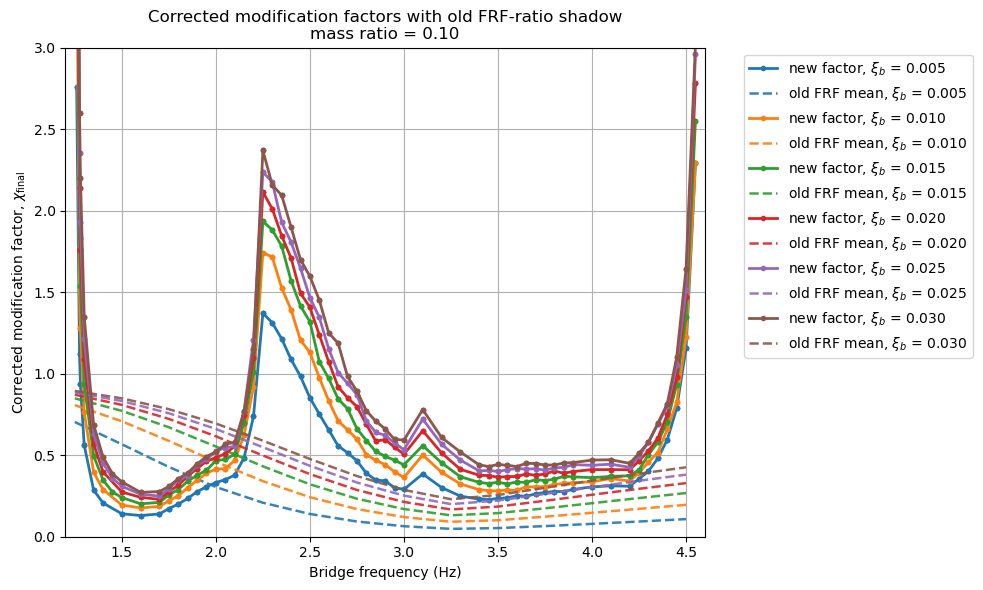

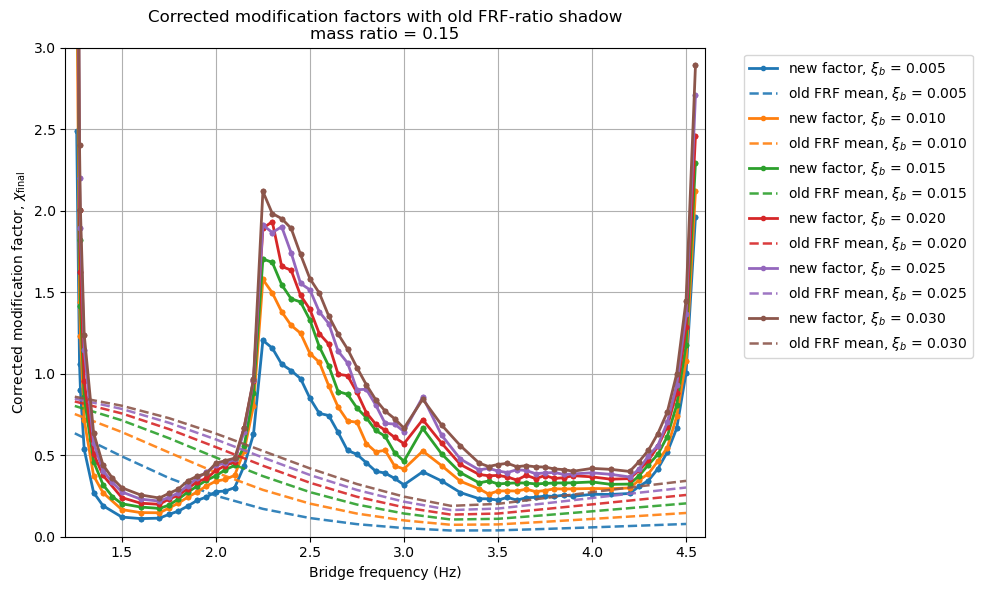

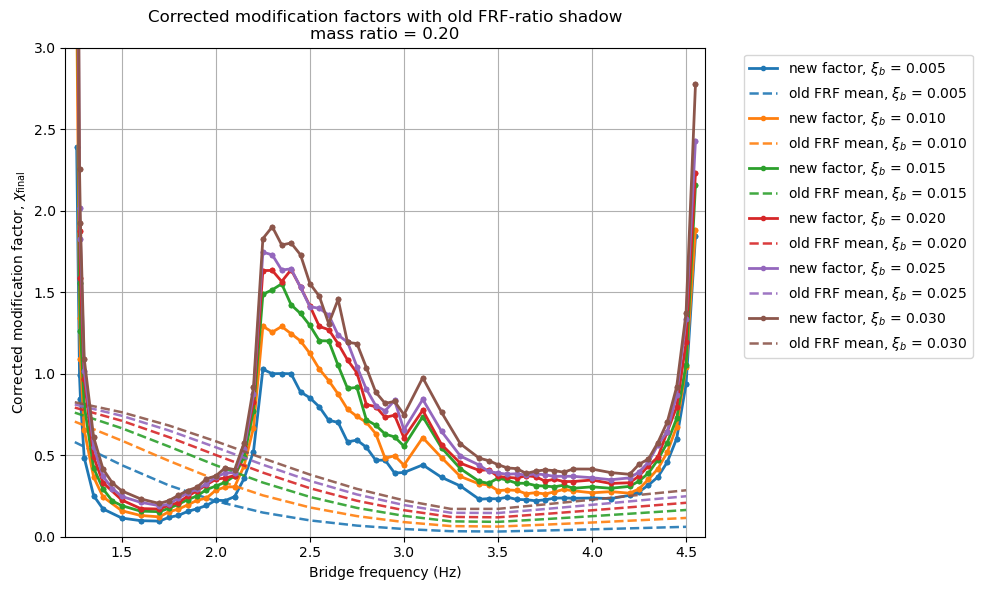

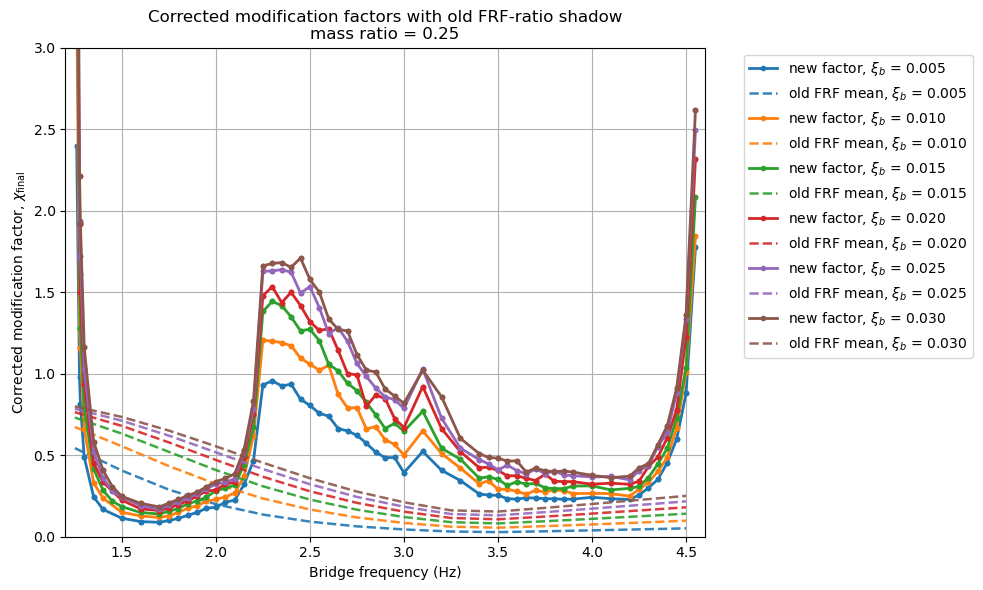

In [14]:
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ==================================================
# SETTINGS
# ==================================================

folder = Path(".")

PLOT_COLUMN = "final_modification_factor"
MEASURE_TO_PLOT = None

OLD_FRF_PKL = folder / "forcefactors_bridgeF_bridgedamp.pkl"

DAMPINGS_TO_COMPARE = [0.005, 0.010, 0.015, 0.020, 0.025, 0.030]

# Old FRF suggestion only for densities < 1
MAX_DENSITY_FOR_OLD_FRF = 1.0

SAVE_PLOTS = False

density_to_mass_ratio = {
    0.0333: 0.01,
    0.1667: 0.05,
    0.3333: 0.10,
    0.5000: 0.15,
    0.6667: 0.20,
    0.8333: 0.25,
    1.0000: 0.30,
}

ylabel_map = {
    "final_modification_factor": r"Corrected modification factor, $\chi_{\mathrm{final}}$",
    "initial_modification_factor": r"Initial modification factor, $\chi_0$",
    "residual_correction_factor": r"Residual correction factor, $\lambda$",
    "code_bias_mean": "Mean code bias",
    "simplified_bias_mean": "Mean simplified bias",
    "corrected_bias_mean": "Mean corrected bias",
}

ylabel = ylabel_map.get(PLOT_COLUMN, PLOT_COLUMN.replace("_", " "))

# ==================================================
# LOAD NEW CORRECTED MODIFICATION FACTORS
# ==================================================

pattern = re.compile(
    r"density(?P<density>\d+\.\d+)_"
    r"damping(?P<damping>\d+\.\d+)_"
    r"(?P<region>0S(?:125|456)?)_bias_summary\.pkl$"
)

pkl_files = sorted(folder.glob("density*_damping*_0S*_bias_summary.pkl"))

all_dfs = []

for file in pkl_files:
    match = pattern.match(file.name)

    if match is None:
        print(f"Skipping file because name does not match expected format: {file.name}")
        continue

    file_density = float(match.group("density"))
    file_damping = float(match.group("damping"))
    file_region = match.group("region")

    print("Loading new factor file:", file.name)

    with open(file, "rb") as f:
        df = pickle.load(f)

    if not isinstance(df, pd.DataFrame):
        df = pd.DataFrame(df)

    df = df.copy()

    df["source_file"] = file.name
    df["file_density"] = file_density
    df["file_damping"] = file_damping
    df["file_region"] = file_region

    if "target_density" not in df.columns:
        df["target_density"] = file_density

    if "target_beamdamp" not in df.columns:
        df["target_beamdamp"] = file_damping

    all_dfs.append(df)

if len(all_dfs) == 0:
    raise FileNotFoundError("No matching new modification-factor summary files were found.")

corrected_df = pd.concat(all_dfs, ignore_index=True)

needed_cols = [
    "bridge_frequency",
    "target_density",
    "target_beamdamp",
    PLOT_COLUMN,
]

for col in needed_cols:
    corrected_df[col] = pd.to_numeric(corrected_df[col], errors="coerce")

corrected_df = corrected_df.dropna(subset=needed_cols).copy()

corrected_df["density_key"] = corrected_df["target_density"].round(4)
corrected_df["damping_key"] = corrected_df["target_beamdamp"].round(3)

if MEASURE_TO_PLOT is not None:
    if "measure" not in corrected_df.columns:
        raise KeyError("MEASURE_TO_PLOT is set, but dataframe has no 'measure' column.")

    corrected_df = corrected_df[
        corrected_df["measure"].astype(str) == MEASURE_TO_PLOT
    ].copy()

    if corrected_df.empty:
        raise ValueError(f"No rows found for measure: {MEASURE_TO_PLOT}")

# Keep the intended frequency ranges from 0S, 0S125, and 0S456
# ==================================================
# KEEP FREQUENCY REGIONS INTELLIGENTLY
# ==================================================
# For old damping cases, you may have:
#   0S125 = low range
#   0S    = middle range
#   0S456 = high range
#
# For newer damping cases, such as 0.015, 0.025, 0.030,
#   0S already contains the full frequency range.
#
# Therefore:
#   - if only 0S exists for a density/damping case, keep all 0S frequencies
#   - if 0S125/0S456 also exist, stitch the regions as before

stitched_parts = []

for (damp_key, density_key), g in corrected_df.groupby(["damping_key", "density_key"]):

    available_regions = set(g["file_region"].dropna().unique())

    # Case A: only 0S exists -> keep full range
    if available_regions == {"0S"}:
        stitched_parts.append(g.copy())
        continue

    # Case B: multiple regional files exist -> stitch them
    g_keep = g[
        (
            (g["file_region"] == "0S125") &
            (g["bridge_frequency"] < 1.40)
        )
        |
        (
            (g["file_region"] == "0S") &
            (g["bridge_frequency"] >= 1.40) &
            (g["bridge_frequency"] <= 3.40)
        )
        |
        (
            (g["file_region"] == "0S456") &
            (g["bridge_frequency"] > 3.40)
        )
    ].copy()

    # Safety fallback:
    # If stitching removed everything for some unexpected naming case,
    # keep all available rows.
    if g_keep.empty:
        print(
            f"Warning: stitching removed all rows for "
            f"damping={damp_key}, density={density_key}. Keeping all rows."
        )
        g_keep = g.copy()

    stitched_parts.append(g_keep)

corrected_df = pd.concat(stitched_parts, ignore_index=True)


        
corrected_df = corrected_df.sort_values(
    ["damping_key", "density_key", "bridge_frequency"]
)

# Remove duplicates from multiple response measures
# ==================================================
# KEEP ALL RESPONSE MEASURES
# Remove only true duplicate rows
# ==================================================

corrected_df["measure"] = corrected_df["measure"].astype(str).str.strip()

corrected_df = corrected_df.drop_duplicates(
    subset=[
        "damping_key",
        "density_key",
        "bridge_frequency",
        "measure",
    ],
    keep="first"
).copy()

print("\nMeasure coverage after keeping all measures:")
print(corrected_df["measure"].value_counts().to_string())
# Keep only the damping ratios we want
corrected_df = corrected_df[
    corrected_df["damping_key"].isin([round(x, 3) for x in DAMPINGS_TO_COMPARE])
].copy()

print("\nNew corrected-factor coverage:")
print(
    corrected_df
    .groupby(["damping_key", "density_key"])["bridge_frequency"]
    .agg(["min", "max", "count"])
    .reset_index()
)

# ==================================================
# LOAD OLD FRF-RATIO PKL
# Your saved structure:
# results_all[beamdamp][bf][density]["accel_ratio"]
# ==================================================

if not OLD_FRF_PKL.exists():
    raise FileNotFoundError(f"Old FRF-ratio pkl not found: {OLD_FRF_PKL}")

with open(OLD_FRF_PKL, "rb") as f:
    old_data = pickle.load(f)

results_all = old_data["results_all"]

print("\nLoaded old FRF-ratio file:", OLD_FRF_PKL.name)
print("Saved damping values:", old_data.get("damping_values", "not found"))
print("Saved densities:", old_data.get("densities", "not found"))
print("Saved NUM_SIMULATIONS:", old_data.get("NUM_SIMULATIONS", "not found"))

# ==================================================
# EXTRACT OLD FRF RATIOS DIRECTLY FROM NESTED DICT
# ==================================================

frf_rows = []

for beamdamp, freq_dict in results_all.items():

    beamdamp_float = float(beamdamp)

    for bf, density_dict in freq_dict.items():

        bf_float = float(bf)

        for density, data in density_dict.items():

            density_float = float(density)

            if not isinstance(data, dict):
                print(f"Skipping non-dict entry: damping={beamdamp}, bf={bf}, density={density}")
                continue

            if "accel_ratio" not in data:
                print(f"Skipping entry with no accel_ratio: damping={beamdamp}, bf={bf}, density={density}")
                continue

            accel_values = np.asarray(data["accel_ratio"], dtype=float).ravel()

            for sim_id, accel_ratio in enumerate(accel_values):
                if np.isfinite(accel_ratio):
                    frf_rows.append({
                        "target_beamdamp": beamdamp_float,
                        "bridge_frequency": bf_float,
                        "target_density": density_float,
                        "simulation": sim_id,
                        "accel_ratio": float(accel_ratio),
                    })

frf_df = pd.DataFrame(frf_rows)

if frf_df.empty:
    raise ValueError("No old FRF accel_ratio values were extracted.")

frf_df["density_key"] = frf_df["target_density"].round(4)
frf_df["damping_key"] = frf_df["target_beamdamp"].round(3)

# Keep only the damping ratios we want
frf_df = frf_df[
    frf_df["damping_key"].isin([round(x, 3) for x in DAMPINGS_TO_COMPARE])
].copy()

# Old FRF overlay only for densities < 1
frf_df = frf_df[
    frf_df["target_density"] < MAX_DENSITY_FOR_OLD_FRF
].copy()

frf_summary = (
    frf_df
    .groupby(["damping_key", "density_key", "bridge_frequency"])["accel_ratio"]
    .agg(
        frf_mean="mean",
        frf_p5=lambda x: np.percentile(x, 5),
        frf_p50="median",
        frf_p95=lambda x: np.percentile(x, 95),
        n="count",
    )
    .reset_index()
)

print("\nOld FRF-ratio summary coverage:")
print(
    frf_summary
    .groupby(["damping_key", "density_key"])["bridge_frequency"]
    .agg(["min", "max", "count"])
    .reset_index()
)

# ==================================================
# PLOT: ONE FIGURE PER MASS RATIO, COMPARE 3 DAMPINGS
# ==================================================

for density in sorted(corrected_df["density_key"].dropna().unique()):

    # You said the FRF comparison is for densities less than 1
    if density >= MAX_DENSITY_FOR_OLD_FRF:
        continue

    mr = density_to_mass_ratio.get(round(float(density), 4), None)

    if mr is not None:
        title_density = f"mass ratio = {mr:.2f}"
        out_density = f"massratio{mr:.2f}"
    else:
        title_density = f"density = {density:.4f}"
        out_density = f"density{density:.4f}"

    plt.figure(figsize=(10, 6))

    for damp in DAMPINGS_TO_COMPARE:

        damp_key = round(damp, 3)

        # ---------------- New corrected factor ----------------
        sub = corrected_df[
            np.isclose(corrected_df["density_key"], density) &
            np.isclose(corrected_df["damping_key"], damp_key)
        ].copy()

        sub = sub.sort_values("bridge_frequency")

        if sub.empty:
            print(f"No corrected factor data for density={density:.4f}, damping={damp:.3f}")
            continue

        line = plt.plot(
            sub["bridge_frequency"].values,
            sub[PLOT_COLUMN].values,
            marker="o",
            markersize=3,
            linewidth=2,
            label=rf"new factor, $\xi_b$ = {damp:.3f}",
        )[0]

        line_color = line.get_color()

        # ---------------- Old FRF-ratio shadow ----------------
        frf_sub = frf_summary[
            np.isclose(frf_summary["density_key"], density) &
            np.isclose(frf_summary["damping_key"], damp_key)
        ].copy()

        # Limit old FRF to the plot frequency range
        frf_sub = frf_sub[
            (frf_sub["bridge_frequency"] >= 1.2) &
            (frf_sub["bridge_frequency"] <= 4.6)
        ].copy()

        frf_sub = frf_sub.sort_values("bridge_frequency")

        if not frf_sub.empty:
            plt.fill_between(
                frf_sub["bridge_frequency"].values,
                frf_sub["frf_p5"].values,
                frf_sub["frf_p95"].values,
                color=line_color,
                alpha=0.15,
                linewidth=0,
            )

            plt.plot(
                frf_sub["bridge_frequency"].values,
                frf_sub["frf_mean"].values,
                linestyle="--",
                linewidth=1.8,
                color=line_color,
                alpha=0.9,
                label=rf"old FRF mean, $\xi_b$ = {damp:.3f}",
            )
        else:
            print(f"No old FRF data for density={density:.4f}, damping={damp:.3f}")

    plt.xlabel("Bridge frequency (Hz)")
    plt.xlim(1.2, 4.6)

    plt.ylabel(ylabel)
    plt.ylim(0, 3.0)

    plt.title(
        "Corrected modification factors with old FRF-ratio shadow\n"
        + title_density
    )

    plt.grid(True)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()

    if SAVE_PLOTS:
        outname = f"compare_damping_old_FRF_shadow_{out_density}.png"
        plt.savefig(outname, dpi=300, bbox_inches="tight")
        print("Saved:", outname)

    plt.show()

Loading: density0.0333_damping0.005_0S125_bias_summary.pkl
Loading: density0.0333_damping0.005_0S456_bias_summary.pkl
Loading: density0.0333_damping0.005_0S_bias_summary.pkl
Loading: density0.0333_damping0.010_0S125_bias_summary.pkl
Loading: density0.0333_damping0.010_0S456_bias_summary.pkl
Loading: density0.0333_damping0.010_0S_bias_summary.pkl
Loading: density0.0333_damping0.015_0S_bias_summary.pkl
Loading: density0.0333_damping0.020_0S125_bias_summary.pkl
Loading: density0.0333_damping0.020_0S456_bias_summary.pkl
Loading: density0.0333_damping0.020_0S_bias_summary.pkl
Loading: density0.0333_damping0.025_0S_bias_summary.pkl
Loading: density0.0333_damping0.030_0S_bias_summary.pkl
Loading: density0.1667_damping0.005_0S125_bias_summary.pkl
Loading: density0.1667_damping0.005_0S456_bias_summary.pkl
Loading: density0.1667_damping0.005_0S_bias_summary.pkl
Loading: density0.1667_damping0.010_0S125_bias_summary.pkl
Loading: density0.1667_damping0.010_0S456_bias_summary.pkl
Loading: density0.

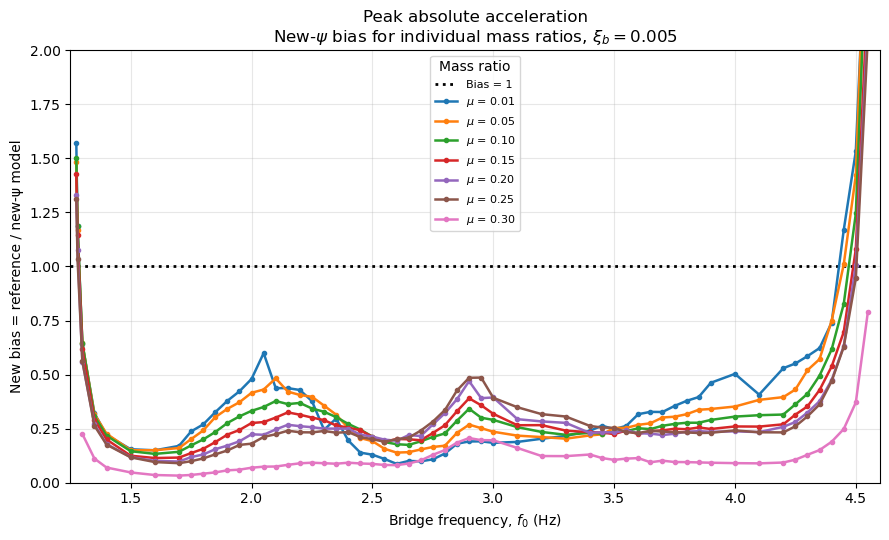

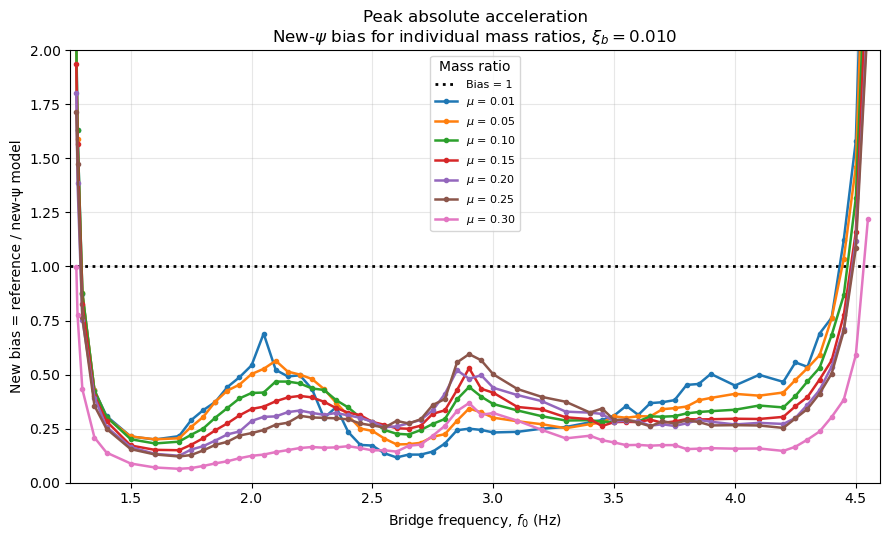

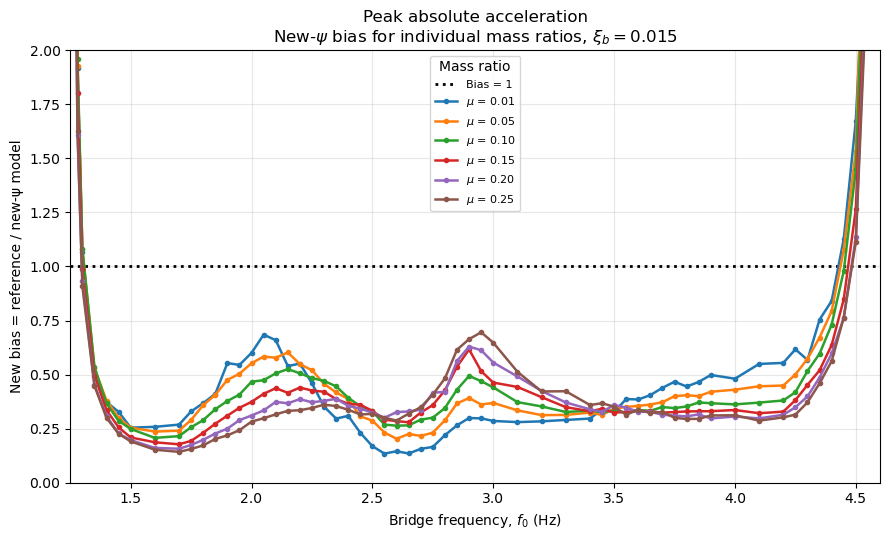

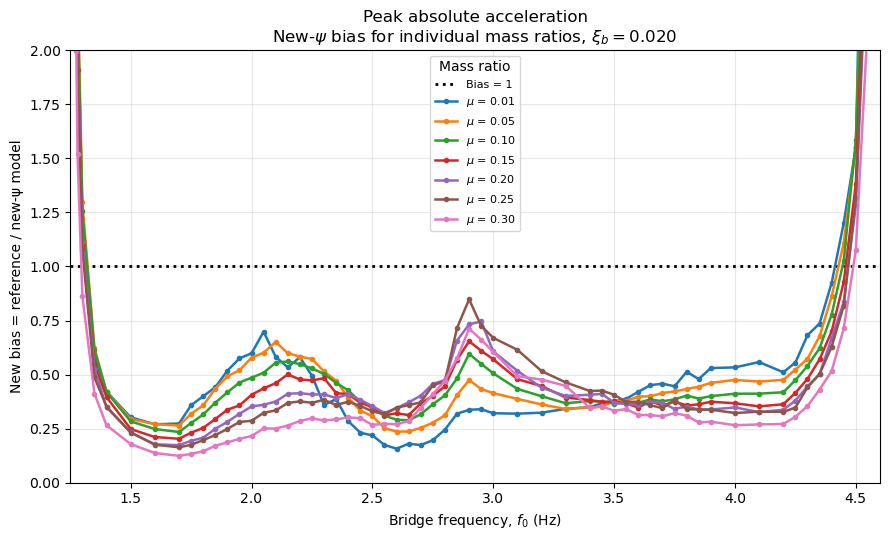

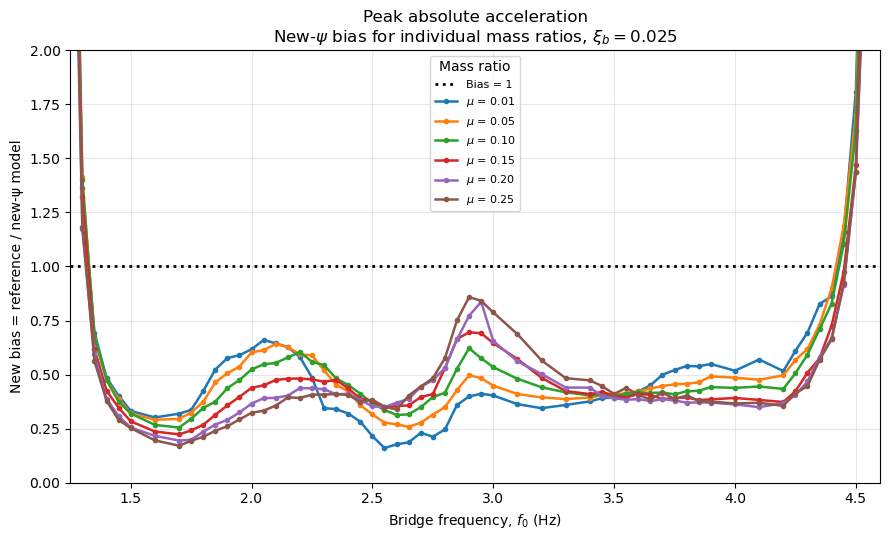

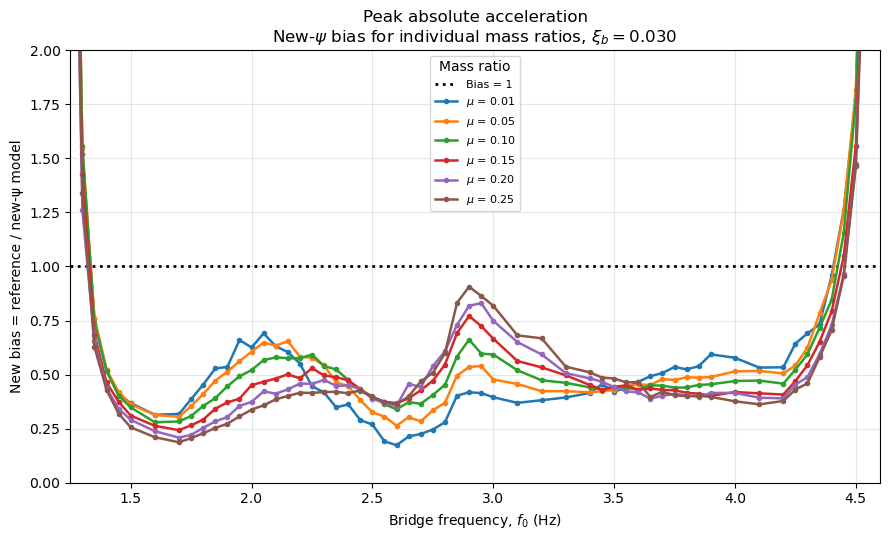

In [15]:
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path

# ==================================================
# SETTINGS
# ==================================================

folder = Path(".")

TARGET_DAMPINGS = [0.005, 0.010, 0.015, 0.020, 0.025, 0.030]

PLOT_FMIN = 1.25
PLOT_FMAX = 4.6

MEASURES_TO_PLOT = [
    "Peak absolute acceleration",
    # "95% absolute acceleration",
    # "Peak 1-sec RMS",
]

SAVE_PLOTS = False

YMIN = 0.05
YMAX = 10.0

EPS = 1e-12
PSI_MIN = 0.02

SHOW_ORIGINAL_CODE_CURVES = True
SHOW_NEWPSI_CURVES = True

density_to_mass_ratio = {
    0.0333: 0.01,
    0.1667: 0.05,
    0.3333: 0.10,
    0.5000: 0.15,
    0.6667: 0.20,
    0.8333: 0.25,
    1.0000: 0.30,
}

# ==================================================
# OLD EN1991 / SETRA psi FUNCTION
# ==================================================

def psi_w_h1_old(x):
    x = np.asarray(x, dtype=float)
    psi = np.zeros_like(x)

    # 1.25–1.70 : 0 -> 1
    m = (x >= 1.25) & (x < 1.70)
    psi[m] = (x[m] - 1.25) / (1.70 - 1.25)

    # 1.70–2.10 : 1
    m = (x >= 1.70) & (x <= 2.10)
    psi[m] = 1.0

    # 2.10–2.30 : 1 -> 0
    m = (x > 2.10) & (x < 2.30)
    psi[m] = 1.0 - (x[m] - 2.10) / (2.30 - 2.10)

    # 2.50–3.40 : 0 -> 0.25
    m = (x > 2.50) & (x < 3.40)
    psi[m] = 0.25 * (x[m] - 2.50) / (3.40 - 2.50)

    # 3.40–4.20 : 0.25
    m = (x >= 3.40) & (x <= 4.20)
    psi[m] = 0.25

    # 4.20–4.60 : 0.25 -> 0
    m = (x > 4.20) & (x <= 4.60)
    psi[m] = 0.25 * (1.0 - (x[m] - 4.20) / (4.60 - 4.20))

    # Minimum rule between 2.25 and 3.0 Hz
    m = (x >= 2.25) & (x <= 3.0)
    psi[m] = np.maximum(psi[m], 0.25)

    return psi

# ==================================================
# NEW UPPER-ENVELOPE SHIFTED psi FUNCTION
# ==================================================

def psi_env_new(x):
    """
    Upper envelope of shifted psi.
    Piecewise equation from the shifted coupled-psi envelope.
    """

    x = np.asarray(x, dtype=float)
    psi = np.zeros_like(x)

    # 1.258 <= f0 <= 1.709
    m = (x >= 1.258) & (x <= 1.709)
    psi[m] = 2.2039 * x[m] - 2.7686

    # 1.709 <= f0 <= 1.711
    m = (x > 1.709) & (x <= 1.711)
    psi[m] = 0.9382 * x[m] - 0.6056

    # 1.711 <= f0 <= 2.566
    m = (x > 1.711) & (x <= 2.566)
    psi[m] = 1.0

    # 2.566 <= f0 <= 2.568
    m = (x > 2.566) & (x <= 2.568)
    psi[m] = -0.6319 * x[m] + 2.6213

    # 2.568 <= f0 <= 2.872
    m = (x > 2.568) & (x <= 2.872)
    psi[m] = -2.4653 * x[m] + 7.3299

    # 2.872 <= f0 <= 2.874
    m = (x > 2.872) & (x <= 2.874)
    psi[m] = -0.0991 * x[m] + 0.5347

    # 2.874 <= f0 <= 4.191
    m = (x > 2.874) & (x <= 4.191)
    psi[m] = 0.25

    # 4.191 <= f0 <= 4.193
    m = (x > 4.191) & (x <= 4.193)
    psi[m] = -0.0880 * x[m] + 0.6190

    # 4.193 <= f0 <= 4.593
    m = (x > 4.193) & (x <= 4.593)
    psi[m] = -0.6250 * x[m] + 2.8706

    psi = np.clip(psi, 0.0, 1.0)

    return psi

# ==================================================
# LOAD ALL 0S, 0S125, 0S456 SUMMARY FILES
# ==================================================

pattern = re.compile(
    r"density(?P<density>\d+\.\d+)_"
    r"damping(?P<damping>\d+\.\d+)_"
    r"(?P<region>0S(?:125|456)?)_bias_summary\.pkl$"
)

pkl_files = sorted(folder.glob("density*_damping*_0S*_bias_summary.pkl"))

all_dfs = []

for file in pkl_files:
    match = pattern.match(file.name)

    if match is None:
        print(f"Skipping file because name does not match expected format: {file.name}")
        continue

    file_density = float(match.group("density"))
    file_damping = float(match.group("damping"))
    file_region = match.group("region")

    print("Loading:", file.name)

    with open(file, "rb") as f:
        df = pickle.load(f)

    if not isinstance(df, pd.DataFrame):
        df = pd.DataFrame(df)

    df = df.copy()

    df["source_file"] = file.name
    df["file_density"] = file_density
    df["file_damping"] = file_damping
    df["file_region"] = file_region

    if "target_density" not in df.columns:
        df["target_density"] = file_density

    if "target_beamdamp" not in df.columns:
        df["target_beamdamp"] = file_damping

    all_dfs.append(df)

if len(all_dfs) == 0:
    raise FileNotFoundError("No matching summary files were found.")

corrected_df = pd.concat(all_dfs, ignore_index=True)

print("\nLoaded combined dataframe shape:", corrected_df.shape)

# ==================================================
# CLEAN DATA
# ==================================================

required_columns = [
    "bridge_frequency",
    "target_density",
    "target_beamdamp",
    "measure",
    "code_bias_mean",
    "code_bias_p5",
    "code_bias_p95",
]

missing_columns = [c for c in required_columns if c not in corrected_df.columns]

if missing_columns:
    raise KeyError(f"Missing columns in corrected_df: {missing_columns}")

for col in [
    "bridge_frequency",
    "target_density",
    "target_beamdamp",
    "code_bias_mean",
    "code_bias_p5",
    "code_bias_p95",
]:
    corrected_df[col] = pd.to_numeric(corrected_df[col], errors="coerce")

corrected_df["measure"] = corrected_df["measure"].astype(str).str.strip()

corrected_df = corrected_df.dropna(subset=required_columns).copy()

corrected_df["density_key"] = corrected_df["target_density"].round(4)
corrected_df["damping_key"] = corrected_df["target_beamdamp"].round(3)

# ==================================================
# KEEP FREQUENCY REGIONS BASED ON FILE CONTENT
# ==================================================

# ==================================================
# KEEP FREQUENCY REGIONS INTELLIGENTLY
# ==================================================
# Older damping cases may have:
#   0S125 = low range
#   0S    = middle range
#   0S456 = high range
#
# Newer damping cases, e.g. 0.015, 0.025, 0.030,
# may have full frequency range stored as 0S.
#
# So:
#   - if only 0S exists for a density/damping pair, keep all 0S rows
#   - if regional files exist, stitch 0S125, 0S, and 0S456

stitched_parts = []

for (damp_key, density_key), g in corrected_df.groupby(["damping_key", "density_key"]):

    available_regions = set(g["file_region"].dropna().unique())

    # Case A: only 0S exists, keep full frequency range
    if available_regions == {"0S"}:
        stitched_parts.append(g.copy())
        continue

    # Case B: regional files exist, stitch them
    g_keep = g[
        (
            (g["file_region"] == "0S125") &
            (g["bridge_frequency"] < 1.40)
        )
        |
        (
            (g["file_region"] == "0S") &
            (g["bridge_frequency"] >= 1.40) &
            (g["bridge_frequency"] <= 3.40)
        )
        |
        (
            (g["file_region"] == "0S456") &
            (g["bridge_frequency"] > 3.40)
        )
    ].copy()

    if g_keep.empty:
        print(
            f"Warning: no stitched rows for damping={damp_key}, "
            f"density={density_key}. Keeping all rows."
        )
        g_keep = g.copy()

    stitched_parts.append(g_keep)

corrected_df = pd.concat(stitched_parts, ignore_index=True)

# Remove duplicate rows if same frequency appears multiple times
corrected_df = corrected_df.sort_values(
    ["damping_key", "density_key", "measure", "bridge_frequency"]
)

corrected_df = corrected_df.drop_duplicates(
    subset=["damping_key", "density_key", "measure", "bridge_frequency"],
    keep="first"
).copy()

# ==================================================
# FILTER TARGET DAMPINGS AND FREQUENCY RANGE
# ==================================================

df = corrected_df.copy()

damping_mask = np.zeros(len(df), dtype=bool)

for damp in TARGET_DAMPINGS:
    damping_mask |= np.isclose(df["target_beamdamp"], damp)

plot_all_df = df[damping_mask].copy()

plot_all_df = plot_all_df[
    (plot_all_df["bridge_frequency"] >= PLOT_FMIN)
    & (plot_all_df["bridge_frequency"] <= PLOT_FMAX)
].copy()

if plot_all_df.empty:
    raise ValueError(
        "No rows found after filtering. Check TARGET_DAMPINGS and frequency range."
    )

# ==================================================
# CALCULATE OLD psi, NEW psi, AND NEW-psi BIAS
# ==================================================
# code_bias = reference / old_code_model
#
# old_code_model uses psi_old
# new_code_model uses psi_env
#
# new_code_model = old_code_model * psi_env / psi_old
#
# therefore:
#
# newpsi_bias = code_bias * psi_old / psi_env
# ==================================================

plot_all_df["psi_old"] = psi_w_h1_old(
    plot_all_df["bridge_frequency"].to_numpy()
)

plot_all_df["psi_env"] = psi_env_new(
    plot_all_df["bridge_frequency"].to_numpy()
)

valid_psi = (
    np.isfinite(plot_all_df["psi_old"])
    & np.isfinite(plot_all_df["psi_env"])
    & (plot_all_df["psi_old"] > PSI_MIN)
    & (plot_all_df["psi_env"] > PSI_MIN)
)

plot_all_df["psi_ratio_old_to_env"] = np.nan
plot_all_df.loc[valid_psi, "psi_ratio_old_to_env"] = (
    plot_all_df.loc[valid_psi, "psi_old"]
    / plot_all_df.loc[valid_psi, "psi_env"]
)

for stat in ["mean", "p5", "p95"]:

    old_col = f"code_bias_{stat}"
    new_col = f"newpsi_bias_{stat}"
    hsi_col = f"hsi_factor_{stat}"

    plot_all_df[new_col] = (
        plot_all_df[old_col]
        * plot_all_df["psi_ratio_old_to_env"]
    )

    plot_all_df[new_col] = (
        plot_all_df[new_col]
        .replace([np.inf, -np.inf], np.nan)
    )

    # HSI factor needed after using the new psi model
    plot_all_df[hsi_col] = plot_all_df[new_col]

# ==================================================
# ADD MASS RATIO COLUMN
# ==================================================

plot_all_df["mass_ratio"] = plot_all_df["density_key"].map(
    lambda d: density_to_mass_ratio.get(round(float(d), 4), np.nan)
)

# ==================================================
# PRINT CHECK
# ==================================================

print("\nAvailable data after filtering:")
print(
    plot_all_df
    .groupby(["damping_key", "density_key", "measure"])["bridge_frequency"]
    .agg(["min", "max", "count"])
    .reset_index()
    .to_string(index=False)
)

# ==================================================
# PLOT FUNCTION: ONE FIGURE PER DAMPING RATIO
# ONLY NEW-psi BIAS
# ==================================================

def plot_newpsi_bias_one_damping(measure_name, damp):

    measure_df = plot_all_df[
        plot_all_df["measure"].astype(str).str.strip() == measure_name
    ].copy()

    sub_damp = measure_df[
        np.isclose(measure_df["target_beamdamp"], damp)
    ].copy()

    if sub_damp.empty:
        print(f"No data for measure={measure_name}, damping={damp:.3f}")
        return

    plt.figure(figsize=(9, 5.5))

    plt.axhline(
        1.0,
        linestyle=":",
        linewidth=2.0,
        color="black",
        label="Bias = 1",
    )

    # --------------------------------------------------
    # Plot only new-psi bias for each mass ratio
    # --------------------------------------------------

    for density in sorted(sub_damp["density_key"].dropna().unique()):

        sub = sub_damp[
            np.isclose(sub_damp["density_key"], density)
        ].copy()

        sub = sub.sort_values("bridge_frequency")

        mr = density_to_mass_ratio.get(round(float(density), 4), None)

        if mr is not None:
            label = rf"$\mu$ = {mr:.2f}"
        else:
            label = f"density = {density:.4f}"

        plt.plot(
            sub["bridge_frequency"],
            sub["newpsi_bias_mean"],
            marker="o",
            markersize=3,
            linewidth=1.8,
            label=label,
        )

    # --------------------------------------------------
    # Formatting
    # --------------------------------------------------

    plt.xlabel(r"Bridge frequency, $f_0$ (Hz)")
    plt.ylabel("New bias = reference / new-ψ model")

    plt.title(
        f"{measure_name}\n"
        rf"New-$\psi$ bias for individual mass ratios, $\xi_b = {damp:.3f}$"
    )

    plt.xlim(1.25, 4.6)
    plt.yscale("linear")
    plt.ylim(0, 2)

    plt.grid(True, which="both", alpha=0.30)

    plt.legend(
        loc="best",
        fontsize=8,
        title="Mass ratio",
    )

    plt.tight_layout()

    if SAVE_PLOTS:
        safe_measure = (
            measure_name
            .replace(" ", "_")
            .replace("%", "pct")
            .replace("/", "_")
        )

        fig_name = (
            f"newpsi_bias_{safe_measure}_"
            f"damping{damp:.3f}.png"
        )

        plt.savefig(fig_name, dpi=300, bbox_inches="tight")
        print("Saved:", fig_name)

    plt.show()
# ==================================================
# MAKE ONE SEPARATE FIGURE PER DAMPING RATIO
# ==================================================

# ==================================================
# MAKE ONE SEPARATE FIGURE PER DAMPING RATIO
# ==================================================

for measure_name in MEASURES_TO_PLOT:
    for damp in TARGET_DAMPINGS:
        plot_newpsi_bias_one_damping(measure_name, damp)

MASS-RATIO BAYESIAN OUTPUT
material  mu_center  mu_lower  mu_upper  N_population_material  n_known_mass_ratio  observed_count_in_bin  p_material_mean  p_mu_bin_mean  p_mu_domain_mean
   Steel       0.01     0.000     0.030                    152                   7                      0         0.597656       0.111111          0.777778
   Steel       0.05     0.030     0.075                    152                   7                      1         0.597656       0.111111          0.777778
   Steel       0.10     0.075     0.125                    152                   7                      1         0.597656       0.111111          0.777778
   Steel       0.15     0.125     0.175                    152                   7                      1         0.597656       0.111111          0.777778
   Steel       0.20     0.175     0.225                    152                   7                      2         0.597656       0.222222          0.777778
   Steel       0.25     0.225     0.2

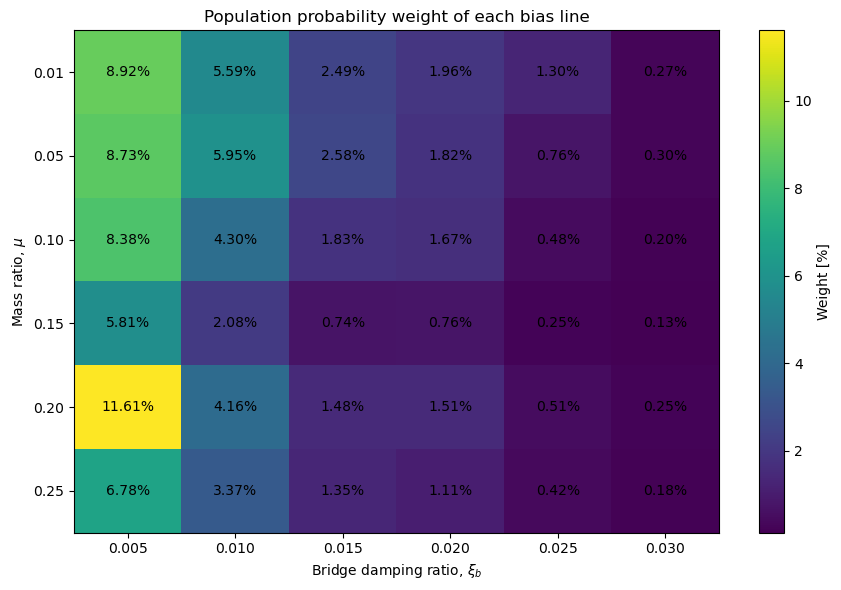

In [17]:
# ============================================================
# POPULATION WEIGHTS FOR EACH (mu, xi_b) BIAS LINE
# ============================================================
#
# INPUT FILES:
#
#   1. mass_ratio_weight_inputs.csv
#   2. damping_weight_inputs.csv
#
# These files come from the two Bayesian models.
#
# MASS-RATIO CSV provides:
#
#   P(material = m)
#   P(mu in basket j | material = m)
#
# DAMPING CSV provides:
#
#   P(xi_b in basket k | material = m)
#
#
# ASSUMPTION:
#
#   mu independent of xi_b conditional on material
#
#   P(mu_j, xi_k | m)
#   =
#   P(mu_j | m) P(xi_k | m)
#
#
# RAW WEIGHT:
#
#   w*_jk
#   =
#   sum_m [
#       P(m)
#       P(mu_j | m)
#       P(xi_k | m)
#   ]
#
#
# FINAL NORMALISED WEIGHT:
#
#   w_jk
#   =
#   w*_jk / sum_jk(w*_jk)
#
#
# Therefore:
#
#   sum_jk w_jk = 1
#
# ============================================================


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. FILE PATHS
# ============================================================

MASS_RATIO_FILE = "mass_ratio_weight_inputs.csv"
DAMPING_FILE = "damping_weight_inputs.csv"


# ============================================================
# 2. LOAD THE TWO BAYESIAN OUTPUT FILES
# ============================================================

mu_df = pd.read_csv(
    MASS_RATIO_FILE,
    encoding="utf-8-sig"
)

xi_df = pd.read_csv(
    DAMPING_FILE,
    encoding="utf-8-sig"
)


print("==========================================")
print("MASS-RATIO BAYESIAN OUTPUT")
print("==========================================")

print(mu_df.head(12).to_string(index=False))


print("\n==========================================")
print("DAMPING BAYESIAN OUTPUT")
print("==========================================")

print(xi_df.head(12).to_string(index=False))


# ============================================================
# 3. REQUIRED COLUMNS
# ============================================================

required_mu_columns = [
    "material",
    "mu_center",
    "mu_lower",
    "mu_upper",
    "p_material_mean",
    "p_mu_bin_mean",
]

required_xi_columns = [
    "material",
    "xi_center",
    "xi_lower",
    "xi_upper",
    "p_xi_mean",
]


missing_mu = [
    c for c in required_mu_columns
    if c not in mu_df.columns
]

missing_xi = [
    c for c in required_xi_columns
    if c not in xi_df.columns
]


if missing_mu:

    raise KeyError(
        "Missing columns in mass-ratio CSV: "
        f"{missing_mu}"
    )


if missing_xi:

    raise KeyError(
        "Missing columns in damping CSV: "
        f"{missing_xi}"
    )


# ============================================================
# 4. MATERIAL GROUPS
# ============================================================

MATERIALS = [
    "Steel",
    "Concrete",
    "Steel-concrete composite",
    "FRP",
    "Timber",
    "Other",
]


print("\n==========================================")
print("MATERIAL CHECK")
print("==========================================")

print(
    "Mass-ratio materials:",
    sorted(mu_df["material"].unique())
)

print(
    "Damping materials:",
    sorted(xi_df["material"].unique())
)


# Make sure every required material exists in both files

missing_mu_materials = [
    m for m in MATERIALS
    if m not in mu_df["material"].unique()
]

missing_xi_materials = [
    m for m in MATERIALS
    if m not in xi_df["material"].unique()
]


if missing_mu_materials:

    raise ValueError(
        "Materials missing from mass-ratio CSV: "
        f"{missing_mu_materials}"
    )


if missing_xi_materials:

    raise ValueError(
        "Materials missing from damping CSV: "
        f"{missing_xi_materials}"
    )


print("\nAll six material groups found in both files.")


# ============================================================
# 5. GET THE ACTUAL mu AND xi INPUT POINTS
# ============================================================

MU_VALUES = np.sort(
    mu_df["mu_center"].unique()
)

XI_VALUES = np.sort(
    xi_df["xi_center"].unique()
)


print("\n==========================================")
print("BIAS GRID")
print("==========================================")

print("mu values:")
print(MU_VALUES)

print("\nxi_b values:")
print(XI_VALUES)

print(
    f"\nNumber of bias lines = "
    f"{len(MU_VALUES)} x {len(XI_VALUES)} "
    f"= {len(MU_VALUES) * len(XI_VALUES)}"
)


# ============================================================
# 6. CHECK P(material)
#
# p_material_mean is repeated for each mu basket.
# Extract one value per material.
# ============================================================

material_probability = (
    mu_df[
        [
            "material",
            "p_material_mean"
        ]
    ]
    .drop_duplicates()
    .set_index("material")
    ["p_material_mean"]
)


print("\n==========================================")
print("POSTERIOR MEAN MATERIAL PROBABILITIES")
print("==========================================")

print(material_probability)


print(
    "\nSum P(material) =",
    material_probability.sum()
)


# ============================================================
# 7. CHECK MASS-RATIO BASKET PROBABILITIES
# ============================================================

print("\n==========================================")
print("MASS-RATIO BASKET PROBABILITIES")
print("P(mu basket | material)")
print("==========================================")

mu_probability_matrix = (
    mu_df.pivot(
        index="material",
        columns="mu_center",
        values="p_mu_bin_mean"
    )
    .reindex(MATERIALS)
    .reindex(columns=MU_VALUES)
)


print(
    mu_probability_matrix.round(5)
)


print("\nSum of represented mu probability by material:")

print(
    mu_probability_matrix
    .sum(axis=1)
    .round(5)
)


# ============================================================
# 8. CHECK DAMPING BASKET PROBABILITIES
# ============================================================

print("\n==========================================")
print("DAMPING BASKET PROBABILITIES")
print("P(xi basket | material)")
print("==========================================")

xi_probability_matrix = (
    xi_df.pivot(
        index="material",
        columns="xi_center",
        values="p_xi_mean"
    )
    .reindex(MATERIALS)
    .reindex(columns=XI_VALUES)
)


print(
    xi_probability_matrix.round(5)
)


print("\nSum of represented xi probability by material:")

print(
    xi_probability_matrix
    .sum(axis=1)
    .round(5)
)


# ============================================================
# 9. CALCULATE RAW WEIGHTS
# ============================================================
#
# For every (mu_j, xi_k):
#
# w*_jk
# =
# sum_m
# [
#     P(m)
#     *
#     P(mu_j | m)
#     *
#     P(xi_k | m)
# ]
#
# ============================================================

weight_rows = []


for mu in MU_VALUES:

    for xi in XI_VALUES:

        material_contributions = []

        row = {
            "mu": mu,
            "xi_b": xi,
        }


        for mat in MATERIALS:

            P_m = (
                material_probability.loc[mat]
            )

            P_mu_given_m = (
                mu_probability_matrix
                .loc[mat, mu]
            )

            P_xi_given_m = (
                xi_probability_matrix
                .loc[mat, xi]
            )


            contribution = (
                P_m
                *
                P_mu_given_m
                *
                P_xi_given_m
            )


            material_contributions.append(
                contribution
            )


            # Save contribution from each material
            row[
                f"contribution_{mat}"
            ] = contribution


        raw_weight = np.sum(
            material_contributions
        )


        row["raw_weight"] = raw_weight

        weight_rows.append(
            row
        )


weights_df = pd.DataFrame(
    weight_rows
)


# ============================================================
# 10. RAW WEIGHT SUM
# ============================================================

raw_weight_sum = (
    weights_df["raw_weight"].sum()
)


print("\n==========================================")
print("RAW WEIGHT SUM")
print("==========================================")

print(
    f"Sum raw weights = "
    f"{raw_weight_sum:.8f}"
)


print(
    "\nThis does NOT necessarily equal 1 because "
    "our bias grid only represents a restricted "
    "mu-xi domain."
)


# ============================================================
# 11. NORMALISE WEIGHTS
#
# Supervisor requirement:
#
# sum W = 1
# ============================================================

if raw_weight_sum <= 0:

    raise ValueError(
        "Raw weights sum to zero."
    )


weights_df["weight"] = (
    weights_df["raw_weight"]
    /
    raw_weight_sum
)


weights_df["weight_percent"] = (
    100
    *
    weights_df["weight"]
)


# ============================================================
# 12. FINAL CHECK
# ============================================================

print("\n==========================================")
print("NORMALISED WEIGHT CHECK")
print("==========================================")

print(
    f"Sum W = "
    f"{weights_df['weight'].sum():.12f}"
)


# ============================================================
# 13. DISPLAY THE 36 FINAL WEIGHTS
# ============================================================

print("\n==========================================")
print("FINAL 36 BIAS-LINE WEIGHTS")
print("==========================================")

print(
    weights_df[
        [
            "mu",
            "xi_b",
            "raw_weight",
            "weight",
            "weight_percent",
        ]
    ]
    .to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# ============================================================
# 14. MAKE 6 x 6 WEIGHT MATRIX
#
# rows    = mu
# columns = xi_b
# ============================================================

W_matrix = (
    weights_df.pivot(
        index="mu",
        columns="xi_b",
        values="weight"
    )
    .reindex(
        index=MU_VALUES,
        columns=XI_VALUES
    )
)


W_percent_matrix = (
    100
    *
    W_matrix
)


print("\n==========================================")
print("WEIGHT MATRIX")
print("rows = mu")
print("columns = xi_b")
print("==========================================")

print(
    W_matrix.round(6)
)


print("\n==========================================")
print("WEIGHT MATRIX [%]")
print("==========================================")

print(
    W_percent_matrix.round(2)
)


# ============================================================
# 15. MARGINAL WEIGHTS
#
# Useful diagnostic:
#
# sum across xi -> importance of each mu
#
# sum across mu -> importance of each xi
# ============================================================

mu_marginal = (
    W_matrix.sum(axis=1)
)

xi_marginal = (
    W_matrix.sum(axis=0)
)


print("\n==========================================")
print("MARGINAL WEIGHT BY MASS RATIO")
print("==========================================")

for mu, w in mu_marginal.items():

    print(
        f"mu = {mu:.3f} : "
        f"{w:.6f} "
        f"({100*w:.2f}%)"
    )


print("\n==========================================")
print("MARGINAL WEIGHT BY DAMPING")
print("==========================================")

for xi, w in xi_marginal.items():

    print(
        f"xi = {xi:.3f} : "
        f"{w:.6f} "
        f"({100*w:.2f}%)"
    )


# ============================================================
# 16. SHOW MATERIAL CONTRIBUTIONS TO EACH LINE
# ============================================================

contribution_columns = [
    f"contribution_{mat}"
    for mat in MATERIALS
]


# Convert raw material contributions into
# contribution to FINAL normalised population weight

for col in contribution_columns:

    weights_df[
        col + "_normalised"
    ] = (
        weights_df[col]
        /
        raw_weight_sum
    )


# ============================================================
# 17. SAVE FINAL OUTPUT
# ============================================================

weights_df.to_csv(
    "bias_line_weights.csv",
    index=False,
    encoding="utf-8-sig"
)


W_matrix.to_csv(
    "bias_line_weight_matrix.csv",
    encoding="utf-8-sig"
)


W_percent_matrix.to_csv(
    "bias_line_weight_matrix_percent.csv",
    encoding="utf-8-sig"
)


print("\n==========================================")
print("FILES SAVED")
print("==========================================")

print(
    "bias_line_weights.csv"
)

print(
    "bias_line_weight_matrix.csv"
)

print(
    "bias_line_weight_matrix_percent.csv"
)


# ============================================================
# 18. PLOT WEIGHT MATRIX
# ============================================================

fig, ax = plt.subplots(
    figsize=(9, 6)
)


im = ax.imshow(
    W_percent_matrix.to_numpy(),
    aspect="auto"
)


ax.set_xticks(
    np.arange(
        len(XI_VALUES)
    )
)

ax.set_xticklabels(
    [
        f"{x:.3f}"
        for x in XI_VALUES
    ]
)


ax.set_yticks(
    np.arange(
        len(MU_VALUES)
    )
)

ax.set_yticklabels(
    [
        f"{x:.2f}"
        for x in MU_VALUES
    ]
)


ax.set_xlabel(
    r"Bridge damping ratio, $\xi_b$"
)

ax.set_ylabel(
    r"Mass ratio, $\mu$"
)

ax.set_title(
    "Population probability weight of each bias line"
)


# Put percentages inside cells

for i in range(
    len(MU_VALUES)
):

    for j in range(
        len(XI_VALUES)
    ):

        value = (
            W_percent_matrix
            .iloc[i, j]
        )

        ax.text(
            j,
            i,
            f"{value:.2f}%",
            ha="center",
            va="center"
        )


fig.colorbar(
    im,
    ax=ax,
    label="Weight [%]"
)


plt.tight_layout()
plt.show()


INPUT CHECK PASSED

Number of retained combinations = 36
Sum of population weights = 1.000000000000

ROUGH DIRECT psi-CORRECTION POINTS
C_raw = max new-psi bias
      mu     xi_b        w    C_raw
0.010000 0.005000 0.089189 0.599178
0.010000 0.010000 0.055889 0.689417
0.010000 0.015000 0.024922 0.684406
0.010000 0.020000 0.019567 0.698394
0.010000 0.025000 0.012960 0.659587
0.010000 0.030000 0.002657 0.690646
0.050000 0.005000 0.087295 0.482580
0.050000 0.010000 0.059508 0.564016
0.050000 0.015000 0.025780 0.602576
0.050000 0.020000 0.018153 0.650942
0.050000 0.025000 0.007550 0.641518
0.050000 0.030000 0.003005 0.654430
0.100000 0.005000 0.083833 0.377778
0.100000 0.010000 0.042961 0.467767
0.100000 0.015000 0.018284 0.525158
0.100000 0.020000 0.016685 0.595964
0.100000 0.025000 0.004755 0.621882
0.100000 0.030000 0.002020 0.661586
0.150000 0.005000 0.058051 0.390304
0.150000 0.010000 0.020782 0.530048
0.150000 0.015000 0.007420 0.616370
0.150000 0.020000 0.007573 0.653972
0.150000 0

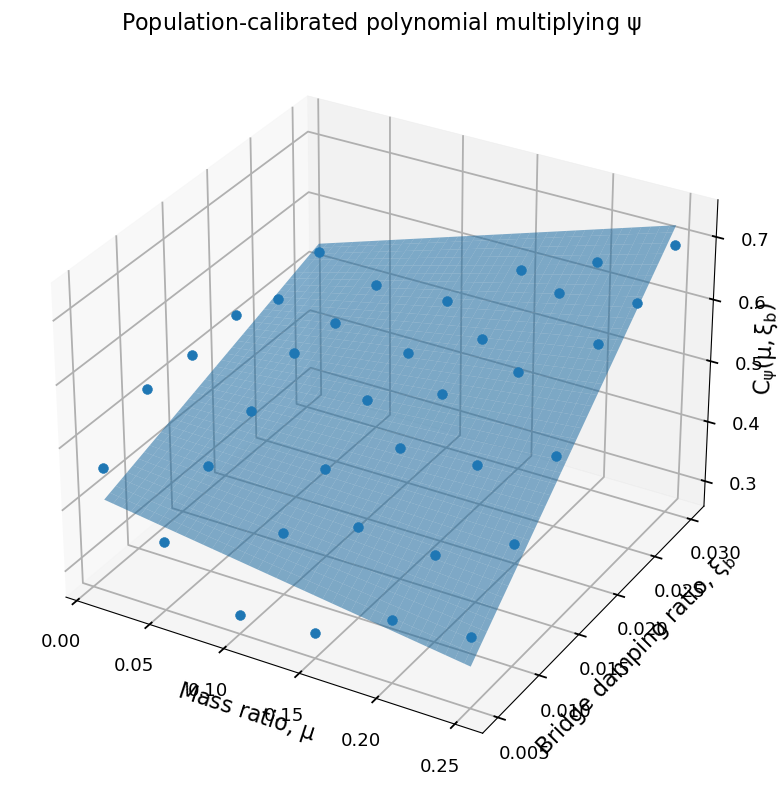

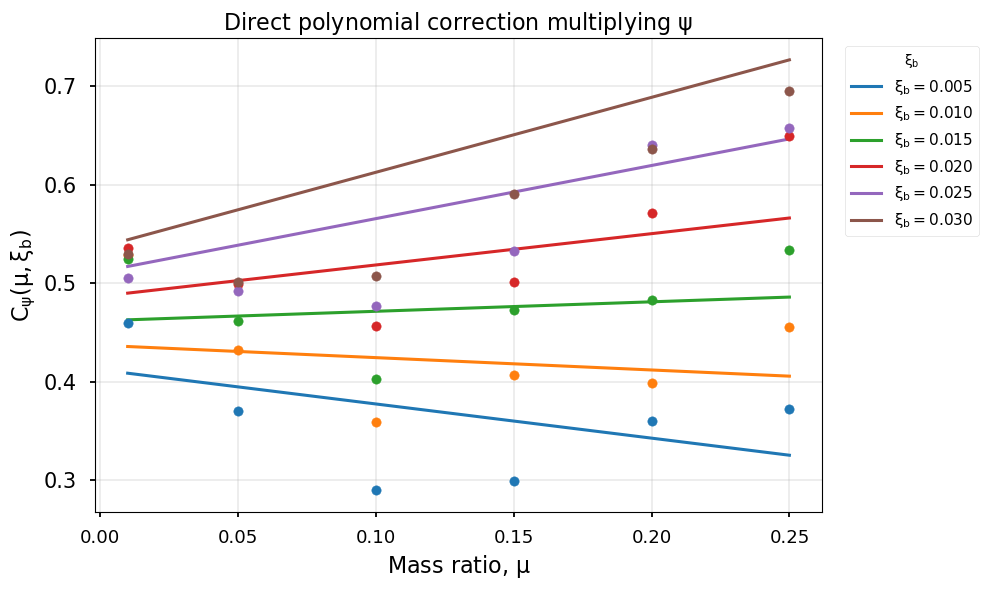

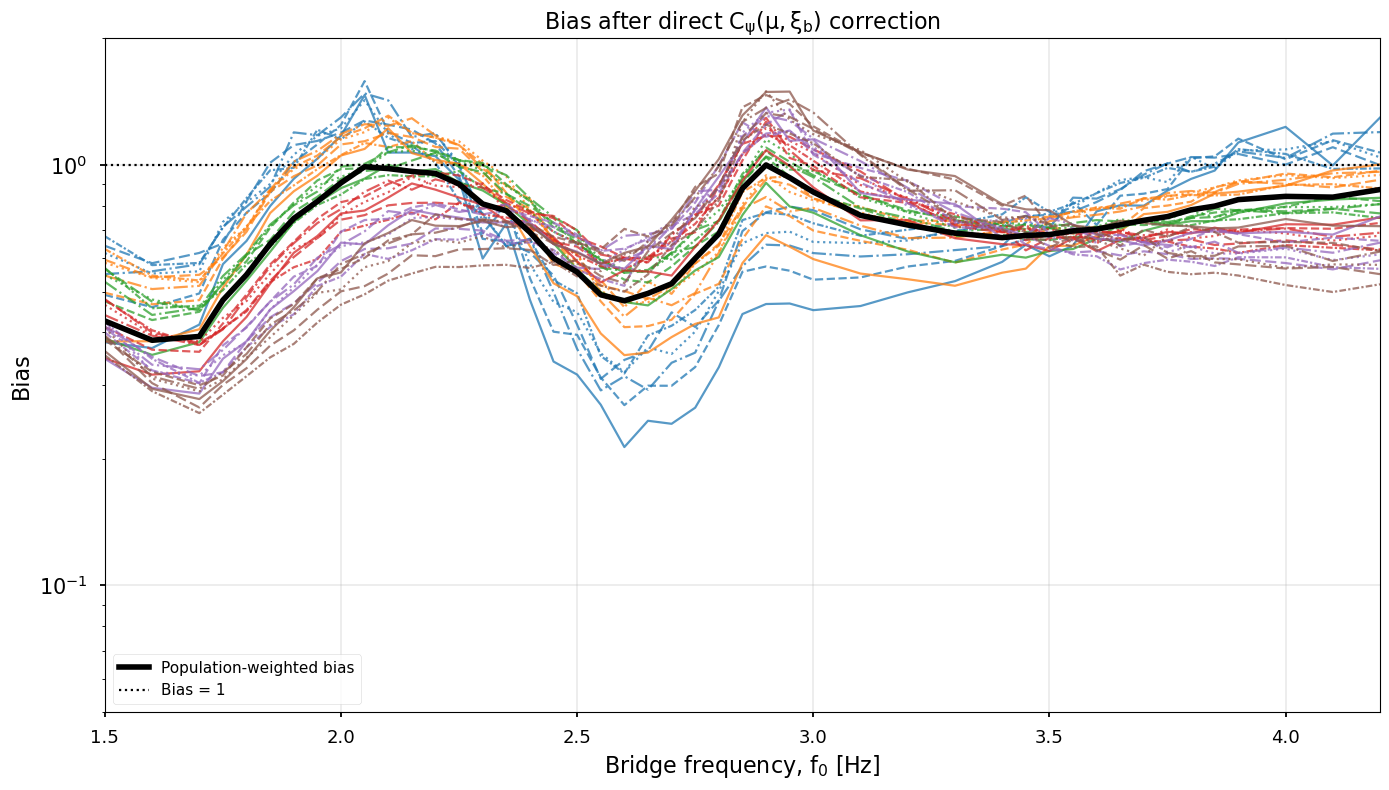


FINAL ASSERTION

max population-weighted bias = 1.000000000000
PASS: final weighted bias maximum = 1.


In [65]:
# ============================================================
# DIRECT POPULATION-CALIBRATED POLYNOMIAL MULTIPLIER FOR psi
#
# RUN THIS AFTER THE FIRST 3 CELLS ONLY
#
# INPUTS ALREADY AVAILABLE:
#
#   plot_all_df
#       bridge_frequency
#       mass_ratio
#       target_beamdamp
#       measure
#       psi_env
#       newpsi_bias_mean
#
#   weights_df
#       mu
#       xi_b
#       weight
#
#
# FINAL MODEL:
#
#   psi_final(f,mu,xi)
#   =
#   psi_env(f) * C_psi(mu,xi)
#
# where
#
#   C_psi(mu,xi)
#   =
#   a + b*mu + c*xi + d*mu*xi
#
#
# Therefore:
#
#   B_final
#   =
#   B_psi / C_psi
#
#
# CALIBRATION:
#
# 1. Rough correction point for each line:
#
#       C_raw,i = max_f B_psi,i(f)
#
# 2. Population-weighted linear-interaction fit:
#
#       C0(mu,xi)
#       =
#       a0 + b0*mu + c0*xi + d0*mu*xi
#
# 3. Uniformly scale the fitted surface so that:
#
#       max_f sum_i[
#           w_i B_psi,i(f) / C_psi(mu_i,xi_i)
#       ] = 1
#
# ============================================================


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


# ============================================================
# 0. SETTINGS
# ============================================================

MEASURE = "Peak absolute acceleration"
BIAS_COLUMN = "newpsi_bias_mean"

CAL_FMIN = 1.50
CAL_FMAX = 4.20

MU_ROUND = 4
XI_ROUND = 4
FREQ_ROUND = 6

EPS = 1e-12


# ============================================================
# 1. CHECK INPUTS
# ============================================================

if "plot_all_df" not in globals():
    raise RuntimeError(
        "plot_all_df does not exist. "
        "Run the first 3 cells first."
    )

if "weights_df" not in globals():
    raise RuntimeError(
        "weights_df does not exist. "
        "Run the first 3 cells first."
    )


required_bias_cols = [
    "bridge_frequency",
    "mass_ratio",
    "target_beamdamp",
    "measure",
    "psi_env",
    BIAS_COLUMN,
]

missing = [
    c for c in required_bias_cols
    if c not in plot_all_df.columns
]

if missing:
    raise RuntimeError(
        f"plot_all_df is missing: {missing}"
    )


required_weight_cols = [
    "mu",
    "xi_b",
    "weight",
]

missing = [
    c for c in required_weight_cols
    if c not in weights_df.columns
]

if missing:
    raise RuntimeError(
        f"weights_df is missing: {missing}"
    )


print("\n============================================================")
print("INPUT CHECK PASSED")
print("============================================================")


# ============================================================
# 2. PREPARE NEW-psi BIAS DATA
# ============================================================

bias_df = plot_all_df[
    plot_all_df["measure"]
    .astype(str)
    .str.strip()
    .eq(MEASURE)
].copy()


for col in [
    "bridge_frequency",
    "mass_ratio",
    "target_beamdamp",
    "psi_env",
    BIAS_COLUMN,
]:
    bias_df[col] = pd.to_numeric(
        bias_df[col],
        errors="coerce"
    )


bias_df = bias_df.dropna(
    subset=[
        "bridge_frequency",
        "mass_ratio",
        "target_beamdamp",
        BIAS_COLUMN,
    ]
).copy()


# ============================================================
# 3. CALIBRATION FREQUENCY RANGE
# ============================================================

cal_df = bias_df[
    (bias_df["bridge_frequency"] >= CAL_FMIN)
    &
    (bias_df["bridge_frequency"] <= CAL_FMAX)
].copy()


if cal_df.empty:
    raise ValueError(
        "No data between 1.5 and 4.2 Hz."
    )


# ============================================================
# 4. MERGE KEYS
# ============================================================

cal_df["mu_key"] = (
    cal_df["mass_ratio"]
    .round(MU_ROUND)
)

cal_df["xi_key"] = (
    cal_df["target_beamdamp"]
    .round(XI_ROUND)
)

cal_df["f_key"] = (
    cal_df["bridge_frequency"]
    .round(FREQ_ROUND)
)


wdf = weights_df[
    [
        "mu",
        "xi_b",
        "weight",
    ]
].copy()


for col in [
    "mu",
    "xi_b",
    "weight",
]:
    wdf[col] = pd.to_numeric(
        wdf[col],
        errors="coerce"
    )


wdf = wdf.dropna().copy()


wdf["mu_key"] = (
    wdf["mu"]
    .round(MU_ROUND)
)

wdf["xi_key"] = (
    wdf["xi_b"]
    .round(XI_ROUND)
)


# ============================================================
# 5. KEEP COMMON (mu,xi) COMBINATIONS
# ============================================================

available_combos = (
    cal_df[
        [
            "mu_key",
            "xi_key",
        ]
    ]
    .drop_duplicates()
)


wdf = wdf.merge(
    available_combos,
    on=[
        "mu_key",
        "xi_key",
    ],
    how="inner"
)


if wdf.empty:
    raise ValueError(
        "No common (mu,xi) combinations."
    )


# Renormalise retained weights
wdf["w"] = (
    wdf["weight"]
    /
    wdf["weight"].sum()
)


cal_df = cal_df.merge(
    wdf[
        [
            "mu_key",
            "xi_key",
            "w",
        ]
    ],
    on=[
        "mu_key",
        "xi_key",
    ],
    how="inner"
)


print(
    f"\nNumber of retained combinations = "
    f"{len(wdf)}"
)

print(
    f"Sum of population weights = "
    f"{wdf['w'].sum():.12f}"
)


# ============================================================
# 6. ROUGH DIRECT psi-CORRECTION POINTS
#
# Since:
#
#       B_final = B_psi / C
#
# the individual correction that would make
# each individual line peak exactly at 1 is:
#
#       C_raw = max(B_psi)
#
# NO RECIPROCAL.
# NO OLD K POLYNOMIAL.
# ============================================================

surface_df = (
    cal_df
    .groupby(
        [
            "mu_key",
            "xi_key",
        ],
        as_index=False
    )
    .agg(
        mu=("mass_ratio", "first"),
        xi_b=("target_beamdamp", "first"),
        w=("w", "first"),
        C_raw=(BIAS_COLUMN, "max"),
    )
    .sort_values(
        [
            "mu_key",
            "xi_key",
        ]
    )
    .reset_index(drop=True)
)


surface_df["w"] = (
    surface_df["w"]
    /
    surface_df["w"].sum()
)


print("\n============================================================")
print("ROUGH DIRECT psi-CORRECTION POINTS")
print("C_raw = max new-psi bias")
print("============================================================")

print(
    surface_df[
        [
            "mu",
            "xi_b",
            "w",
            "C_raw",
        ]
    ].to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# ============================================================
# 7. POPULATION-WEIGHTED LINEAR-INTERACTION FIT
#
# C0(mu,xi)
#
# =
#
# a0 + b0*mu + c0*xi + d0*mu*xi
#
# Fit the DIRECT psi correction values.
# ============================================================

mu = surface_df["mu"].to_numpy(dtype=float)
xi = surface_df["xi_b"].to_numpy(dtype=float)
w = surface_df["w"].to_numpy(dtype=float)

C_raw = surface_df["C_raw"].to_numpy(dtype=float)


X = np.column_stack(
    [
        np.ones_like(mu),
        mu,
        xi,
        mu * xi,
    ]
)


sqrt_w = np.sqrt(w)

Xw = X * sqrt_w[:, None]
yw = C_raw * sqrt_w


beta0, _, _, _ = np.linalg.lstsq(
    Xw,
    yw,
    rcond=None
)


a0, b0, c0, d0 = beta0


surface_df["C_fit_initial"] = (
    X @ beta0
)


if np.any(
    surface_df["C_fit_initial"] <= 0
):
    raise ValueError(
        "Initial fitted psi correction becomes <= 0."
    )


print("\n============================================================")
print("INITIAL DIRECT psi POLYNOMIAL")
print("============================================================")

print(
    "\nC0(mu,xi_b) = "
    f"{a0:.8f} "
    f"{b0:+.8f}*mu "
    f"{c0:+.8f}*xi_b "
    f"{d0:+.8f}*mu*xi_b"
)


# ============================================================
# 8. BUILD COMMON BIAS MATRIX
#
# rows    = frequency
# columns = (mu,xi) combinations
# ============================================================

pivot = (
    cal_df
    .pivot_table(
        index="f_key",
        columns=[
            "mu_key",
            "xi_key",
        ],
        values=BIAS_COLUMN,
        aggfunc="mean"
    )
    .sort_index()
)


combo_order = [
    (
        row.mu_key,
        row.xi_key
    )
    for row
    in surface_df.itertuples()
]


missing_combos = [
    combo
    for combo in combo_order
    if combo not in pivot.columns
]


if missing_combos:
    raise ValueError(
        "Missing combinations in bias matrix:\n"
        f"{missing_combos}"
    )


pivot = pivot[
    combo_order
].copy()


# Keep only frequencies available for every line
n_before = len(pivot)

pivot = pivot.dropna(axis=0, how="any")

n_after = len(pivot)


print(
    f"\nCommon frequency points used: "
    f"{n_after} / {n_before}"
)


if pivot.empty:
    raise ValueError(
        "No common frequency points across all bias lines."
    )


frequencies = (
    pivot.index
    .to_numpy(dtype=float)
)


B = (
    pivot
    .to_numpy(dtype=float)
)


# ============================================================
# 9. WEIGHT VECTOR IN EXACT SAME ORDER
# ============================================================

w_vector = (
    surface_df["w"]
    .to_numpy(dtype=float)
)


# ============================================================
# 10. WEIGHTED BIAS BEFORE THIS SECOND psi CORRECTION
# ============================================================

B_weighted_before = (
    B @ w_vector
)


peak_before_index = int(
    np.argmax(B_weighted_before)
)


peak_before = float(
    B_weighted_before[
        peak_before_index
    ]
)


f_peak_before = float(
    frequencies[
        peak_before_index
    ]
)


print("\n============================================================")
print("BEFORE mu-xi psi CORRECTION")
print("============================================================")

print(
    f"\nMaximum weighted new-psi bias = "
    f"{peak_before:.10f}"
)

print(
    f"Governing frequency = "
    f"{f_peak_before:.4f} Hz"
)


# ============================================================
# 11. APPLY INITIAL FIT TO psi
#
# C0_i = fitted psi multiplier
#
# Then:
#
# B0_weighted(f)
#
# =
#
# sum_i w_i B_i(f) / C0_i
# ============================================================

C0 = (
    surface_df["C_fit_initial"]
    .to_numpy(dtype=float)
)


B_weighted_initial_fit = (
    B @ (
        w_vector
        /
        C0
    )
)


peak_initial_fit = float(
    np.max(
        B_weighted_initial_fit
    )
)


print("\n============================================================")
print("AFTER INITIAL SURFACE FIT")
print("============================================================")

print(
    f"\nMaximum weighted bias = "
    f"{peak_initial_fit:.10f}"
)


# ============================================================
# 12. POPULATION CALIBRATION OF THE WHOLE SURFACE
#
# We need:
#
# max_f sum_i [
#
#     w_i B_i(f) / C_final_i
#
# ] = 1
#
#
# Let:
#
# C_final = S * C0
#
# Then:
#
# B_final_weighted
#
# =
#
# B_initial_weighted / S
#
#
# Therefore choose:
#
#       S = max(B_initial_weighted)
#
# ============================================================

POPULATION_SCALE = (
    peak_initial_fit
)


beta_final = (
    POPULATION_SCALE
    *
    beta0
)


a, b, c, d = beta_final


surface_df["C_psi"] = (
    X @ beta_final
)


# Scale the rough points too so the plot compares
# final rough targets with final fitted surface.

surface_df["C_target_population"] = (
    POPULATION_SCALE
    *
    surface_df["C_raw"]
)


if np.any(
    surface_df["C_psi"] <= 0
):
    raise ValueError(
        "Final psi correction becomes <= 0."
    )


# ============================================================
# 13. FINAL WEIGHTED BIAS
# ============================================================

C_final = (
    surface_df["C_psi"]
    .to_numpy(dtype=float)
)


B_weighted_final = (
    B @ (
        w_vector
        /
        C_final
    )
)


peak_final_index = int(
    np.argmax(
        B_weighted_final
    )
)


peak_final = float(
    B_weighted_final[
        peak_final_index
    ]
)


f_peak_final = float(
    frequencies[
        peak_final_index
    ]
)


# ============================================================
# 14. FIT STATISTICS
#
# Compare final fitted surface with final scaled rough points.
# ============================================================

C_target = (
    surface_df[
        "C_target_population"
    ]
    .to_numpy(dtype=float)
)


C_prediction = (
    surface_df[
        "C_psi"
    ]
    .to_numpy(dtype=float)
)


weighted_rmse = np.sqrt(
    np.sum(
        w_vector
        *
        (
            C_target
            -
            C_prediction
        )**2
    )
)


target_mean = np.sum(
    w_vector
    *
    C_target
)


ss_res = np.sum(
    w_vector
    *
    (
        C_target
        -
        C_prediction
    )**2
)


ss_tot = np.sum(
    w_vector
    *
    (
        C_target
        -
        target_mean
    )**2
)


weighted_r2 = (
    1.0
    -
    ss_res / ss_tot
    if ss_tot > EPS
    else np.nan
)


# ============================================================
# 15. FINAL RESULT
# ============================================================

print("\n")
print("=" * 72)
print("FINAL POLYNOMIAL THAT MULTIPLIES psi")
print("=" * 72)


print(
    "\nC_psi(mu,xi_b) = "
    f"{a:.8f} "
    f"{b:+.8f}*mu "
    f"{c:+.8f}*xi_b "
    f"{d:+.8f}*mu*xi_b"
)


print(
    "\nFINAL psi EQUATION:"
)

print(
    "psi_final(f,mu,xi_b)"
    " = psi_env(f) * C_psi(mu,xi_b)"
)


print("\nPopulation calibration scale:")
print(
    f"S = {POPULATION_SCALE:.10f}"
)


print("\nFit quality:")
print(
    f"Weighted RMSE = {weighted_rmse:.8f}"
)

print(
    f"Weighted R²   = {weighted_r2:.6f}"
)


print("\nFINAL CHECK:")
print(
    f"Maximum population-weighted bias = "
    f"{peak_final:.12f}"
)

print(
    f"Governing frequency = "
    f"{f_peak_final:.4f} Hz"
)


print(
    "\nMinimum C_psi = "
    f"{C_final.min():.8f}"
)

print(
    "Maximum C_psi = "
    f"{C_final.max():.8f}"
)


# ============================================================
# 16. TABLE
# ============================================================

print("\n")
print("=" * 72)
print("ROUGH POINTS AND FINAL POLYNOMIAL")
print("=" * 72)


print(
    surface_df[
        [
            "mu",
            "xi_b",
            "w",
            "C_raw",
            "C_target_population",
            "C_psi",
        ]
    ]
    .to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# ============================================================
# 17. 3D SURFACE PLOT
#
# DOTS:
# population-calibrated rough data points
#
# SURFACE:
# final direct polynomial multiplying psi
# ============================================================

mu_grid = np.linspace(
    surface_df["mu"].min(),
    surface_df["mu"].max(),
    120
)


xi_grid = np.linspace(
    surface_df["xi_b"].min(),
    surface_df["xi_b"].max(),
    120
)


MU, XI = np.meshgrid(
    mu_grid,
    xi_grid
)


C_SURFACE = (
    a
    +
    b * MU
    +
    c * XI
    +
    d * MU * XI
)


if np.any(
    C_SURFACE <= 0
):
    print(
        "\nWARNING: fitted surface becomes <= 0 "
        "somewhere inside the plotted domain."
    )


fig = plt.figure(
    figsize=(11, 8)
)


ax = fig.add_subplot(
    111,
    projection="3d"
)


# Final fitted surface
ax.plot_surface(
    MU,
    XI,
    C_SURFACE,
    alpha=0.55,
    linewidth=0
)


# Rough calibration points
ax.scatter(
    surface_df["mu"],
    surface_df["xi_b"],
    surface_df["C_target_population"],
    s=50,
    depthshade=False
)


ax.set_xlabel(
    r"Mass ratio, $\mu$"
)

ax.set_ylabel(
    r"Bridge damping ratio, $\xi_b$"
)

ax.set_zlabel(
    r"$C_\psi(\mu,\xi_b)$"
)


ax.set_title(
    r"Population-calibrated polynomial multiplying $\psi$"
)


plt.tight_layout()
plt.show()


# ============================================================
# 18. 2D SLICES
#
# DOTS  = rough data
# LINES = final fitted polynomial
#
# NO RECIPROCAL CURVES.
# NO SECOND REPRESENTATION.
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 6)
)


xi_levels = np.sort(
    surface_df[
        "xi_b"
    ].unique()
)


mu_fine = np.linspace(
    surface_df["mu"].min(),
    surface_df["mu"].max(),
    300
)


for xi_value in xi_levels:

    C_line = (
        a
        +
        b * mu_fine
        +
        c * xi_value
        +
        d * mu_fine * xi_value
    )


    line = ax.plot(
        mu_fine,
        C_line,
        linewidth=2.2,
        label=rf"$\xi_b={xi_value:.3f}$"
    )[0]


    sub = surface_df[
        np.isclose(
            surface_df["xi_b"],
            xi_value
        )
    ].copy()


    ax.scatter(
        sub["mu"],
        sub["C_target_population"],
        color=line.get_color(),
        s=45,
        zorder=3
    )


ax.set_xlabel(
    r"Mass ratio, $\mu$"
)

ax.set_ylabel(
    r"$C_\psi(\mu,\xi_b)$"
)


ax.set_title(
    r"Direct polynomial correction multiplying $\psi$"
)


ax.grid(
    True,
    alpha=0.25
)


ax.legend(
    title=r"$\xi_b$",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)


plt.tight_layout()
plt.show()


# ============================================================
# 19. APPLY THE FINAL POLYNOMIAL DIRECTLY TO EVERY DATA ROW
#
# This creates:
#
#   psi_final
#   bias_final
#
# for later use.
# ============================================================

final_df = cal_df.copy()


mu_all = (
    final_df[
        "mass_ratio"
    ].to_numpy(dtype=float)
)


xi_all = (
    final_df[
        "target_beamdamp"
    ].to_numpy(dtype=float)
)


final_df["C_psi"] = (
    a
    +
    b * mu_all
    +
    c * xi_all
    +
    d * mu_all * xi_all
)


final_df["psi_final"] = (
    final_df["psi_env"]
    *
    final_df["C_psi"]
)


final_df["bias_final"] = (
    final_df[BIAS_COLUMN]
    /
    final_df["C_psi"]
)


final_df["weighted_bias_term"] = (
    final_df["w"]
    *
    final_df["bias_final"]
)


# ============================================================
# 20. POPULATION-WEIGHTED FINAL BIAS
# ============================================================

weighted_bias_df = (
    final_df
    .groupby(
        "f_key",
        as_index=False
    )
    .agg(
        bridge_frequency=(
            "bridge_frequency",
            "mean"
        ),

        weighted_sum=(
            "weighted_bias_term",
            "sum"
        ),

        weight_sum=(
            "w",
            "sum"
        ),
    )
    .sort_values(
        "bridge_frequency"
    )
)


weighted_bias_df["weighted_bias"] = (
    weighted_bias_df["weighted_sum"]
    /
    weighted_bias_df["weight_sum"]
)


# ============================================================
# 21. VERIFY WITH THE SAME TYPE OF BIAS FIGURE
# ============================================================

mu_levels = np.sort(
    final_df[
        "mass_ratio"
    ].unique()
)


xi_levels = np.sort(
    final_df[
        "target_beamdamp"
    ].unique()
)


base_colors = (
    plt.rcParams[
        "axes.prop_cycle"
    ]
    .by_key()["color"]
)


mu_colors = {
    mu_value:
    base_colors[
        i % len(base_colors)
    ]
    for i, mu_value
    in enumerate(mu_levels)
}


line_styles = [
    "-",
    "--",
    "-.",
    ":",
    (0, (5, 2)),
    (0, (3, 1, 1, 1)),
]


xi_styles = {
    xi_value:
    line_styles[
        i % len(line_styles)
    ]
    for i, xi_value
    in enumerate(xi_levels)
}


fig, ax = plt.subplots(
    figsize=(14, 8)
)


# Individual bias lines
for mu_value in mu_levels:

    for xi_value in xi_levels:

        sub = final_df[
            np.isclose(
                final_df["mass_ratio"],
                mu_value
            )
            &
            np.isclose(
                final_df["target_beamdamp"],
                xi_value
            )
        ].copy()


        if sub.empty:
            continue


        sub = sub.sort_values(
            "bridge_frequency"
        )


        ax.plot(
            sub["bridge_frequency"],
            sub["bias_final"],
            color=mu_colors[
                mu_value
            ],
            linestyle=xi_styles[
                xi_value
            ],
            linewidth=1.6,
            alpha=0.75
        )


# Population-weighted line
ax.plot(
    weighted_bias_df[
        "bridge_frequency"
    ],
    weighted_bias_df[
        "weighted_bias"
    ],
    color="black",
    linewidth=4,
    label="Population-weighted bias"
)


ax.axhline(
    1.0,
    color="black",
    linestyle=":",
    linewidth=1.6,
    label="Bias = 1"
)


ax.set_xlim(
    CAL_FMIN,
    CAL_FMAX
)


ax.set_yscale(
    "log"
)

ax.set_ylim(
    0.05,
    2.0
)


ax.set_xlabel(
    r"Bridge frequency, $f_0$ [Hz]"
)

ax.set_ylabel(
    "Bias"
)


ax.set_title(
    r"Bias after direct $C_\psi(\mu,\xi_b)$ correction"
)


ax.grid(
    True,
    alpha=0.25
)


ax.legend(
    loc="lower left"
)


plt.tight_layout()
plt.show()


# ============================================================
# 22. FINAL NUMERICAL ASSERTION
# ============================================================

final_check = (
    weighted_bias_df[
        "weighted_bias"
    ].max()
)


print("\n============================================================")
print("FINAL ASSERTION")
print("============================================================")

print(
    f"\nmax population-weighted bias = "
    f"{final_check:.12f}"
)


if not np.isclose(
    final_check,
    1.0,
    atol=1e-8
):

    print(
        "WARNING: final weighted bias is not exactly 1."
    )

else:

    print(
        "PASS: final weighted bias maximum = 1."
    )

In [60]:
# Save rho < 1 result
a_low, b_low, c_low, d_low = a, b, c, d
surface_low = surface_df.copy()

# Save rho < 1 final bias results
final_df_low = final_df.copy()
weighted_bias_low = weighted_bias_df.copy()


POPULATION-WEIGHTED BIAS COMPARISON

Original code:
  max bias = 1.51363969
  f = 2.2500 Hz

After frequency correction psi_env:
  max bias = 0.41847483
  f = 2.0500 Hz

After final C_psi correction:
  max bias = 1.000000000000
  f = 2.9000 Hz

Final objective [max(B_W)-1]^2 = 4.930380657631e-32


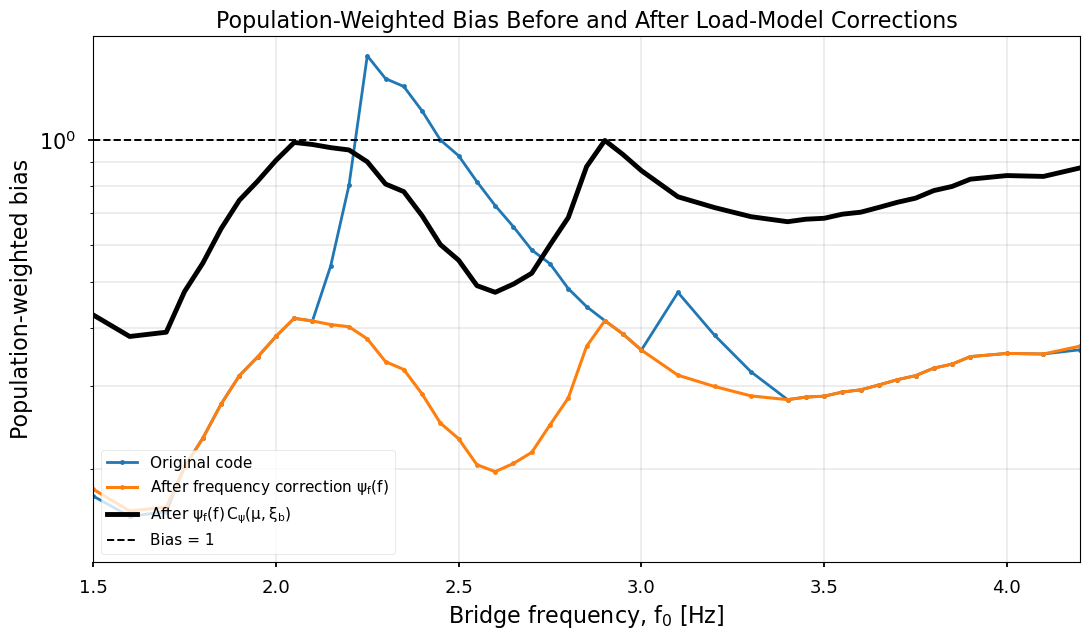


FINAL CHECK

Maximum final population-weighted bias = 1.000000000000
PASS: final population-weighted bias peaks at 1.


In [66]:
# ============================================================
# POPULATION-WEIGHTED BIAS COMPARISON
#
# RUN DIRECTLY AFTER THE POLYNOMIAL CALIBRATION CELL
#
# Shows:
#
# 1. Original code bias
# 2. Bias after frequency correction psi_env
# 3. Bias after final psi_env * C_psi(mu,xi_b)
#
# REQUIRED FROM PREVIOUS CELL:
#
#   final_df
#
# containing:
#   bridge_frequency
#   f_key
#   w
#   code_bias_mean
#   newpsi_bias_mean
#   C_psi
#   bias_final
#
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 0. SETTINGS
# ============================================================

FMIN = 1.50
FMAX = 4.20

ORIGINAL_BIAS_COLUMN = "code_bias_mean"
PSI_BIAS_COLUMN = "newpsi_bias_mean"
FINAL_BIAS_COLUMN = "bias_final"


# ============================================================
# 1. CHECK INPUT
# ============================================================

if "final_df" not in globals():

    raise RuntimeError(
        "final_df does not exist.\n"
        "Run the direct psi-polynomial calibration cell first."
    )


required_columns = [
    "bridge_frequency",
    "f_key",
    "w",
    ORIGINAL_BIAS_COLUMN,
    PSI_BIAS_COLUMN,
    FINAL_BIAS_COLUMN,
]


missing = [
    col
    for col in required_columns
    if col not in final_df.columns
]


if missing:

    print("\nAvailable final_df columns:")
    print(final_df.columns.tolist())

    raise RuntimeError(
        f"\nfinal_df is missing columns: {missing}"
    )


# ============================================================
# 2. COPY FINAL DATA
# ============================================================

df = final_df.copy()


for col in [
    "bridge_frequency",
    "w",
    ORIGINAL_BIAS_COLUMN,
    PSI_BIAS_COLUMN,
    FINAL_BIAS_COLUMN,
]:

    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )


df = df.dropna(
    subset=[
        "bridge_frequency",
        "w",
        ORIGINAL_BIAS_COLUMN,
        PSI_BIAS_COLUMN,
        FINAL_BIAS_COLUMN,
    ]
).copy()


df = df[
    (df["bridge_frequency"] >= FMIN)
    &
    (df["bridge_frequency"] <= FMAX)
].copy()


if df.empty:

    raise ValueError(
        "No data remain within the selected frequency range."
    )


# ============================================================
# 3. CREATE WEIGHTED TERMS
# ============================================================

df["weighted_original"] = (
    df["w"]
    *
    df[ORIGINAL_BIAS_COLUMN]
)


df["weighted_psi"] = (
    df["w"]
    *
    df[PSI_BIAS_COLUMN]
)


df["weighted_final"] = (
    df["w"]
    *
    df[FINAL_BIAS_COLUMN]
)


# ============================================================
# 4. POPULATION-WEIGHTED BIAS CURVES
#
# Divide by weight_sum defensively in case some frequency
# points contain fewer available combinations.
# ============================================================

weighted_comparison_df = (

    df

    .groupby(
        "f_key",
        as_index=False
    )

    .agg(

        bridge_frequency=(
            "bridge_frequency",
            "mean"
        ),

        original_sum=(
            "weighted_original",
            "sum"
        ),

        psi_sum=(
            "weighted_psi",
            "sum"
        ),

        final_sum=(
            "weighted_final",
            "sum"
        ),

        weight_sum=(
            "w",
            "sum"
        )

    )

    .sort_values(
        "bridge_frequency"
    )

)


weighted_comparison_df["bias_original"] = (
    weighted_comparison_df["original_sum"]
    /
    weighted_comparison_df["weight_sum"]
)


weighted_comparison_df["bias_psi"] = (
    weighted_comparison_df["psi_sum"]
    /
    weighted_comparison_df["weight_sum"]
)


weighted_comparison_df["bias_final"] = (
    weighted_comparison_df["final_sum"]
    /
    weighted_comparison_df["weight_sum"]
)


# ============================================================
# 5. PEAK INFORMATION
# ============================================================

def peak_info(column):

    idx = (
        weighted_comparison_df[column]
        .idxmax()
    )

    peak_bias = float(
        weighted_comparison_df.loc[
            idx,
            column
        ]
    )

    peak_frequency = float(
        weighted_comparison_df.loc[
            idx,
            "bridge_frequency"
        ]
    )

    return peak_bias, peak_frequency


Bmax_original, fmax_original = peak_info(
    "bias_original"
)

Bmax_psi, fmax_psi = peak_info(
    "bias_psi"
)

Bmax_final, fmax_final = peak_info(
    "bias_final"
)


print("\n============================================================")
print("POPULATION-WEIGHTED BIAS COMPARISON")
print("============================================================")


print(
    f"\nOriginal code:"
    f"\n  max bias = {Bmax_original:.8f}"
    f"\n  f = {fmax_original:.4f} Hz"
)


print(
    f"\nAfter frequency correction psi_env:"
    f"\n  max bias = {Bmax_psi:.8f}"
    f"\n  f = {fmax_psi:.4f} Hz"
)


print(
    f"\nAfter final C_psi correction:"
    f"\n  max bias = {Bmax_final:.12f}"
    f"\n  f = {fmax_final:.4f} Hz"
)


print(
    f"\nFinal objective [max(B_W)-1]^2 = "
    f"{(Bmax_final - 1.0)**2:.12e}"
)


# ============================================================
# 6. PLOT
# ============================================================

fig, ax = plt.subplots(
    figsize=(11, 6.5)
)


# ------------------------------------------------------------
# Original code
# ------------------------------------------------------------

ax.plot(

    weighted_comparison_df[
        "bridge_frequency"
    ],

    weighted_comparison_df[
        "bias_original"
    ],

    marker="o",
    markersize=3.5,
    linewidth=2.0,

    label="Original code"

)


# ------------------------------------------------------------
# After frequency correction only
# ------------------------------------------------------------

ax.plot(

    weighted_comparison_df[
        "bridge_frequency"
    ],

    weighted_comparison_df[
        "bias_psi"
    ],

    marker="o",
    markersize=3.5,
    linewidth=2.2,

    label=(
        r"After frequency correction "
        r"$\psi_f(f)$"
    )

)


# ------------------------------------------------------------
# After complete correction
#
# psi_final = psi_f * C_psi(mu,xi_b)
# ------------------------------------------------------------

ax.plot(

    weighted_comparison_df[
        "bridge_frequency"
    ],

    weighted_comparison_df[
        "bias_final"
    ],

    color="black",
    linewidth=3.5,

    label=(
        r"After $\psi_f(f)\,C_\psi(\mu,\xi_b)$"
    )

)


# ------------------------------------------------------------
# Bias = 1
# ------------------------------------------------------------

ax.axhline(

    1.0,

    color="black",
    linestyle="--",
    linewidth=1.4,

    label="Bias = 1"

)


# ============================================================
# 7. FORMAT
# ============================================================

ax.set_xlim(
    FMIN,
    FMAX
)


ax.set_yscale(
    "log"
)


all_biases = np.concatenate(
    [
        weighted_comparison_df[
            "bias_original"
        ].to_numpy(),

        weighted_comparison_df[
            "bias_psi"
        ].to_numpy(),

        weighted_comparison_df[
            "bias_final"
        ].to_numpy(),
    ]
)


positive_biases = all_biases[
    np.isfinite(all_biases)
    &
    (all_biases > 0)
]


if len(positive_biases) > 0:

    ymin = max(
        0.05,
        0.80 * positive_biases.min()
    )

    ymax = max(
        1.25,
        1.10 * positive_biases.max()
    )

    ax.set_ylim(
        ymin,
        ymax
    )


ax.set_xlabel(
    r"Bridge frequency, $f_0$ [Hz]"
)


ax.set_ylabel(
    "Population-weighted bias"
)


ax.set_title(
    "Population-Weighted Bias Before and After "
    "Load-Model Corrections"
)


ax.grid(
    True,
    which="both",
    alpha=0.25
)


ax.legend(
    loc="lower left"
)


plt.tight_layout()
plt.show()


# ============================================================
# 8. FINAL CHECK
# ============================================================

print("\n============================================================")
print("FINAL CHECK")
print("============================================================")


print(
    f"\nMaximum final population-weighted bias = "
    f"{Bmax_final:.12f}"
)


if np.isclose(
    Bmax_final,
    1.0,
    atol=1e-8
):

    print(
        "PASS: final population-weighted bias peaks at 1."
    )

else:

    print(
        "WARNING: final population-weighted bias "
        "does not peak exactly at 1."
    )


FINAL DIRECT psi MODEL

C_psi(mu,xi_b) = 0.38712409 -0.56850584*mu +4.97392010*xi_b +44.31470681*mu*xi_b

Population-weighted correction:
C_population = sum(w_i C_i) = 0.41742917

Population-weighted psi:
psi_population(f) = 0.41742917 * psi_env(f)


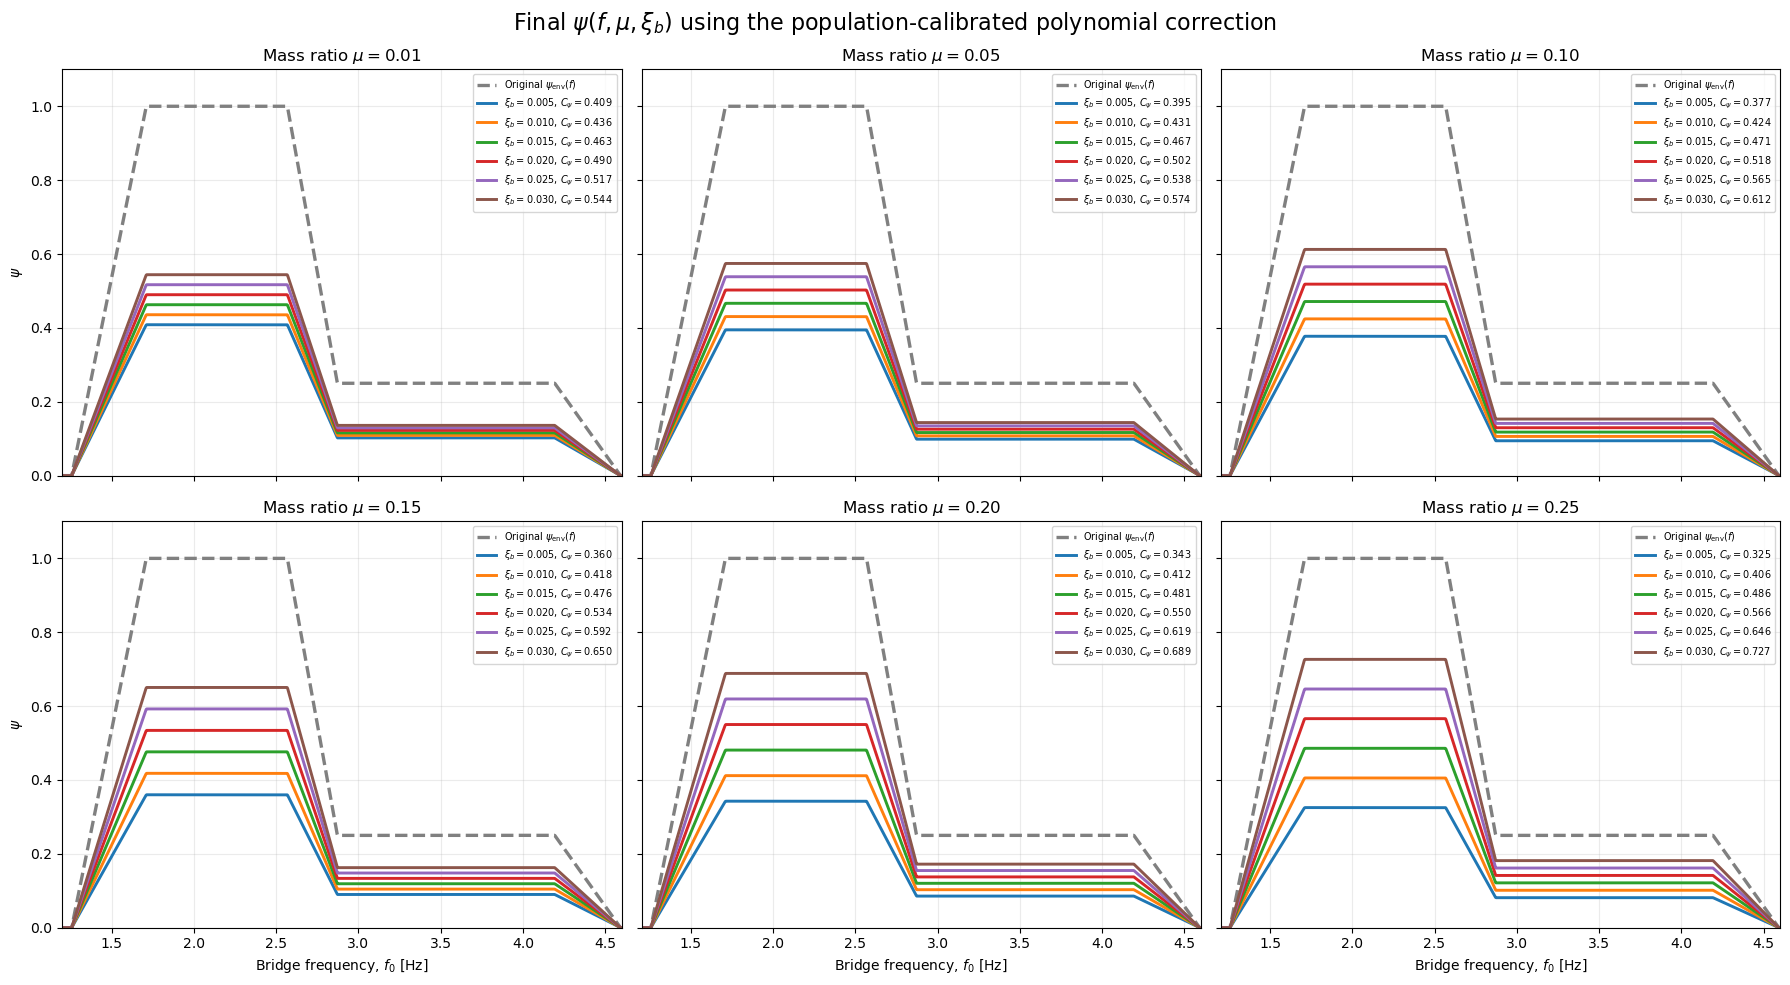

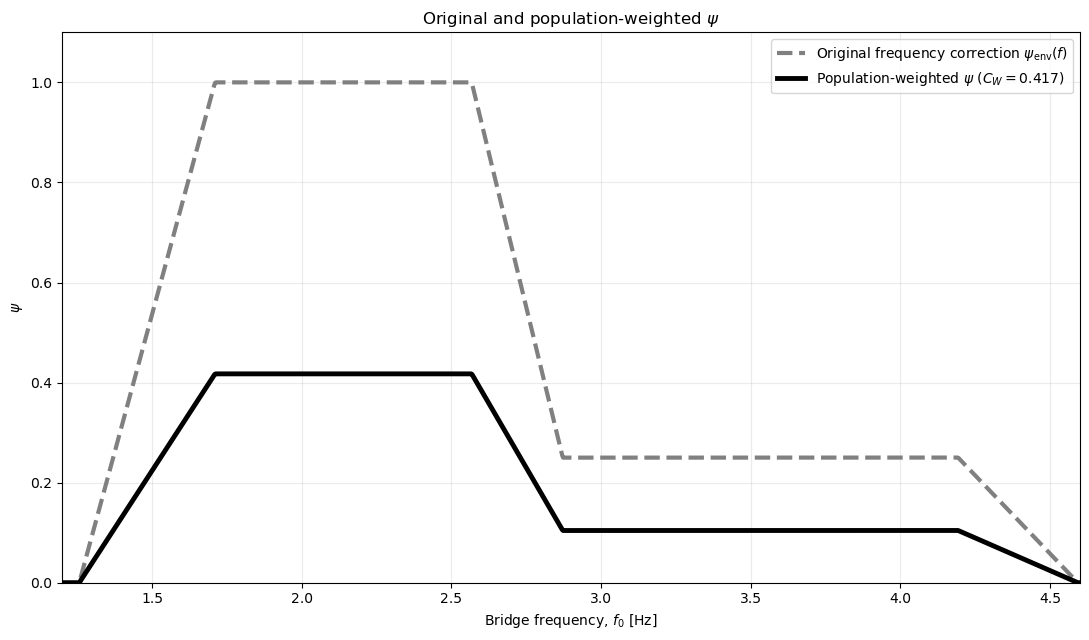


INDIVIDUAL psi CORRECTIONS
      mu     xi_b        w    C_psi
0.010000 0.005000 0.089189 0.408524
0.010000 0.010000 0.055889 0.435610
0.010000 0.015000 0.024922 0.462695
0.010000 0.020000 0.019567 0.489780
0.010000 0.025000 0.012960 0.516866
0.010000 0.030000 0.002657 0.543951
0.050000 0.005000 0.087295 0.394647
0.050000 0.010000 0.059508 0.430595
0.050000 0.015000 0.025780 0.466544
0.050000 0.020000 0.018153 0.502492
0.050000 0.025000 0.007550 0.538440
0.050000 0.030000 0.003005 0.574388
0.100000 0.005000 0.083833 0.377300
0.100000 0.010000 0.042961 0.424327
0.100000 0.015000 0.018284 0.471354
0.100000 0.020000 0.016685 0.518381
0.100000 0.025000 0.004755 0.565408
0.100000 0.030000 0.002020 0.612435
0.150000 0.005000 0.058051 0.359954
0.150000 0.010000 0.020782 0.418059
0.150000 0.015000 0.007420 0.476165
0.150000 0.020000 0.007573 0.534271
0.150000 0.025000 0.002526 0.592376
0.150000 0.030000 0.001254 0.650482
0.200000 0.005000 0.116102 0.342607
0.200000 0.010000 0.041563 0.411792


In [ ]:
# ============================================================
# PLOT FINAL psi CURVES USING THE DIRECT POLYNOMIAL
# FROM THE PREVIOUS CALIBRATION CELL
#
# REQUIRED FROM PREVIOUS CELL:
#
#   a, b, c, d
#   surface_df
#   psi_env_new()
#
#
# FINAL MODEL:
#
#   C_psi(mu,xi)
#   =
#   a + b*mu + c*xi + d*mu*xi
#
#   psi_final(f,mu,xi)
#   =
#   psi_env(f) * C_psi(mu,xi)
#
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


# ============================================================
# 0. PLOT RANGE
# ============================================================

PLOT_FMIN = 1.20
PLOT_FMAX = 4.60

f_plot = np.linspace(
    PLOT_FMIN,
    PLOT_FMAX,
    1200
)


# ============================================================
# 1. CHECK REQUIRED VARIABLES
# ============================================================

required_names = [
    "a",
    "b",
    "c",
    "d",
    "surface_df",
    "psi_env_new",
]

missing = [
    name for name in required_names
    if name not in globals()
]

if missing:
    raise RuntimeError(
        "Run the direct psi-polynomial calibration cell first.\n"
        f"Missing: {missing}"
    )


# ============================================================
# 2. FINAL DIRECT psi-CORRECTION FUNCTION
# ============================================================

def C_psi_final(mu, xi):

    return (
        a
        + b * mu
        + c * xi
        + d * mu * xi
    )


# ============================================================
# 3. ORIGINAL FREQUENCY-CORRECTED psi
# ============================================================

psi_base = psi_env_new(
    f_plot
)


# ============================================================
# 4. COMBINATIONS AND POPULATION WEIGHTS
# ============================================================

combo_df = (
    surface_df[
        [
            "mu",
            "xi_b",
            "w",
        ]
    ]
    .drop_duplicates()
    .copy()
)


combo_df["w"] = (
    combo_df["w"]
    /
    combo_df["w"].sum()
)


combo_df["C_psi"] = C_psi_final(
    combo_df["mu"].to_numpy(dtype=float),
    combo_df["xi_b"].to_numpy(dtype=float)
)


if np.any(combo_df["C_psi"] <= 0):

    raise ValueError(
        "Final polynomial gives C_psi <= 0 "
        "for one or more combinations."
    )


# ============================================================
# 5. POPULATION-WEIGHTED psi CORRECTION
#
# Since:
#
# psi_i(f) = psi_env(f) * C_i
#
# then:
#
# psi_W(f)
# =
# sum_i w_i psi_i(f)
#
# =
# psi_env(f) * sum_i w_i C_i
#
# ============================================================

C_population = np.sum(
    combo_df["w"]
    *
    combo_df["C_psi"]
)


psi_population = (
    psi_base
    *
    C_population
)


print("\n============================================================")
print("FINAL DIRECT psi MODEL")
print("============================================================")

print(
    "\nC_psi(mu,xi_b) = "
    f"{a:.8f} "
    f"{b:+.8f}*mu "
    f"{c:+.8f}*xi_b "
    f"{d:+.8f}*mu*xi_b"
)


print(
    "\nPopulation-weighted correction:"
)

print(
    f"C_population = sum(w_i C_i) = "
    f"{C_population:.8f}"
)


print(
    "\nPopulation-weighted psi:"
)

print(
    f"psi_population(f) = "
    f"{C_population:.8f} * psi_env(f)"
)


# ============================================================
# 6. LEVELS
# ============================================================

mu_levels = np.sort(
    combo_df["mu"].unique()
)


xi_levels = np.sort(
    combo_df["xi_b"].unique()
)


base_colors = (
    plt.rcParams[
        "axes.prop_cycle"
    ]
    .by_key()["color"]
)


xi_colors = {

    xi_value:
    base_colors[
        i % len(base_colors)
    ]

    for i, xi_value
    in enumerate(xi_levels)

}


# ============================================================
# 7. FIGURE 1
#
# SIX PANELS:
# ONE MASS RATIO PER PANEL
#
# Grey dashed = original psi_env
# Coloured    = psi_env * C_psi(mu,xi)
# ============================================================

fig, axes = plt.subplots(

    2,
    3,

    figsize=(18, 10),

    sharex=True,
    sharey=True

)


axes = axes.flatten()


for panel, mu_value in enumerate(mu_levels):

    ax = axes[panel]


    # --------------------------------------------------------
    # Original frequency correction
    # --------------------------------------------------------

    ax.plot(
        f_plot,
        psi_base,
        color="grey",
        linestyle="--",
        linewidth=2.4,
        label=r"Original $\psi_{\rm env}(f)$"
    )


    # --------------------------------------------------------
    # Corrected psi for each damping ratio
    # --------------------------------------------------------

    for xi_value in xi_levels:

        row = combo_df[
            np.isclose(
                combo_df["mu"],
                mu_value
            )
            &
            np.isclose(
                combo_df["xi_b"],
                xi_value
            )
        ]


        if row.empty:
            continue


        C_value = float(
            row["C_psi"].iloc[0]
        )


        psi_corrected = (
            psi_base
            *
            C_value
        )


        ax.plot(
            f_plot,
            psi_corrected,
            color=xi_colors[xi_value],
            linewidth=2.1,
            label=(
                rf"$\xi_b={xi_value:.3f}$, "
                rf"$C_\psi={C_value:.3f}$"
            )
        )


    ax.set_title(
        rf"Mass ratio $\mu={mu_value:.2f}$"
    )


    ax.set_xlim(
        PLOT_FMIN,
        PLOT_FMAX
    )


    ax.set_ylim(
        0,
        max(
            1.10,
            np.max(psi_base) * 1.08
        )
    )


    ax.grid(
        True,
        alpha=0.25
    )


    if panel >= 3:

        ax.set_xlabel(
            r"Bridge frequency, $f_0$ [Hz]"
        )


    if panel in [0, 3]:

        ax.set_ylabel(
            r"$\psi$"
        )


    ax.legend(
        fontsize=7,
        loc="upper right"
    )


fig.suptitle(

    r"Final $\psi(f,\mu,\xi_b)$ using "
    r"the population-calibrated polynomial correction",

    fontsize=16

)


plt.tight_layout()
plt.show()


# ============================================================
# 8. FIGURE 2
#
# ORIGINAL FREQUENCY psi
# vs
# POPULATION-WEIGHTED psi
#
# Both MUST have the same piecewise shape.
# ============================================================

fig, ax = plt.subplots(
    figsize=(11, 6.5)
)


# ------------------------------------------------------------
# Original frequency-only correction
# ------------------------------------------------------------

ax.plot(
    f_plot,
    psi_base,
    color="grey",
    linestyle="--",
    linewidth=3.0,
    label=r"Original frequency correction $\psi_{\rm env}(f)$"
)


# ------------------------------------------------------------
# Population-weighted psi
# ------------------------------------------------------------

ax.plot(
    f_plot,
    psi_population,
    color="black",
    linewidth=3.5,
    label=(
        rf"Probability based calibration of $\psi$ "
        rf"$(C_W={C_population:.3f})$"
    )
)


ax.set_xlim(
    PLOT_FMIN,
    PLOT_FMAX
)


ax.set_ylim(
    0,
    max(
        1.10,
        np.max(psi_base) * 1.08
    )
)


ax.set_xlabel(
    r"Bridge frequency, $f_0$ [Hz]"
)


ax.set_ylabel(
    r"$\psi$"
)


ax.set_title(
    r"Original and probability based calibration of $\psi$"
)


ax.grid(
    True,
    alpha=0.25
)


ax.legend(
    loc="best"
)


plt.tight_layout()
plt.show()


# ============================================================
# 9. PRINT INDIVIDUAL CORRECTION TABLE
# ============================================================

print("\n============================================================")
print("INDIVIDUAL psi CORRECTIONS")
print("============================================================")

print(
    combo_df[
        [
            "mu",
            "xi_b",
            "w",
            "C_psi",
        ]
    ]
    .sort_values(
        [
            "mu",
            "xi_b"
        ]
    )
    .to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)

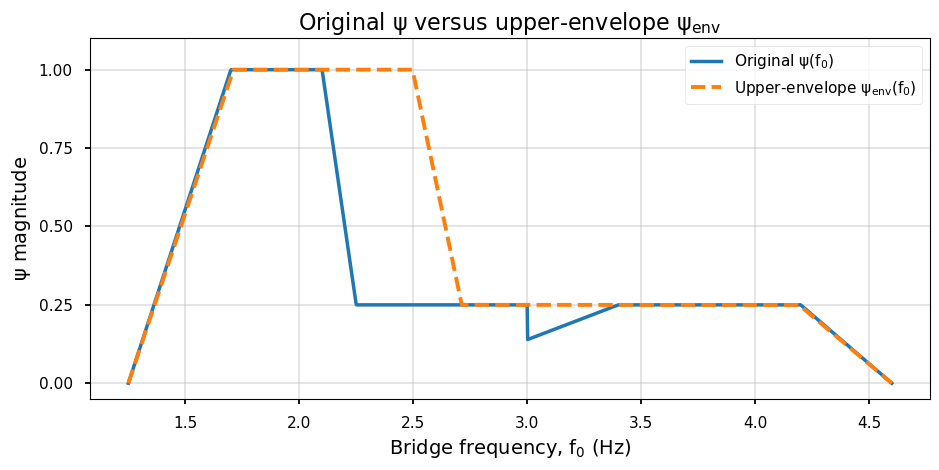

Loading: density1.0000_damping0.005_lm1000_bias_summary.pkl
Loading: density1.0000_damping0.005_lm1500_bias_summary.pkl
Loading: density1.0000_damping0.005_lm2000_bias_summary.pkl
Loading: density1.0000_damping0.005_lm500_bias_summary.pkl
Loading: density1.0000_damping0.005_lm580_bias_summary.pkl
Loading: density1.0000_damping0.005_lm750_bias_summary.pkl
Loading: density1.0000_damping0.010_lm1450_bias_summary.pkl
Loading: density1.0000_damping0.010_lm2900_bias_summary.pkl
Loading: density1.0000_damping0.010_lm483_bias_summary.pkl
Loading: density1.0000_damping0.010_lm580_bias_summary.pkl
Loading: density1.0000_damping0.010_lm725_bias_summary.pkl
Loading: density1.0000_damping0.010_lm967_bias_summary.pkl
Loading: density1.0000_damping0.015_lm1450_bias_summary.pkl
Loading: density1.0000_damping0.015_lm2900_bias_summary.pkl
Loading: density1.0000_damping0.015_lm483_bias_summary.pkl
Loading: density1.0000_damping0.015_lm580_bias_summary.pkl
Loading: density1.0000_damping0.015_lm725_bias_su

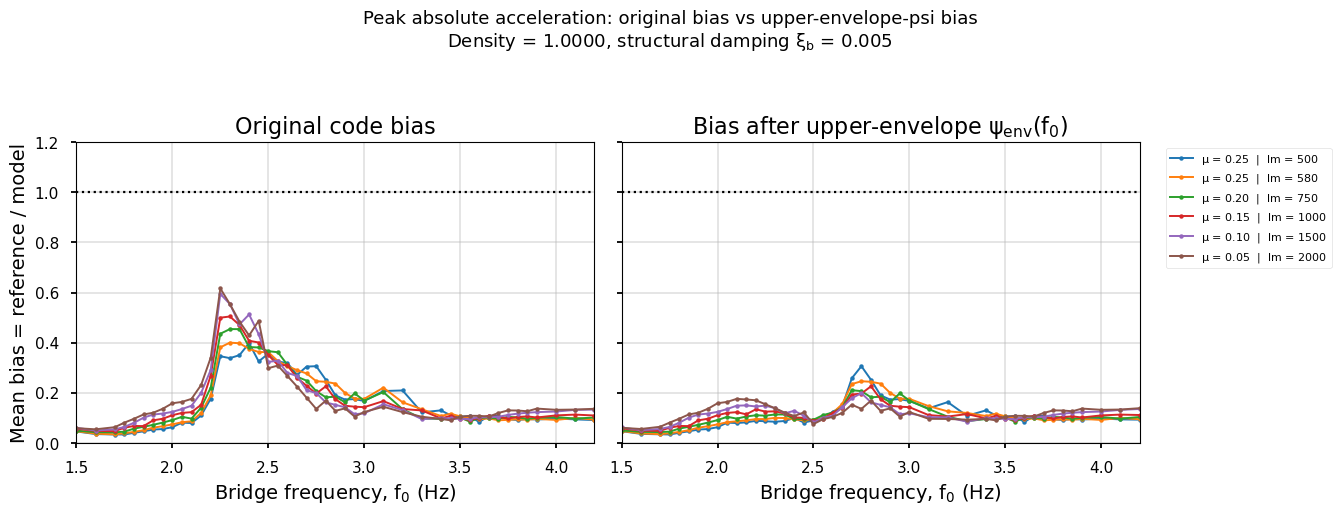

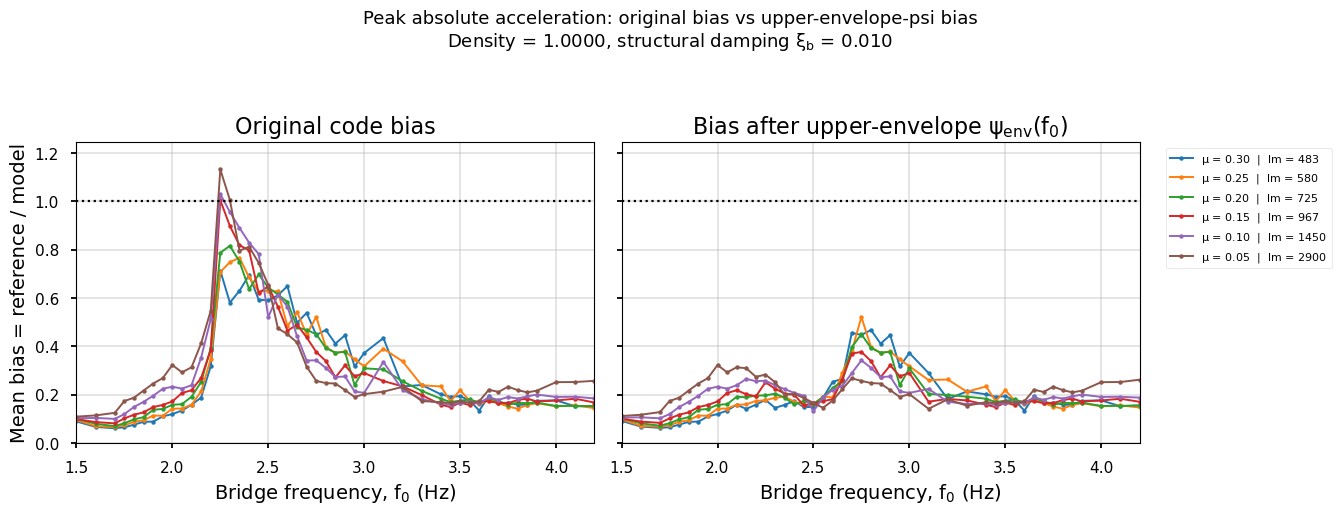

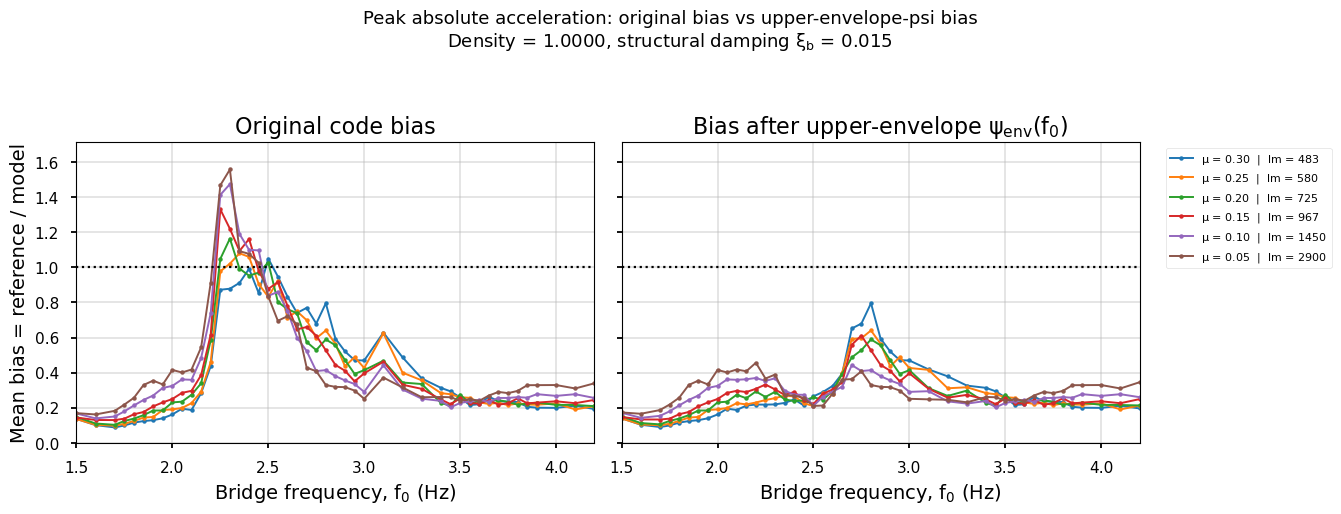

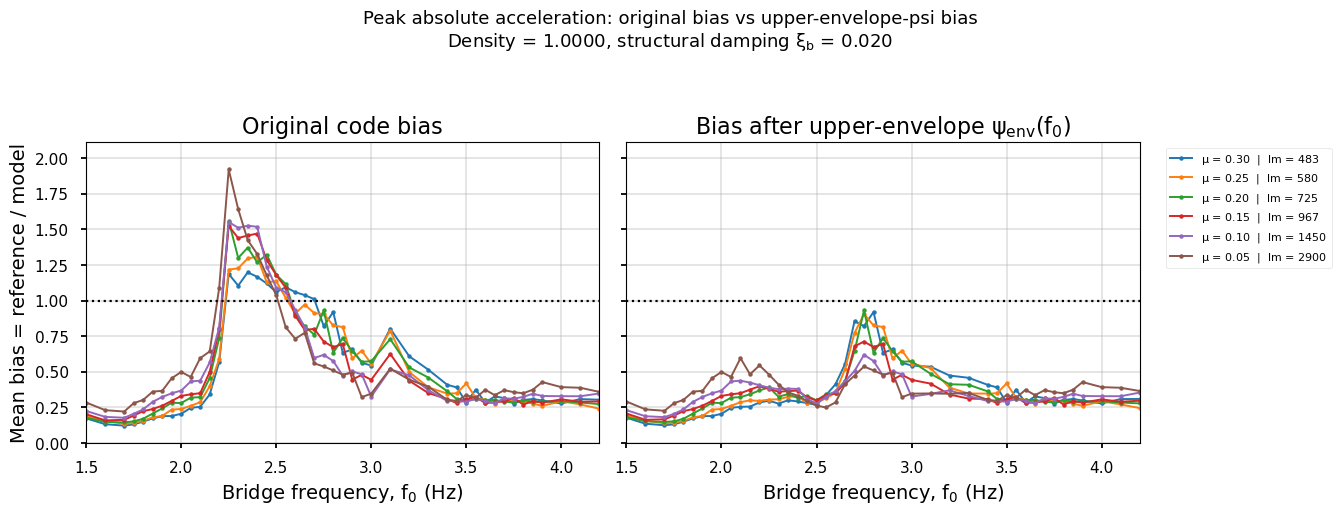

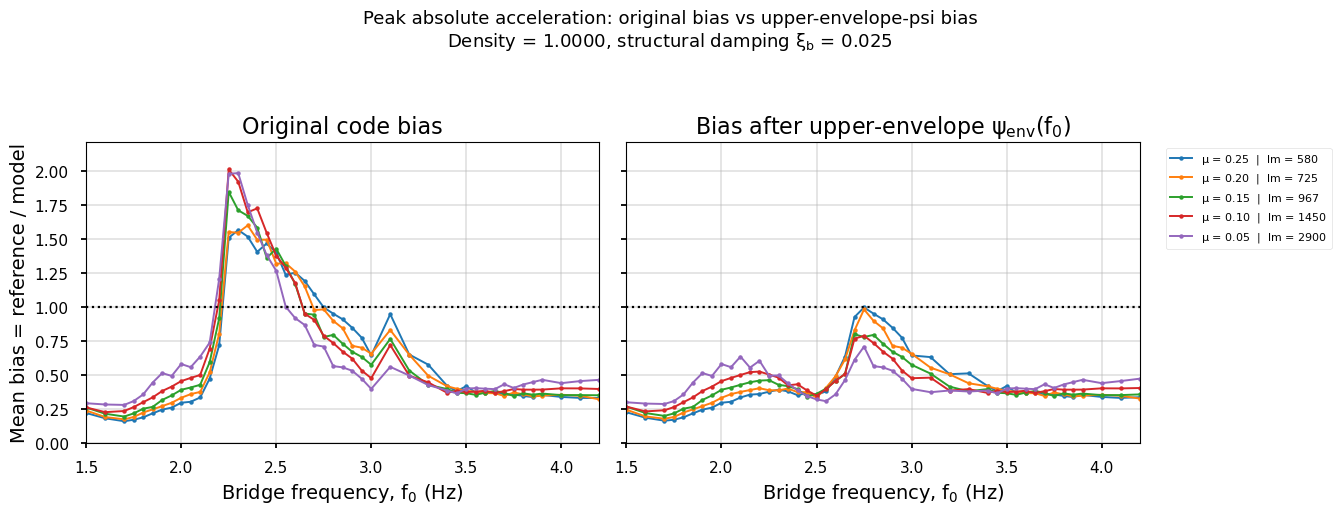

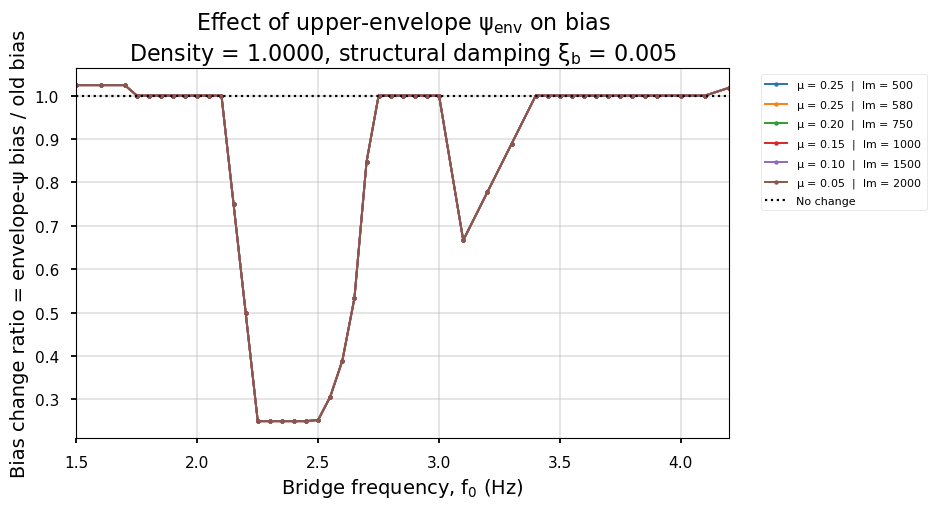

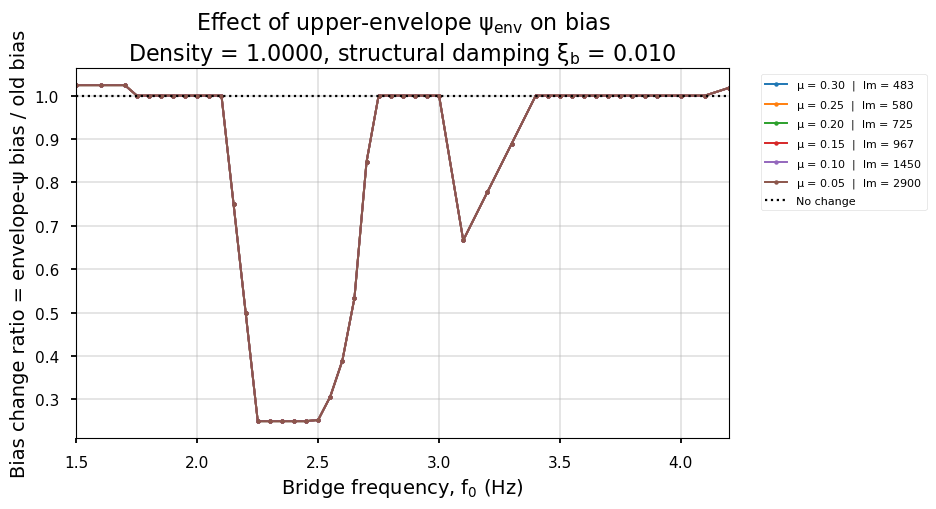

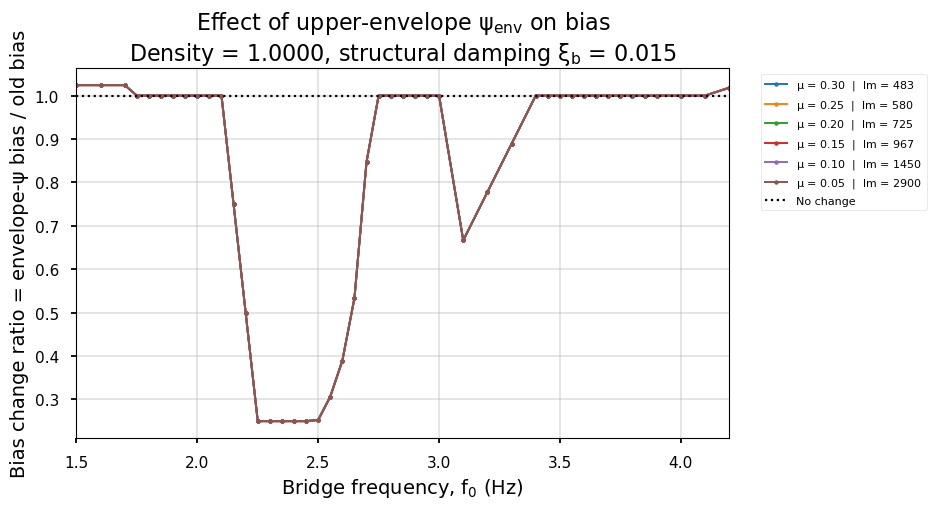

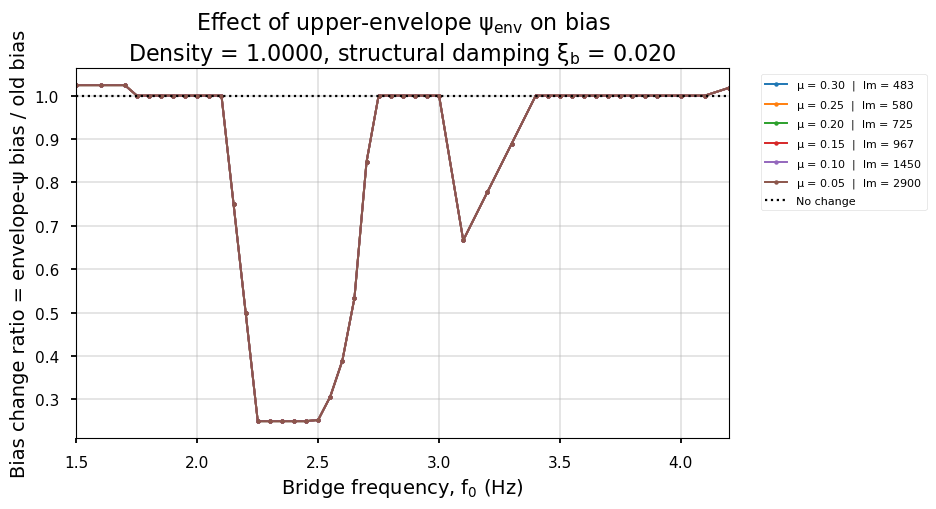

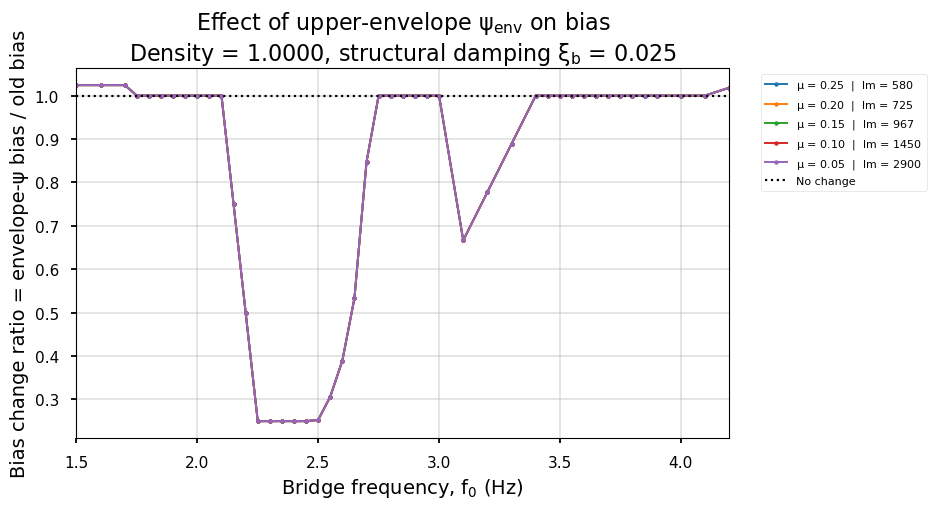


Summary table:
 damping_key  linear_mass_key  mass_ratio  old_bias_mean  env_bias_mean  old_bias_max  env_bias_max  mean_bias_change_ratio
       0.005              500        0.25       0.160823       0.108266      0.398131      0.306204                0.831589
       0.005              580        0.25       0.164763       0.109441      0.400200      0.246178                0.831589
       0.005              750        0.20       0.167101       0.108297      0.454150      0.210449                0.831589
       0.005             1000        0.15       0.173092       0.112188      0.504448      0.226072                0.831589
       0.005             1500        0.10       0.181362       0.116096      0.594561      0.198859                0.831589
       0.005             2000        0.05       0.184129       0.119601      0.616419      0.175922                0.831589
       0.010              483        0.30       0.291698       0.195941      0.712788      0.467535                0

In [38]:
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ==================================================
# SETTINGS
# ==================================================

folder = Path(".")

TARGET_DENSITY = 1.0000

TARGET_DAMPINGS = [0.005, 0.010, 0.015, 0.020, 0.025, 0.030]
# Use None to load all damping ratios found:
# TARGET_DAMPINGS = None

MEASURE_TO_USE = "Peak absolute acceleration"

# This is the column you plotted as original bias / correction factor
OLD_BIAS_COL = "final_modification_factor"

PLOT_FMIN = 1.50
PLOT_FMAX = 4.20

SAVE_FIGURES = False
FIG_DPI = 300

PSI_EPS = 1e-8


# ==================================================
# LINEAR MASS TO MASS RATIO
# Edit this table only if your lm values are different.
# ==================================================

linear_mass_to_mass_ratio = {
    483:  0.30,
    500:  0.30,

    580:  0.25,
    500:  0.25,

    725:  0.20,
    750:  0.20,

    967:  0.15,
    1000: 0.15,

    1450: 0.10,
    1500: 0.10,

    2000: 0.05,
    2900: 0.05,
}


# ==================================================
# ORIGINAL PSI FUNCTION
# Minimum ψ = 0.25 between 2.25 Hz and 3.00 Hz
# ==================================================

def psi_original(f):
    """
    Original pedestrian excitation reduction function ψ(f),
    with minimum ψ = 0.25 between 2.25 Hz and 3.00 Hz.
    """

    f = np.asarray(f, dtype=float)
    psi = np.zeros_like(f)

    # 1.25–1.70 Hz : ramp from 0 to 1
    m = (f >= 1.25) & (f < 1.70)
    psi[m] = (f[m] - 1.25) / (1.70 - 1.25)

    # 1.70–2.10 Hz : full value = 1
    m = (f >= 1.70) & (f <= 2.10)
    psi[m] = 1.0

    # 2.10–2.30 Hz : ramp from 1 to 0
    m = (f > 2.10) & (f <= 2.30)
    psi[m] = (2.30 - f[m]) / (2.30 - 2.10)

    # 2.30–2.50 Hz : zero
    m = (f > 2.30) & (f < 2.50)
    psi[m] = 0.0

    # 2.50–3.40 Hz : ramp from 0 to 0.25
    m = (f >= 2.50) & (f < 3.40)
    psi[m] = 0.25 * (f[m] - 2.50) / (3.40 - 2.50)

    # 3.40–4.20 Hz : constant 0.25
    m = (f >= 3.40) & (f <= 4.20)
    psi[m] = 0.25

    # 4.20–4.60 Hz : ramp from 0.25 to 0
    m = (f > 4.20) & (f <= 4.60)
    psi[m] = 0.25 * (4.60 - f[m]) / (4.60 - 4.20)

    # Minimum ψ = 0.25 for 2.25 Hz <= f <= 3.00 Hz
    m = (f >= 2.25) & (f <= 3.00)
    psi[m] = np.maximum(psi[m], 0.25)

    return psi


# ==================================================
# UPPER-ENVELOPE PSI FUNCTION
#
# Your suggested envelope:
#
# For 1.2500 <= f0 <= 1.7109: psi_env =  2.169878*f0 - 2.712347
# For 1.7109 <= f0 <= 2.4968: psi_env =  1.000000
# For 2.4968 <= f0 <= 2.7130: psi_env = -3.469281*f0 + 9.662183
# For 2.7130 <= f0 <= 4.1928: psi_env =  0.250000
# For 4.1928 <= f0 <= 4.6000: psi_env = -0.613906*f0 + 2.823967
# ==================================================

def psi_upper_envelope(f):
    f = np.asarray(f, dtype=float)
    psi = np.zeros_like(f)

    # Breakpoints
    f_start = 1.2500
    a = 1.7109
    b = 2.4968
    c = 2.7130
    d = 4.1928
    f_end = 4.6000

    # Segment 1: ramp from 0 to 1
    m = (f >= f_start) & (f < a)
    psi[m] = 2.169878 * f[m] - 2.712347

    # Segment 2: plateau at 1
    m = (f >= a) & (f < b)
    psi[m] = 1.0

    # Segment 3: ramp from 1 to 0.25
    m = (f >= b) & (f < c)
    psi[m] = -3.469281 * f[m] + 9.662183

    # Segment 4: plateau at 0.25
    m = (f >= c) & (f < d)
    psi[m] = 0.25

    # Segment 5: ramp from 0.25 to 0
    m = (f >= d) & (f <= f_end)
    psi[m] = -0.613906 * f[m] + 2.823967

    # Outside range: keep zero
    psi = np.clip(psi, 0.0, 1.0)

    return psi


# ==================================================
# QUICK CHECK: PLOT OLD PSI VS UPPER-ENVELOPE PSI
# ==================================================

f_check = np.linspace(1.25, 4.60, 1500)

plt.figure(figsize=(9.5, 4.8))

plt.plot(
    f_check,
    psi_original(f_check),
    linewidth=2.5,
    label=r"Original $\psi(f_0)$"
)

plt.plot(
    f_check,
    psi_upper_envelope(f_check),
    "--",
    linewidth=2.8,
    label=r"Upper-envelope $\psi_{\mathrm{env}}(f_0)$"
)

plt.xlabel(r"Bridge frequency, $f_0$ (Hz)")
plt.ylabel(r"$\psi$ magnitude")
plt.title(r"Original $\psi$ versus upper-envelope $\psi_{\mathrm{env}}$")
plt.ylim(-0.05, 1.10)
plt.yticks([0.00, 0.25, 0.50, 0.75, 1.00])
plt.grid(True, alpha=0.35)
plt.legend()
plt.tight_layout()
plt.show()


# ==================================================
# LOAD lm BIAS FILES
# Expected:
# density1.0000_damping0.005_lm483_bias_summary.pkl
# density1.0000_damping0.005_lm500_bias_summary.pkl
# ==================================================

pattern = re.compile(
    r"density(?P<density>\d+\.\d+)_"
    r"damping(?P<damping>\d+\.\d+)_"
    r"lm(?P<linear_mass>\d+)_"
    r"bias_summary\.pkl$"
)

pkl_files = sorted(folder.glob("density*_damping*_lm*_bias_summary.pkl"))

all_dfs = []

for file in pkl_files:

    match = pattern.match(file.name)

    if match is None:
        print("Skipping unmatched file:", file.name)
        continue

    file_density = float(match.group("density"))
    file_damping = float(match.group("damping"))
    file_linear_mass = int(match.group("linear_mass"))

    if not np.isclose(file_density, TARGET_DENSITY):
        continue

    if TARGET_DAMPINGS is not None:
        if not any(np.isclose(file_damping, d) for d in TARGET_DAMPINGS):
            continue

    print("Loading:", file.name)

    with open(file, "rb") as f:
        df = pickle.load(f)

    if not isinstance(df, pd.DataFrame):
        df = pd.DataFrame(df)

    df = df.copy()

    df["source_file"] = file.name
    df["file_density"] = file_density
    df["file_damping"] = file_damping
    df["linear_mass"] = file_linear_mass

    if "target_density" not in df.columns:
        df["target_density"] = file_density

    if "target_beamdamp" not in df.columns:
        df["target_beamdamp"] = file_damping

    all_dfs.append(df)

if len(all_dfs) == 0:
    raise FileNotFoundError("No matching lm bias summary files found.")

raw_df = pd.concat(all_dfs, ignore_index=True)

print("\nLoaded lm dataframe shape:", raw_df.shape)
print("\nColumns:")
print(raw_df.columns.tolist())


# ==================================================
# CLEAN lm DATA
# ==================================================

needed_cols = [
    "bridge_frequency",
    "target_beamdamp",
    "linear_mass",
    OLD_BIAS_COL,
]

for col in needed_cols:
    if col not in raw_df.columns:
        raise KeyError(f"Missing required column: {col}")

    raw_df[col] = pd.to_numeric(raw_df[col], errors="coerce")

raw_df = raw_df.dropna(subset=needed_cols).copy()

# Keep peak absolute acceleration only
if "measure" in raw_df.columns:
    raw_df = raw_df[
        raw_df["measure"].astype(str).str.strip().eq(MEASURE_TO_USE)
    ].copy()

    if raw_df.empty:
        raise ValueError(
            f"No rows found for measure = '{MEASURE_TO_USE}'."
        )

raw_df["damping_key"] = raw_df["target_beamdamp"].round(3)
raw_df["linear_mass_key"] = raw_df["linear_mass"].round(0).astype(int)

raw_df = raw_df[
    (raw_df["bridge_frequency"] >= PLOT_FMIN) &
    (raw_df["bridge_frequency"] <= PLOT_FMAX)
].copy()

# Stable mass-ratio label from lm
raw_df["mass_ratio"] = raw_df["linear_mass_key"].map(linear_mass_to_mass_ratio)

missing_lm = sorted(
    raw_df.loc[raw_df["mass_ratio"].isna(), "linear_mass_key"].unique()
)

if len(missing_lm) > 0:
    raise ValueError(
        "These linear masses are missing from linear_mass_to_mass_ratio:\n"
        f"{missing_lm}\n\n"
        "Add them to the dictionary near the top."
    )

# Average only exact duplicate points
compare_df = (
    raw_df
    .groupby(
        ["damping_key", "linear_mass_key", "mass_ratio", "bridge_frequency"],
        as_index=False
    )
    .agg(old_bias=(OLD_BIAS_COL, "mean"))
    .sort_values(
        ["damping_key", "linear_mass_key", "bridge_frequency"]
    )
)

print("\nFinal comparison dataframe shape:", compare_df.shape)

print("\nAvailable lm and mass-ratio mapping:")
print(
    compare_df[["linear_mass_key", "mass_ratio"]]
    .drop_duplicates()
    .sort_values("mass_ratio", ascending=False)
    .to_string(index=False)
)

print("\nFrequency coverage:")
coverage = (
    compare_df
    .groupby(["damping_key", "linear_mass_key", "mass_ratio"])["bridge_frequency"]
    .agg(["min", "max", "count"])
    .reset_index()
)
print(coverage)


# ==================================================
# COMPUTE BIAS IF UPPER-ENVELOPE PSI IS USED
# ==================================================

compare_df["psi_old"] = psi_original(
    compare_df["bridge_frequency"].to_numpy(dtype=float)
)

compare_df["psi_env"] = psi_upper_envelope(
    compare_df["bridge_frequency"].to_numpy(dtype=float)
)

psi_old_safe = np.maximum(
    compare_df["psi_old"].to_numpy(dtype=float),
    PSI_EPS
)

psi_env_safe = np.maximum(
    compare_df["psi_env"].to_numpy(dtype=float),
    PSI_EPS
)

# Model_new = Model_old * psi_env / psi_old
# Bias = Reference / Model
# Therefore:
# Bias_new = Bias_old * psi_old / psi_env

compare_df["env_bias"] = (
    compare_df["old_bias"] * psi_old_safe / psi_env_safe
)

compare_df["bias_ratio_env_over_old"] = (
    compare_df["env_bias"] / compare_df["old_bias"]
)

compare_df["psi_scale_env_over_old"] = (
    psi_env_safe / psi_old_safe
)

compare_df.to_csv(
    "old_vs_upper_envelope_psi_bias_from_lm_files.csv",
    index=False
)

print("\nSaved: old_vs_upper_envelope_psi_bias_from_lm_files.csv")


# ==================================================
# PLOT OLD BIAS VS UPPER-ENVELOPE-PSI BIAS
# One figure per damping ratio.
# Each figure has all lm / mass-ratio lines.
# ==================================================

for damping in sorted(compare_df["damping_key"].unique()):

    damp_df = compare_df[
        np.isclose(compare_df["damping_key"], damping)
    ].copy()

    if damp_df.empty:
        continue

    fig, axes = plt.subplots(
        1, 2,
        figsize=(13.5, 5.2),
        sharex=True,
        sharey=True
    )

    plot_specs = [
        ("old_bias", "Original code bias"),
        ("env_bias", r"Bias after upper-envelope $\psi_{\mathrm{env}}(f_0)$"),
    ]

    for ax, (y_col, title) in zip(axes, plot_specs):

        for lm in sorted(damp_df["linear_mass_key"].unique()):

            sub = damp_df[
                damp_df["linear_mass_key"] == lm
            ].copy()

            sub = sub.sort_values("bridge_frequency")

            mu = sub["mass_ratio"].iloc[0]

            ax.plot(
                sub["bridge_frequency"],
                sub[y_col],
                marker="o",
                markersize=3.2,
                linewidth=1.4,
                label=rf"$\mu$ = {mu:.2f}  |  lm = {lm}"
            )

        ax.axhline(
            1.0,
            linestyle=":",
            linewidth=1.6,
            color="black"
        )

        ax.set_title(title)
        ax.set_xlabel(r"Bridge frequency, $f_0$ (Hz)")
        ax.grid(True, alpha=0.35)
        ax.set_xlim(PLOT_FMIN, PLOT_FMAX)

    axes[0].set_ylabel("Mean bias = reference / model")

    ymax = np.nanmax(
        damp_df[["old_bias", "env_bias"]].to_numpy()
    )

    axes[0].set_ylim(0, max(1.2, 1.10 * ymax))

    axes[1].legend(
        bbox_to_anchor=(1.04, 1),
        loc="upper left",
        fontsize=8,
        frameon=True
    )

    fig.suptitle(
        "Peak absolute acceleration: original bias vs upper-envelope-psi bias\n"
        rf"Density = {TARGET_DENSITY:.4f}, structural damping $\xi_b$ = {damping:.3f}",
        fontsize=13
    )

    fig.tight_layout(rect=[0, 0, 1, 0.92])

    if SAVE_FIGURES:
        save_name = (
            f"old_vs_upper_envelope_psi_bias_"
            f"density{TARGET_DENSITY:.4f}_damping{damping:.3f}.png"
        )
        plt.savefig(save_name, dpi=FIG_DPI, bbox_inches="tight")
        print("Saved:", save_name)

    plt.show()


# ==================================================
# OPTIONAL: PLOT HOW MUCH THE BIAS CHANGES
# env_bias / old_bias
# ==================================================

for damping in sorted(compare_df["damping_key"].unique()):

    damp_df = compare_df[
        np.isclose(compare_df["damping_key"], damping)
    ].copy()

    plt.figure(figsize=(9.5, 5.2))

    for lm in sorted(damp_df["linear_mass_key"].unique()):

        sub = damp_df[
            damp_df["linear_mass_key"] == lm
        ].copy()

        sub = sub.sort_values("bridge_frequency")

        mu = sub["mass_ratio"].iloc[0]

        plt.plot(
            sub["bridge_frequency"],
            sub["bias_ratio_env_over_old"],
            marker="o",
            markersize=3.2,
            linewidth=1.4,
            label=rf"$\mu$ = {mu:.2f}  |  lm = {lm}"
        )

    plt.axhline(
        1.0,
        linestyle=":",
        linewidth=1.6,
        color="black",
        label="No change"
    )

    plt.xlabel(r"Bridge frequency, $f_0$ (Hz)")
    plt.ylabel(r"Bias change ratio = envelope-ψ bias / old bias")

    plt.title(
        r"Effect of upper-envelope $\psi_{\mathrm{env}}$ on bias"
        "\n"
        rf"Density = {TARGET_DENSITY:.4f}, structural damping $\xi_b$ = {damping:.3f}"
    )

    plt.xlim(PLOT_FMIN, PLOT_FMAX)
    plt.grid(True, alpha=0.35)
    plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left", fontsize=8)

    plt.tight_layout()
    plt.show()


# ==================================================
# OPTIONAL: SUMMARY TABLE
# ==================================================

summary_df = (
    compare_df
    .groupby(["damping_key", "linear_mass_key", "mass_ratio"], as_index=False)
    .agg(
        old_bias_mean=("old_bias", "mean"),
        env_bias_mean=("env_bias", "mean"),
        old_bias_max=("old_bias", "max"),
        env_bias_max=("env_bias", "max"),
        mean_bias_change_ratio=("bias_ratio_env_over_old", "mean"),
    )
    .sort_values(["damping_key", "mass_ratio"], ascending=[True, False])
)

print("\nSummary table:")
print(summary_df.to_string(index=False))

summary_df.to_csv(
    "summary_upper_envelope_psi_bias_effect.csv",
    index=False
)

print("\nSaved: summary_upper_envelope_psi_bias_effect.csv")


INPUT CHECK PASSED — rho > 1

Number of rho > 1 rows after combining repeated lm cases = 1288

Mass ratios available in rho > 1 model:
[0.05 0.1  0.15 0.2  0.25 0.3 ]

Mass ratios available in population weights:
[0.01 0.05 0.1  0.15 0.2  0.25]

RETAINED rho > 1 POPULATION DOMAIN

Mass ratios:
[0.05 0.1  0.15 0.2  0.25]

Damping ratios:
[0.005 0.01  0.015 0.02  0.025]

Original population probability retained = 0.78418931
Renormalised weight sum = 1.000000000000

ROUGH DIRECT psi-CORRECTION POINTS — rho > 1
      mu     xi_b        w    C_raw
0.050000 0.005000 0.111319 0.175922
0.050000 0.010000 0.075885 0.322651
0.050000 0.015000 0.032875 0.456577
0.050000 0.020000 0.023148 0.595227
0.050000 0.025000 0.009628 0.709442
0.100000 0.005000 0.106904 0.198859
0.100000 0.010000 0.054784 0.341978
0.100000 0.015000 0.023316 0.443370
0.100000 0.020000 0.021276 0.618670
0.100000 0.025000 0.006064 0.789217
0.150000 0.005000 0.074027 0.226072
0.150000 0.010000 0.026501 0.376676
0.150000 0.015000 

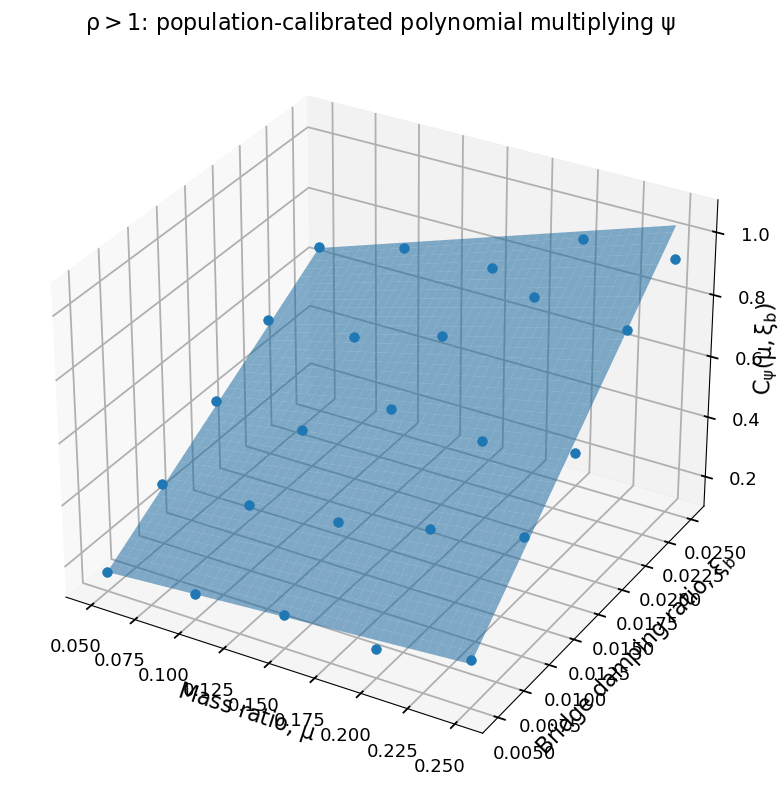

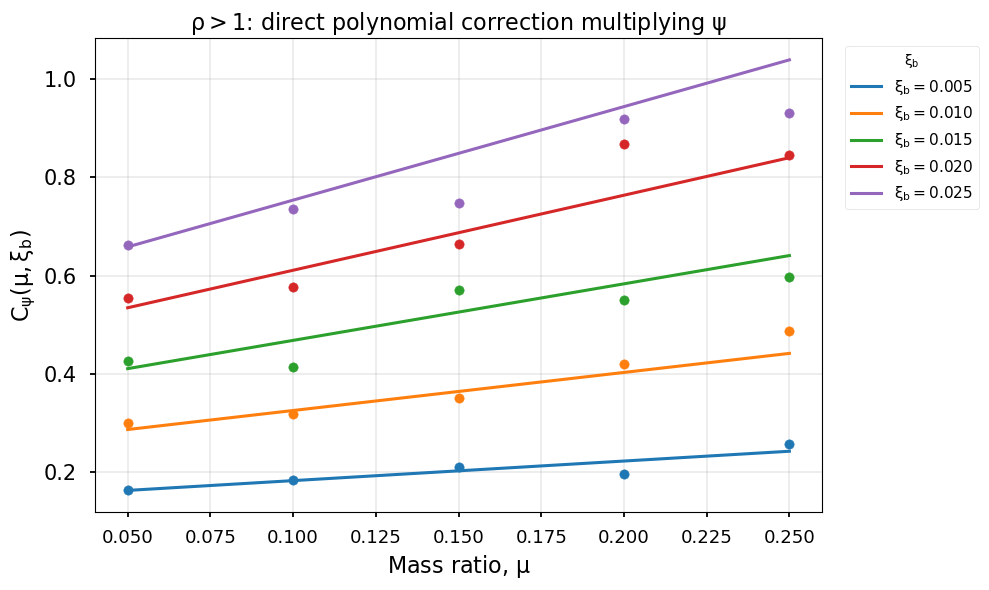

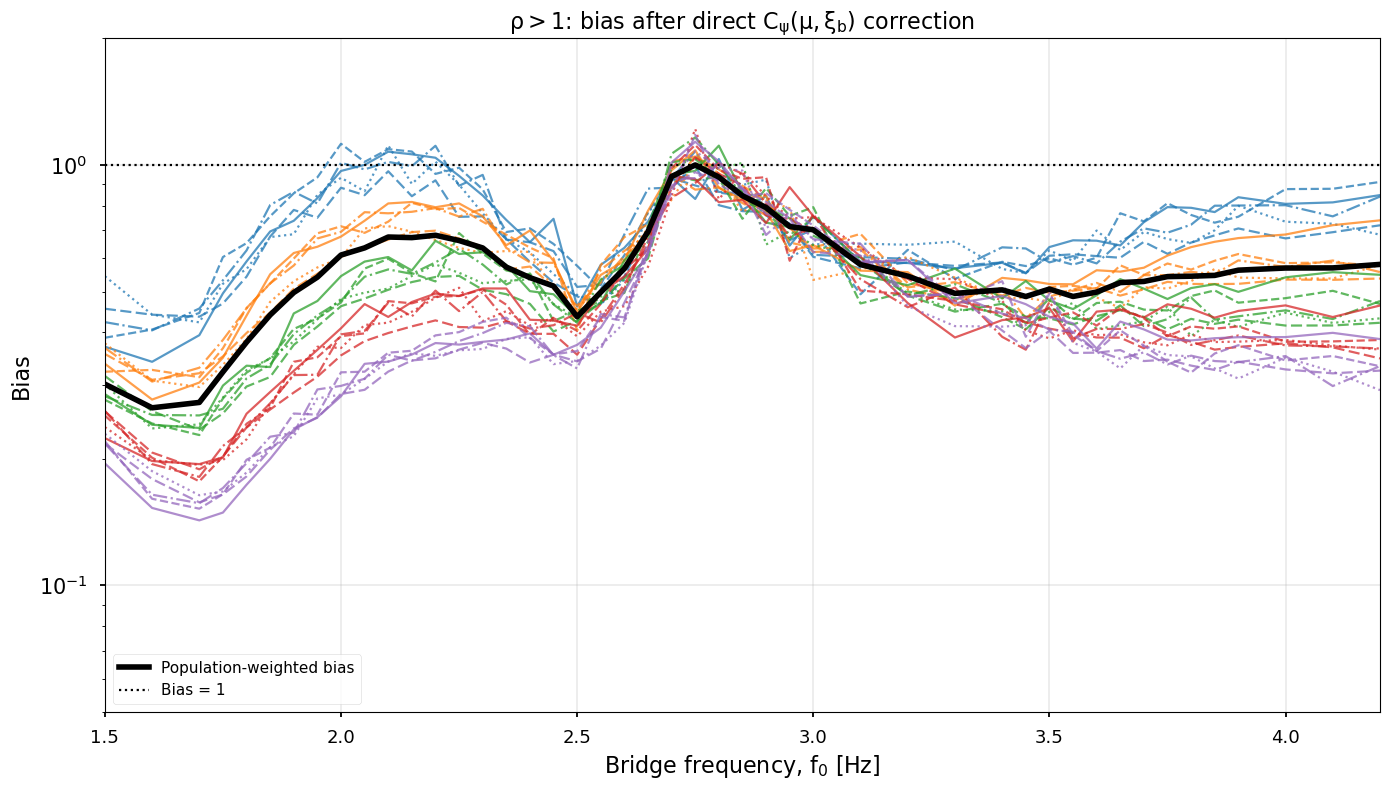


FINAL rho > 1 ASSERTION

max population-weighted bias = 1.000000000000
objective [max(B_W)-1]^2 = 4.930380657631e-32
PASS: maximum population-weighted bias = 1.


In [70]:
# ============================================================
# rho > 1 LOAD MODEL
# DIRECT POPULATION-CALIBRATED POLYNOMIAL MULTIPLIER FOR psi
#
# REQUIRED INPUTS:
#
#   compare_df
#       -> produced by the rho > 1 upper-envelope psi code
#       -> contains:
#          bridge_frequency
#          damping_key
#          mass_ratio
#          psi_env
#          env_bias
#
#   weights_df
#       -> population weights
#       -> contains:
#          mu
#          xi_b
#          weight
#
#
# FINAL MODEL:
#
#   psi_final(f,mu,xi_b)
#   =
#   psi_env(f) * C_psi(mu,xi_b)
#
# where
#
#   C_psi(mu,xi_b)
#   =
#   a + b*mu + c*xi_b + d*mu*xi_b
#
#
# Calibration target:
#
#   max_f [ population-weighted final bias ] = 1
#
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


# ============================================================
# 0. SETTINGS
# ============================================================

BIAS_COLUMN = "env_bias"

CAL_FMIN = 1.50
CAL_FMAX = 4.20

MU_ROUND = 4
XI_ROUND = 4
FREQ_ROUND = 6

EPS = 1e-12


# ============================================================
# 1. CHECK INPUTS
# ============================================================

if "compare_df" not in globals():
    raise RuntimeError(
        "compare_df does not exist.\n"
        "Run the rho > 1 upper-envelope psi/bias code first."
    )

if "weights_df" not in globals():
    raise RuntimeError(
        "weights_df does not exist.\n"
        "Run the population-weight calculation first."
    )


required_bias_cols = [
    "bridge_frequency",
    "mass_ratio",
    "damping_key",
    "psi_env",
    BIAS_COLUMN,
]

missing = [
    col for col in required_bias_cols
    if col not in compare_df.columns
]

if missing:
    raise RuntimeError(
        f"compare_df is missing columns: {missing}"
    )


required_weight_cols = [
    "mu",
    "xi_b",
    "weight",
]

missing = [
    col for col in required_weight_cols
    if col not in weights_df.columns
]

if missing:
    raise RuntimeError(
        f"weights_df is missing columns: {missing}"
    )


print("\n============================================================")
print("INPUT CHECK PASSED — rho > 1")
print("============================================================")


# ============================================================
# 2. PREPARE rho > 1 BIAS DATA
#
# compare_df can contain more than one linear-mass case
# corresponding to the same (mu, xi_b).
#
# Population weights are defined by (mu, xi_b), so first
# create ONE representative bias line for each (mu, xi_b)
# by averaging duplicate lm cases at each frequency.
# ============================================================

bias_df = compare_df[
    [
        "bridge_frequency",
        "mass_ratio",
        "damping_key",
        "psi_env",
        BIAS_COLUMN,
    ]
].copy()


for col in [
    "bridge_frequency",
    "mass_ratio",
    "damping_key",
    "psi_env",
    BIAS_COLUMN,
]:
    bias_df[col] = pd.to_numeric(
        bias_df[col],
        errors="coerce"
    )


bias_df = bias_df.dropna(
    subset=[
        "bridge_frequency",
        "mass_ratio",
        "damping_key",
        "psi_env",
        BIAS_COLUMN,
    ]
).copy()


# ============================================================
# 3. CALIBRATION FREQUENCY RANGE
# ============================================================

bias_df = bias_df[
    (bias_df["bridge_frequency"] >= CAL_FMIN)
    &
    (bias_df["bridge_frequency"] <= CAL_FMAX)
].copy()


if bias_df.empty:
    raise ValueError(
        "No rho > 1 bias data between 1.5 and 4.2 Hz."
    )


# ============================================================
# 4. ROBUST KEYS
# ============================================================

bias_df["mu_key"] = (
    bias_df["mass_ratio"]
    .round(MU_ROUND)
)

bias_df["xi_key"] = (
    bias_df["damping_key"]
    .round(XI_ROUND)
)

bias_df["f_key"] = (
    bias_df["bridge_frequency"]
    .round(FREQ_ROUND)
)


# ============================================================
# 5. COLLAPSE REPEATED LINEAR-MASS CASES
#
# This gives one bias value for each:
#
#       (f, mu, xi_b)
#
# which is what is required for the population weighting.
# ============================================================

cal_df = (
    bias_df
    .groupby(
        [
            "f_key",
            "mu_key",
            "xi_key",
        ],
        as_index=False
    )
    .agg(
        bridge_frequency=("bridge_frequency", "mean"),
        mass_ratio=("mass_ratio", "first"),
        xi_b=("damping_key", "first"),
        psi_env=("psi_env", "mean"),
        env_bias=(BIAS_COLUMN, "mean"),
    )
    .sort_values(
        [
            "mu_key",
            "xi_key",
            "bridge_frequency",
        ]
    )
    .reset_index(drop=True)
)


print(
    f"\nNumber of rho > 1 rows after combining "
    f"repeated lm cases = {len(cal_df)}"
)


# ============================================================
# 6. PREPARE POPULATION WEIGHTS
# ============================================================

wdf = weights_df[
    [
        "mu",
        "xi_b",
        "weight",
    ]
].copy()


for col in [
    "mu",
    "xi_b",
    "weight",
]:
    wdf[col] = pd.to_numeric(
        wdf[col],
        errors="coerce"
    )


wdf = wdf.dropna().copy()


wdf["mu_key"] = (
    wdf["mu"]
    .round(MU_ROUND)
)

wdf["xi_key"] = (
    wdf["xi_b"]
    .round(XI_ROUND)
)


# ============================================================
# 7. KEEP ONLY COMMON (mu, xi_b) COMBINATIONS
# ============================================================

available_combos = (
    cal_df[
        [
            "mu_key",
            "xi_key",
        ]
    ]
    .drop_duplicates()
)


# Show model combinations before intersection
model_mu = np.sort(
    cal_df["mu_key"].unique()
)

weight_mu = np.sort(
    wdf["mu_key"].unique()
)


print("\nMass ratios available in rho > 1 model:")
print(model_mu)

print("\nMass ratios available in population weights:")
print(weight_mu)


wdf = wdf.merge(
    available_combos,
    on=[
        "mu_key",
        "xi_key",
    ],
    how="inner"
)


if wdf.empty:
    raise ValueError(
        "No common (mu,xi_b) combinations between "
        "rho > 1 bias data and population weights."
    )


# ------------------------------------------------------------
# Renormalise over retained population domain
# ------------------------------------------------------------

retained_probability = (
    wdf["weight"].sum()
)


wdf["w"] = (
    wdf["weight"]
    /
    retained_probability
)


cal_df = cal_df.merge(
    wdf[
        [
            "mu_key",
            "xi_key",
            "w",
        ]
    ],
    on=[
        "mu_key",
        "xi_key",
    ],
    how="inner"
)


print("\n============================================================")
print("RETAINED rho > 1 POPULATION DOMAIN")
print("============================================================")

print("\nMass ratios:")
print(
    np.sort(
        cal_df["mass_ratio"].unique()
    )
)

print("\nDamping ratios:")
print(
    np.sort(
        cal_df["xi_b"].unique()
    )
)

print(
    f"\nOriginal population probability retained = "
    f"{retained_probability:.8f}"
)

print(
    f"Renormalised weight sum = "
    f"{wdf['w'].sum():.12f}"
)


# ============================================================
# 8. ROUGH DIRECT psi-CORRECTION POINTS
#
# For each (mu,xi):
#
#       C_raw = max_f B_env(f)
#
# These provide the INITIAL SHAPE of the correction surface.
# ============================================================

surface_df = (
    cal_df
    .groupby(
        [
            "mu_key",
            "xi_key",
        ],
        as_index=False
    )
    .agg(
        mu=("mass_ratio", "first"),
        xi_b=("xi_b", "first"),
        w=("w", "first"),
        C_raw=("env_bias", "max"),
    )
    .sort_values(
        [
            "mu_key",
            "xi_key",
        ]
    )
    .reset_index(drop=True)
)


surface_df["w"] = (
    surface_df["w"]
    /
    surface_df["w"].sum()
)


print("\n============================================================")
print("ROUGH DIRECT psi-CORRECTION POINTS — rho > 1")
print("============================================================")

print(
    surface_df[
        [
            "mu",
            "xi_b",
            "w",
            "C_raw",
        ]
    ]
    .to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# ============================================================
# 9. INITIAL POPULATION-WEIGHTED BILINEAR FIT
#
#       C0(mu,xi)
#
#       =
#
#       a0 + b0*mu + c0*xi + d0*mu*xi
#
# This establishes the SHAPE of the surface.
# ============================================================

mu = (
    surface_df["mu"]
    .to_numpy(dtype=float)
)

xi = (
    surface_df["xi_b"]
    .to_numpy(dtype=float)
)

w = (
    surface_df["w"]
    .to_numpy(dtype=float)
)

C_raw = (
    surface_df["C_raw"]
    .to_numpy(dtype=float)
)


X = np.column_stack(
    [
        np.ones_like(mu),
        mu,
        xi,
        mu * xi,
    ]
)


sqrt_w = np.sqrt(w)

Xw = (
    X
    *
    sqrt_w[:, None]
)

yw = (
    C_raw
    *
    sqrt_w
)


beta0, _, _, _ = np.linalg.lstsq(
    Xw,
    yw,
    rcond=None
)


a0, b0, c0, d0 = beta0


surface_df["C_fit_initial"] = (
    X @ beta0
)


if np.any(
    surface_df["C_fit_initial"] <= 0
):
    raise ValueError(
        "Initial rho > 1 fitted psi correction becomes <= 0."
    )


print("\n============================================================")
print("INITIAL rho > 1 psi POLYNOMIAL")
print("============================================================")

print(
    "\nC0(mu,xi_b) = "
    f"{a0:.8f} "
    f"{b0:+.8f}*mu "
    f"{c0:+.8f}*xi_b "
    f"{d0:+.8f}*mu*xi_b"
)


# ============================================================
# 10. BUILD COMMON BIAS MATRIX
#
# rows    = frequency
# columns = (mu,xi_b)
# ============================================================

pivot = (
    cal_df
    .pivot_table(
        index="f_key",
        columns=[
            "mu_key",
            "xi_key",
        ],
        values="env_bias",
        aggfunc="mean"
    )
    .sort_index()
)


combo_order = [
    (
        row.mu_key,
        row.xi_key
    )
    for row in surface_df.itertuples()
]


missing_combos = [
    combo
    for combo in combo_order
    if combo not in pivot.columns
]


if missing_combos:
    raise ValueError(
        "Missing rho > 1 combinations in bias matrix:\n"
        f"{missing_combos}"
    )


pivot = pivot[
    combo_order
].copy()


n_before = len(pivot)

pivot = pivot.dropna(
    axis=0,
    how="any"
)

n_after = len(pivot)


print(
    f"\nCommon frequency points used = "
    f"{n_after} / {n_before}"
)


if pivot.empty:
    raise ValueError(
        "No common frequencies across rho > 1 bias lines."
    )


frequencies = (
    pivot.index
    .to_numpy(dtype=float)
)

B = (
    pivot
    .to_numpy(dtype=float)
)

w_vector = (
    surface_df["w"]
    .to_numpy(dtype=float)
)


# ============================================================
# 11. POPULATION-WEIGHTED BIAS BEFORE SECOND psi CORRECTION
# ============================================================

B_weighted_before = (
    B @ w_vector
)


peak_before_index = int(
    np.argmax(B_weighted_before)
)

peak_before = float(
    B_weighted_before[
        peak_before_index
    ]
)

f_peak_before = float(
    frequencies[
        peak_before_index
    ]
)


print("\n============================================================")
print("BEFORE mu-xi CORRECTION — rho > 1")
print("============================================================")

print(
    f"\nMaximum population-weighted env bias = "
    f"{peak_before:.10f}"
)

print(
    f"Governing frequency = "
    f"{f_peak_before:.4f} Hz"
)


# ============================================================
# 12. APPLY INITIAL POLYNOMIAL
#
# psi0 = psi_env * C0
#
# Evaluate resulting population-weighted bias.
# ============================================================

C0 = (
    surface_df["C_fit_initial"]
    .to_numpy(dtype=float)
)


B_weighted_initial_fit = (
    B @ (
        w_vector
        /
        C0
    )
)


peak_initial_fit = float(
    np.max(
        B_weighted_initial_fit
    )
)


f_peak_initial = float(
    frequencies[
        np.argmax(
            B_weighted_initial_fit
        )
    ]
)


objective_initial = (
    peak_initial_fit
    -
    1.0
)**2


print("\n============================================================")
print("AFTER INITIAL SURFACE FIT — rho > 1")
print("============================================================")

print(
    f"\nMaximum population-weighted bias = "
    f"{peak_initial_fit:.10f}"
)

print(
    f"Governing frequency = "
    f"{f_peak_initial:.4f} Hz"
)

print(
    f"Objective [max(B_W)-1]^2 = "
    f"{objective_initial:.12e}"
)


# ============================================================
# 13. CALIBRATE THE POLYNOMIAL MAGNITUDE
#
# Objective:
#
#       J = [max_f B_W(f) - 1]^2
#
# If:
#
#       C_final = S * C0
#
# then:
#
#       B_W,final = B_W,0 / S
#
# Therefore the exact solution is:
#
#       S = max_f B_W,0
# ============================================================

POPULATION_SCALE = (
    peak_initial_fit
)


beta_final = (
    POPULATION_SCALE
    *
    beta0
)


a, b, c, d = beta_final


surface_df["C_psi"] = (
    X @ beta_final
)


if np.any(
    surface_df["C_psi"] <= 0
):
    raise ValueError(
        "Final rho > 1 psi correction becomes <= 0."
    )


# Rough points scaled by the same population calibration
surface_df["C_target_population"] = (
    POPULATION_SCALE
    *
    surface_df["C_raw"]
)


# ============================================================
# 14. FINAL POPULATION-WEIGHTED BIAS
# ============================================================

C_final = (
    surface_df["C_psi"]
    .to_numpy(dtype=float)
)


B_weighted_final = (
    B @ (
        w_vector
        /
        C_final
    )
)


peak_final_index = int(
    np.argmax(
        B_weighted_final
    )
)


peak_final = float(
    B_weighted_final[
        peak_final_index
    ]
)


f_peak_final = float(
    frequencies[
        peak_final_index
    ]
)


objective_final = (
    peak_final
    -
    1.0
)**2


# ============================================================
# 15. FIT STATISTICS
# ============================================================

C_target = (
    surface_df["C_target_population"]
    .to_numpy(dtype=float)
)

C_prediction = (
    surface_df["C_psi"]
    .to_numpy(dtype=float)
)


weighted_rmse = np.sqrt(
    np.sum(
        w_vector
        *
        (
            C_target
            -
            C_prediction
        )**2
    )
)


target_mean = np.sum(
    w_vector
    *
    C_target
)


ss_res = np.sum(
    w_vector
    *
    (
        C_target
        -
        C_prediction
    )**2
)


ss_tot = np.sum(
    w_vector
    *
    (
        C_target
        -
        target_mean
    )**2
)


weighted_r2 = (
    1.0
    -
    ss_res / ss_tot
    if ss_tot > EPS
    else np.nan
)


# ============================================================
# 16. FINAL RESULTS
# ============================================================

print("\n")
print("=" * 72)
print("FINAL rho > 1 POLYNOMIAL THAT MULTIPLIES psi")
print("=" * 72)


print(
    "\nC_psi(mu,xi_b) = "
    f"{a:.8f} "
    f"{b:+.8f}*mu "
    f"{c:+.8f}*xi_b "
    f"{d:+.8f}*mu*xi_b"
)


print("\nFINAL psi MODEL:")

print(
    "psi_final(f,mu,xi_b)"
    " = psi_env(f) * C_psi(mu,xi_b)"
)


print(
    f"\nPopulation scale S = "
    f"{POPULATION_SCALE:.10f}"
)


print(
    f"\nWeighted RMSE = "
    f"{weighted_rmse:.8f}"
)

print(
    f"Weighted R² = "
    f"{weighted_r2:.6f}"
)


print("\nFINAL CALIBRATION CHECK:")

print(
    f"Maximum population-weighted bias = "
    f"{peak_final:.12f}"
)

print(
    f"Governing frequency = "
    f"{f_peak_final:.4f} Hz"
)

print(
    f"Final objective [max(B_W)-1]^2 = "
    f"{objective_final:.12e}"
)


print(
    f"\nMinimum C_psi = "
    f"{C_final.min():.8f}"
)

print(
    f"Maximum C_psi = "
    f"{C_final.max():.8f}"
)


# ============================================================
# 17. ROUGH POINTS / FINAL SURFACE TABLE
# ============================================================

print("\n")
print("=" * 72)
print("rho > 1 ROUGH POINTS AND FINAL POLYNOMIAL")
print("=" * 72)


print(
    surface_df[
        [
            "mu",
            "xi_b",
            "w",
            "C_raw",
            "C_target_population",
            "C_psi",
        ]
    ]
    .to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# ============================================================
# 18. 3D SURFACE
# ============================================================

mu_grid = np.linspace(
    surface_df["mu"].min(),
    surface_df["mu"].max(),
    120
)

xi_grid = np.linspace(
    surface_df["xi_b"].min(),
    surface_df["xi_b"].max(),
    120
)


MU, XI = np.meshgrid(
    mu_grid,
    xi_grid
)


C_SURFACE = (
    a
    +
    b * MU
    +
    c * XI
    +
    d * MU * XI
)


fig = plt.figure(
    figsize=(11, 8)
)

ax = fig.add_subplot(
    111,
    projection="3d"
)


ax.plot_surface(
    MU,
    XI,
    C_SURFACE,
    alpha=0.55,
    linewidth=0
)


ax.scatter(
    surface_df["mu"],
    surface_df["xi_b"],
    surface_df["C_target_population"],
    s=50,
    depthshade=False
)


ax.set_xlabel(
    r"Mass ratio, $\mu$"
)

ax.set_ylabel(
    r"Bridge damping ratio, $\xi_b$"
)

ax.set_zlabel(
    r"$C_\psi(\mu,\xi_b)$"
)

ax.set_title(
    r"$\rho>1$: population-calibrated polynomial multiplying $\psi$"
)


plt.tight_layout()
plt.show()


# ============================================================
# 19. 2D SURFACE SLICES
#
# Dots  = rough population-calibrated correction values
# Lines = final polynomial
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 6)
)


xi_levels = np.sort(
    surface_df["xi_b"].unique()
)


mu_fine = np.linspace(
    surface_df["mu"].min(),
    surface_df["mu"].max(),
    300
)


for xi_value in xi_levels:

    C_line = (
        a
        +
        b * mu_fine
        +
        c * xi_value
        +
        d * mu_fine * xi_value
    )


    line = ax.plot(
        mu_fine,
        C_line,
        linewidth=2.2,
        label=rf"$\xi_b={xi_value:.3f}$"
    )[0]


    sub = surface_df[
        np.isclose(
            surface_df["xi_b"],
            xi_value
        )
    ].copy()


    ax.scatter(
        sub["mu"],
        sub["C_target_population"],
        color=line.get_color(),
        s=45,
        zorder=3
    )


ax.set_xlabel(
    r"Mass ratio, $\mu$"
)

ax.set_ylabel(
    r"$C_\psi(\mu,\xi_b)$"
)

ax.set_title(
    r"$\rho>1$: direct polynomial correction multiplying $\psi$"
)

ax.grid(
    True,
    alpha=0.25
)

ax.legend(
    title=r"$\xi_b$",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)


plt.tight_layout()
plt.show()


# ============================================================
# 20. APPLY FINAL POLYNOMIAL TO ALL rho > 1 DATA
# ============================================================

final_df = cal_df.copy()


mu_all = (
    final_df["mass_ratio"]
    .to_numpy(dtype=float)
)

xi_all = (
    final_df["xi_b"]
    .to_numpy(dtype=float)
)


final_df["C_psi"] = (
    a
    +
    b * mu_all
    +
    c * xi_all
    +
    d * mu_all * xi_all
)


final_df["psi_final"] = (
    final_df["psi_env"]
    *
    final_df["C_psi"]
)


final_df["bias_final"] = (
    final_df["env_bias"]
    /
    final_df["C_psi"]
)


final_df["weighted_bias_term"] = (
    final_df["w"]
    *
    final_df["bias_final"]
)


# ============================================================
# 21. FINAL POPULATION-WEIGHTED BIAS DATAFRAME
# ============================================================

weighted_bias_df = (
    final_df
    .groupby(
        "f_key",
        as_index=False
    )
    .agg(
        bridge_frequency=(
            "bridge_frequency",
            "mean"
        ),
        weighted_sum=(
            "weighted_bias_term",
            "sum"
        ),
        weight_sum=(
            "w",
            "sum"
        ),
    )
    .sort_values(
        "bridge_frequency"
    )
)


weighted_bias_df["weighted_bias"] = (
    weighted_bias_df["weighted_sum"]
    /
    weighted_bias_df["weight_sum"]
)


# ============================================================
# 22. FINAL BIAS FIGURE
#
# Colour = mu
# Line style = xi_b
# Black = population-weighted bias
# ============================================================

mu_levels = np.sort(
    final_df["mass_ratio"].unique()
)

xi_levels = np.sort(
    final_df["xi_b"].unique()
)


base_colors = (
    plt.rcParams[
        "axes.prop_cycle"
    ]
    .by_key()["color"]
)


mu_colors = {
    mu_value:
    base_colors[
        i % len(base_colors)
    ]
    for i, mu_value
    in enumerate(mu_levels)
}


line_styles = [
    "-",
    "--",
    "-.",
    ":",
    (0, (5, 2)),
    (0, (3, 1, 1, 1)),
]


xi_styles = {
    xi_value:
    line_styles[
        i % len(line_styles)
    ]
    for i, xi_value
    in enumerate(xi_levels)
}


fig, ax = plt.subplots(
    figsize=(14, 8)
)


for mu_value in mu_levels:

    for xi_value in xi_levels:

        sub = final_df[
            np.isclose(
                final_df["mass_ratio"],
                mu_value
            )
            &
            np.isclose(
                final_df["xi_b"],
                xi_value
            )
        ].copy()


        if sub.empty:
            continue


        sub = sub.sort_values(
            "bridge_frequency"
        )


        ax.plot(
            sub["bridge_frequency"],
            sub["bias_final"],
            color=mu_colors[mu_value],
            linestyle=xi_styles[xi_value],
            linewidth=1.6,
            alpha=0.75
        )


# Population-weighted line
ax.plot(
    weighted_bias_df["bridge_frequency"],
    weighted_bias_df["weighted_bias"],
    color="black",
    linewidth=4,
    label="Population-weighted bias"
)


ax.axhline(
    1.0,
    color="black",
    linestyle=":",
    linewidth=1.6,
    label="Bias = 1"
)


ax.set_xlim(
    CAL_FMIN,
    CAL_FMAX
)

ax.set_yscale(
    "log"
)

ax.set_ylim(
    0.05,
    max(
        2.0,
        1.10 * final_df["bias_final"].max()
    )
)


ax.set_xlabel(
    r"Bridge frequency, $f_0$ [Hz]"
)

ax.set_ylabel(
    "Bias"
)

ax.set_title(
    r"$\rho>1$: bias after direct $C_\psi(\mu,\xi_b)$ correction"
)

ax.grid(
    True,
    alpha=0.25
)

ax.legend(
    loc="lower left"
)


plt.tight_layout()
plt.show()


# ============================================================
# 23. FINAL ASSERTION
# ============================================================

final_check = (
    weighted_bias_df[
        "weighted_bias"
    ].max()
)


print("\n============================================================")
print("FINAL rho > 1 ASSERTION")
print("============================================================")

print(
    f"\nmax population-weighted bias = "
    f"{final_check:.12f}"
)

print(
    f"objective [max(B_W)-1]^2 = "
    f"{(final_check - 1.0)**2:.12e}"
)


if np.isclose(
    final_check,
    1.0,
    atol=1e-8
):
    print(
        "PASS: maximum population-weighted bias = 1."
    )
else:
    print(
        "WARNING: maximum population-weighted bias is not 1."
    )

In [62]:
# Save rho > 1 result
a_high, b_high, c_high, d_high = a, b, c, d
surface_high = surface_df.copy()

# Save rho > 1 final bias results
final_df_high = final_df.copy()
weighted_bias_high = weighted_bias_df.copy()


rho > 1 FINAL DIRECT psi MODEL

C_psi(mu,xi_b) = 0.03130095 +0.07037702*mu +21.17901970*xi_b +77.27206730*mu*xi_b

Population-weighted correction:
C_population = sum(w_i C_i) = 0.32026152

Population-weighted psi:
psi_population(f) = 0.32026152 * psi_upper_envelope(f)


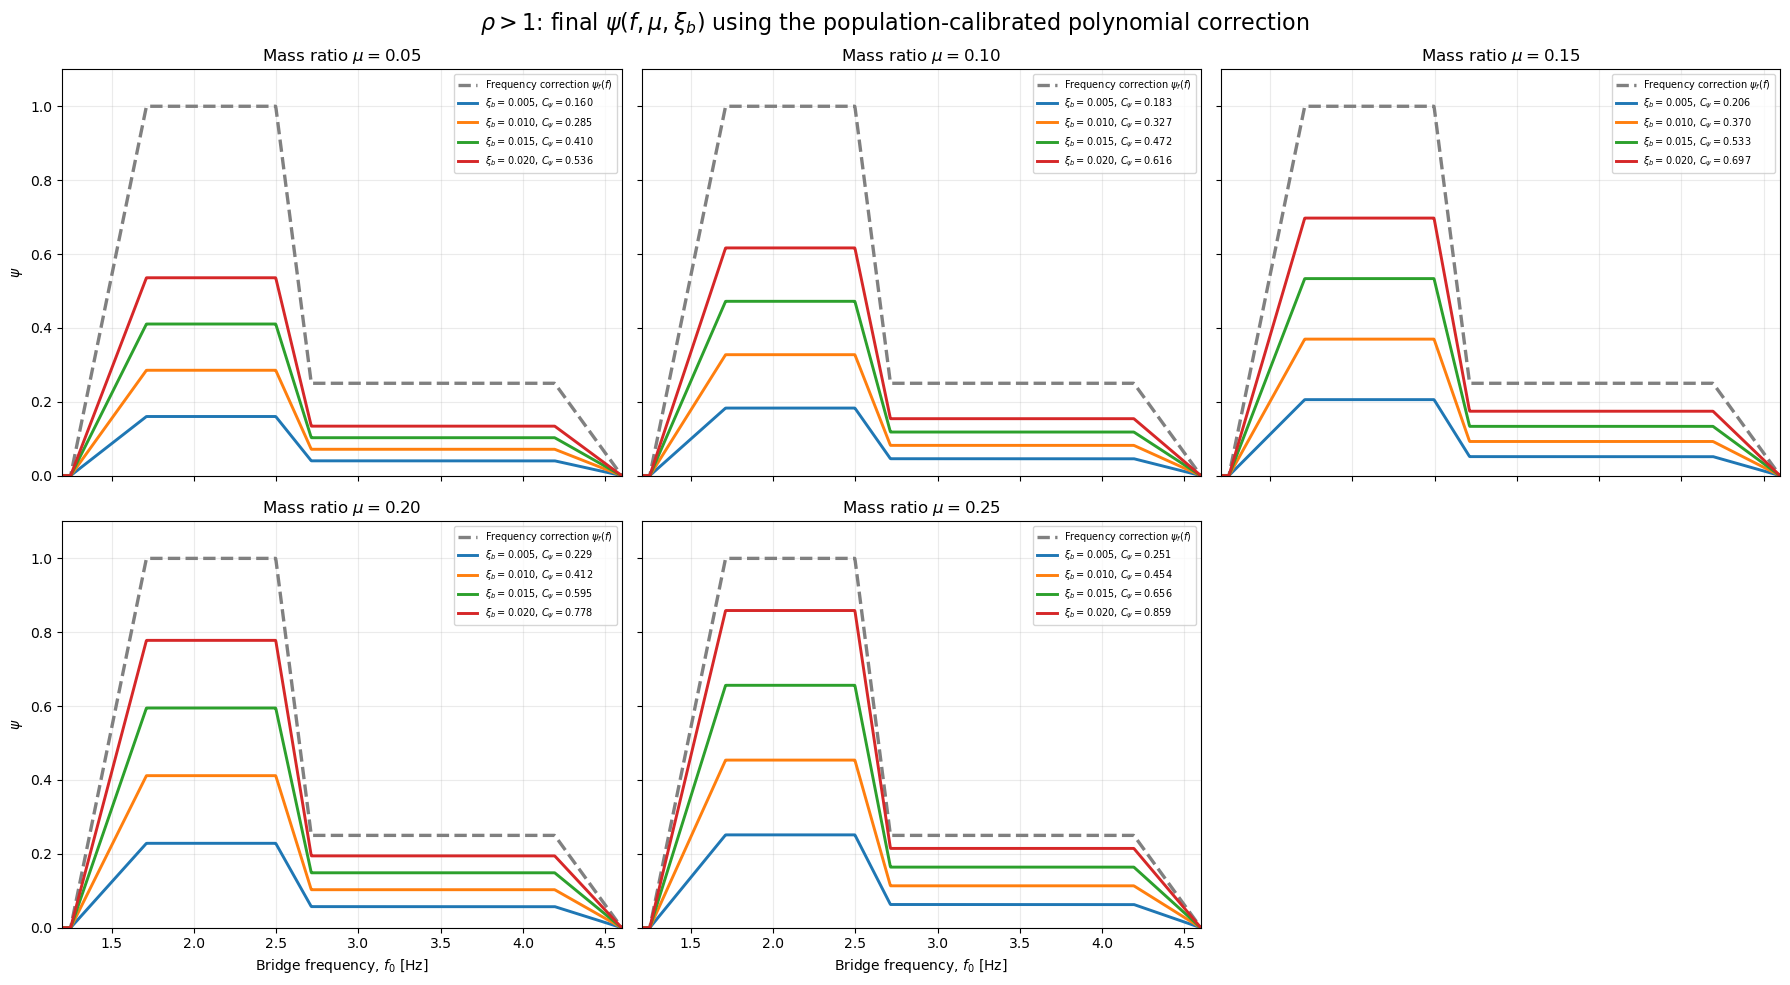

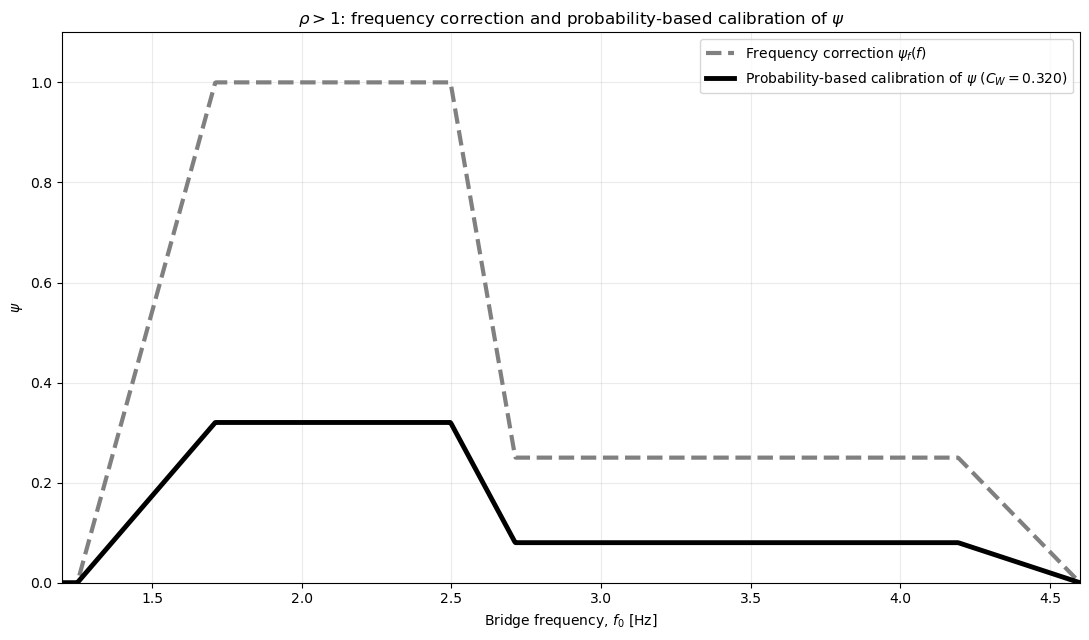


rho > 1 INDIVIDUAL psi CORRECTIONS
      mu     xi_b        w    C_psi
0.050000 0.005000 0.114847 0.160033
0.050000 0.010000 0.078289 0.285246
0.050000 0.015000 0.033916 0.410459
0.050000 0.020000 0.023882 0.535672
0.100000 0.005000 0.110292 0.182870
0.100000 0.010000 0.056520 0.327401
0.100000 0.015000 0.024054 0.471932
0.100000 0.020000 0.021950 0.616463
0.150000 0.005000 0.076373 0.205707
0.150000 0.010000 0.027340 0.369556
0.150000 0.015000 0.009761 0.533405
0.150000 0.020000 0.009963 0.697254
0.200000 0.005000 0.152745 0.228544
0.200000 0.010000 0.054681 0.411711
0.200000 0.015000 0.019523 0.594878
0.200000 0.020000 0.019927 0.778045
0.250000 0.005000 0.089197 0.251380
0.250000 0.010000 0.044323 0.453866
0.250000 0.015000 0.017813 0.656351
0.250000 0.020000 0.014603 0.858836


In [26]:
# ============================================================
# rho > 1
# PLOT FINAL psi CURVES USING THE DIRECT POLYNOMIAL
#
# REQUIRED FROM PREVIOUS rho > 1 CALIBRATION CELL:
#
#   a, b, c, d
#   surface_df
#   psi_upper_envelope()
#
#
# FINAL MODEL:
#
#   C_psi(mu,xi)
#   =
#   a + b*mu + c*xi + d*mu*xi
#
#
#   psi_final(f,mu,xi)
#   =
#   psi_upper_envelope(f) * C_psi(mu,xi)
#
# ============================================================


import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 0. PLOT RANGE
# ============================================================

PLOT_FMIN = 1.20
PLOT_FMAX = 4.60


f_plot = np.linspace(
    PLOT_FMIN,
    PLOT_FMAX,
    1200
)


# ============================================================
# 1. CHECK REQUIRED VARIABLES
# ============================================================

required_names = [
    "a",
    "b",
    "c",
    "d",
    "surface_df",
    "psi_upper_envelope",
]


missing = [
    name
    for name in required_names
    if name not in globals()
]


if missing:

    raise RuntimeError(
        "Run the rho > 1 direct psi-polynomial "
        "calibration cell first.\n"
        f"Missing: {missing}"
    )


# ============================================================
# 2. FINAL DIRECT psi-CORRECTION FUNCTION
# ============================================================

def C_psi_final(mu, xi):

    return (
        a
        + b * mu
        + c * xi
        + d * mu * xi
    )


# ============================================================
# 3. FREQUENCY-ONLY psi CORRECTION
#
# rho > 1 load model uses psi_upper_envelope()
# ============================================================

psi_base = psi_upper_envelope(
    f_plot
)


# ============================================================
# 4. COMBINATIONS AND POPULATION WEIGHTS
# ============================================================

combo_df = (
    surface_df[
        [
            "mu",
            "xi_b",
            "w",
        ]
    ]
    .drop_duplicates()
    .copy()
)


# ------------------------------------------------------------
# Ensure weights sum to 1
# ------------------------------------------------------------

combo_df["w"] = (
    combo_df["w"]
    /
    combo_df["w"].sum()
)


# ------------------------------------------------------------
# Evaluate final polynomial at every population point
# ------------------------------------------------------------

combo_df["C_psi"] = C_psi_final(

    combo_df["mu"]
    .to_numpy(dtype=float),

    combo_df["xi_b"]
    .to_numpy(dtype=float)

)


if np.any(
    combo_df["C_psi"] <= 0
):

    raise ValueError(
        "Final polynomial gives C_psi <= 0 "
        "for one or more combinations."
    )


# ============================================================
# 5. POPULATION-WEIGHTED psi CORRECTION
#
# For each population combination:
#
#   psi_i(f)
#   =
#   psi_base(f) * C_i
#
#
# Population-weighted psi:
#
#   psi_W(f)
#   =
#   sum_i w_i psi_i(f)
#
# Since psi_base is common:
#
#   psi_W(f)
#   =
#   psi_base(f) * sum_i w_i C_i
#
# ============================================================

C_population = np.sum(
    combo_df["w"]
    *
    combo_df["C_psi"]
)


psi_population = (
    psi_base
    *
    C_population
)


# ============================================================
# 6. PRINT FINAL MODEL
# ============================================================

print("\n============================================================")
print("rho > 1 FINAL DIRECT psi MODEL")
print("============================================================")


print(
    "\nC_psi(mu,xi_b) = "
    f"{a:.8f} "
    f"{b:+.8f}*mu "
    f"{c:+.8f}*xi_b "
    f"{d:+.8f}*mu*xi_b"
)


print(
    "\nPopulation-weighted correction:"
)


print(
    f"C_population = sum(w_i C_i) = "
    f"{C_population:.8f}"
)


print(
    "\nPopulation-weighted psi:"
)


print(
    f"psi_population(f) = "
    f"{C_population:.8f} * psi_upper_envelope(f)"
)


# ============================================================
# 7. AVAILABLE LEVELS
# ============================================================

mu_levels = np.sort(
    combo_df["mu"]
    .unique()
)


xi_levels = np.sort(
    combo_df["xi_b"]
    .unique()
)


base_colors = (
    plt.rcParams[
        "axes.prop_cycle"
    ]
    .by_key()["color"]
)


# ------------------------------------------------------------
# Colour = damping ratio
# ------------------------------------------------------------

xi_colors = {

    xi_value:
    base_colors[
        i % len(base_colors)
    ]

    for i, xi_value
    in enumerate(xi_levels)

}


# ============================================================
# 8. FIGURE 1
#
# INDIVIDUAL FINAL psi CURVES
#
# One panel per mass ratio
#
# Grey dashed:
#   frequency-only upper-envelope psi
#
# Coloured:
#   psi_upper_envelope * C_psi(mu,xi)
# ============================================================

n_mu = len(
    mu_levels
)


ncols = 3

nrows = int(
    np.ceil(
        n_mu / ncols
    )
)


fig, axes = plt.subplots(

    nrows,
    ncols,

    figsize=(
        18,
        5 * nrows
    ),

    sharex=True,
    sharey=True

)


axes = np.atleast_1d(
    axes
).flatten()


for panel, mu_value in enumerate(
    mu_levels
):

    ax = axes[
        panel
    ]


    # --------------------------------------------------------
    # Frequency-only psi
    # --------------------------------------------------------

    ax.plot(

        f_plot,

        psi_base,

        color="grey",

        linestyle="--",

        linewidth=2.4,

        label=(
            r"Frequency correction "
            r"$\psi_f(f)$"
        )

    )


    # --------------------------------------------------------
    # Final corrected psi for each damping ratio
    # --------------------------------------------------------

    for xi_value in xi_levels:

        row = combo_df[
            np.isclose(
                combo_df["mu"],
                mu_value
            )
            &
            np.isclose(
                combo_df["xi_b"],
                xi_value
            )
        ]


        if row.empty:
            continue


        C_value = float(
            row[
                "C_psi"
            ].iloc[0]
        )


        psi_corrected = (
            psi_base
            *
            C_value
        )


        ax.plot(

            f_plot,

            psi_corrected,

            color=xi_colors[
                xi_value
            ],

            linewidth=2.1,

            label=(
                rf"$\xi_b={xi_value:.3f}$, "
                rf"$C_\psi={C_value:.3f}$"
            )

        )


    ax.set_title(
        rf"Mass ratio $\mu={mu_value:.2f}$"
    )


    ax.set_xlim(
        PLOT_FMIN,
        PLOT_FMAX
    )


    ax.grid(
        True,
        alpha=0.25
    )


    # --------------------------------------------------------
    # x labels only on bottom row
    # --------------------------------------------------------

    if panel >= (
        ncols
        *
        (
            nrows - 1
        )
    ):

        ax.set_xlabel(
            r"Bridge frequency, $f_0$ [Hz]"
        )


    # --------------------------------------------------------
    # y labels on first column
    # --------------------------------------------------------

    if panel % ncols == 0:

        ax.set_ylabel(
            r"$\psi$"
        )


    ax.legend(
        fontsize=7,
        loc="upper right"
    )


# ------------------------------------------------------------
# Hide unused panels
# ------------------------------------------------------------

for panel in range(
    n_mu,
    len(axes)
):

    axes[
        panel
    ].set_visible(
        False
    )


# ------------------------------------------------------------
# Sensible common y-limit
# ------------------------------------------------------------

max_C = (
    combo_df[
        "C_psi"
    ].max()
)


max_psi = max(
    1.10,
    np.max(
        psi_base
    )
    *
    max(
        1.0,
        max_C
    )
    *
    1.08
)


for ax in axes[
    :n_mu
]:

    ax.set_ylim(
        0,
        max_psi
    )


fig.suptitle(

    r"$\rho>1$: final $\psi(f,\mu,\xi_b)$ using "
    r"the population-calibrated polynomial correction",

    fontsize=16

)


plt.tight_layout()
plt.show()


# ============================================================
# 9. FIGURE 2
#
# FREQUENCY-ONLY psi
# VS
# POPULATION-WEIGHTED FINAL psi
#
# Both have exactly the same piecewise frequency shape.
# ============================================================

fig, ax = plt.subplots(
    figsize=(11, 6.5)
)


# ------------------------------------------------------------
# Frequency-only correction
# ------------------------------------------------------------

ax.plot(

    f_plot,

    psi_base,

    color="grey",

    linestyle="--",

    linewidth=3.0,

    label=(
        r"Frequency correction "
        r"$\psi_f(f)$"
    )

)


# ------------------------------------------------------------
# Population-weighted final psi
# ------------------------------------------------------------

ax.plot(

    f_plot,

    psi_population,

    color="black",

    linewidth=3.5,

    label=(
        r"Probability-based calibration of $\psi$ "
        rf"$(C_W={C_population:.3f})$"
    )

)


ax.set_xlim(
    PLOT_FMIN,
    PLOT_FMAX
)


ax.set_ylim(
    0,
    max_psi
)


ax.set_xlabel(
    r"Bridge frequency, $f_0$ [Hz]"
)


ax.set_ylabel(
    r"$\psi$"
)


ax.set_title(
    r"$\rho>1$: frequency correction and "
    r"probability-based calibration of $\psi$"
)


ax.grid(
    True,
    alpha=0.25
)


ax.legend(
    loc="best"
)


plt.tight_layout()
plt.show()


# ============================================================
# 10. PRINT INDIVIDUAL CORRECTION TABLE
# ============================================================

print("\n============================================================")
print("rho > 1 INDIVIDUAL psi CORRECTIONS")
print("============================================================")


print(

    combo_df[
        [
            "mu",
            "xi_b",
            "w",
            "C_psi",
        ]
    ]

    .sort_values(
        [
            "mu",
            "xi_b",
        ]
    )

    .to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )

)


rho > 1 POPULATION-WEIGHTED BIAS COMPARISON

Original code                   : max bias = 0.83153428 at f = 2.2500 Hz
After frequency-corrected psi   : max bias = 0.33799871 at f = 2.7500 Hz
After final C_psi correction    : max bias = 1.00000000 at f = 2.7500 Hz


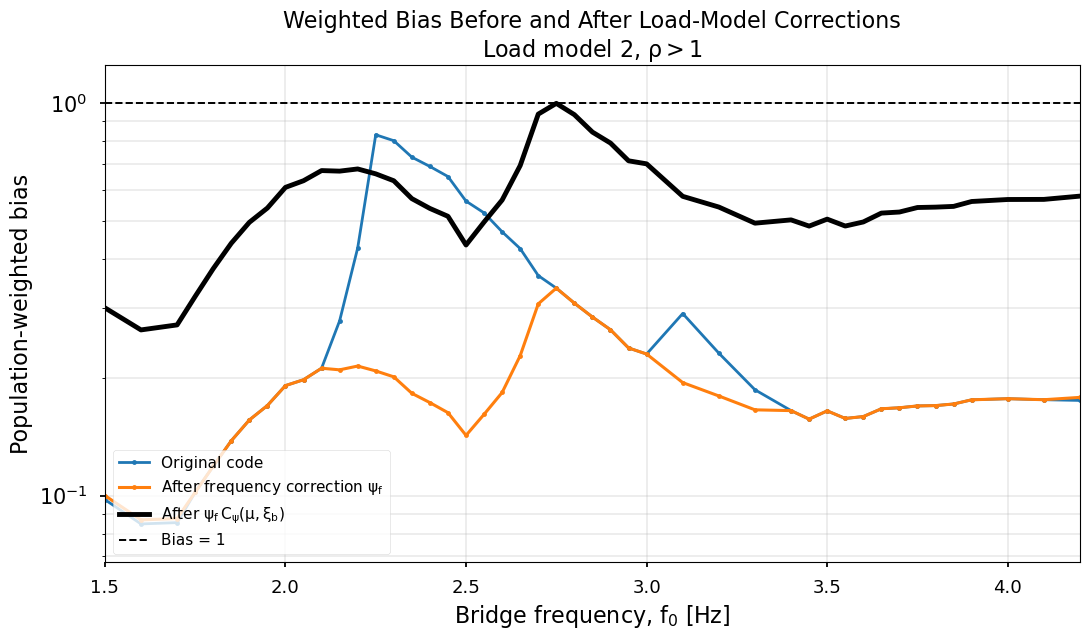


Final check:
max final population-weighted bias = 1.000000000000
PASS: final weighted bias peaks at 1.


In [71]:
# ============================================================
# rho > 1
# POPULATION-WEIGHTED BIAS:
#
# 1. Original code
# 2. After frequency correction psi_env
# 3. After final psi_env * C_psi(mu,xi_b)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# SETTINGS
# ============================================================

FMIN = 1.50
FMAX = 4.20

MU_ROUND = 4
XI_ROUND = 4
FREQ_ROUND = 6


# ============================================================
# CHECK REQUIRED VARIABLES
# ============================================================

required_names = [
    "compare_df",
    "weights_df",
    "a",
    "b",
    "c",
    "d",
]

missing = [
    name for name in required_names
    if name not in globals()
]

if missing:
    raise RuntimeError(
        f"Missing variables: {missing}\n"
        "Run the rho > 1 bias code, population weights, "
        "and final polynomial calibration first."
    )


# ============================================================
# 1. PREPARE rho > 1 DATA
# ============================================================

df = compare_df[
    [
        "bridge_frequency",
        "mass_ratio",
        "damping_key",
        "old_bias",
        "env_bias",
        "psi_env",
    ]
].copy()


for col in [
    "bridge_frequency",
    "mass_ratio",
    "damping_key",
    "old_bias",
    "env_bias",
    "psi_env",
]:

    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )


df = df.dropna().copy()


df = df[
    (df["bridge_frequency"] >= FMIN)
    &
    (df["bridge_frequency"] <= FMAX)
].copy()


# ============================================================
# 2. ROBUST KEYS
# ============================================================

df["mu_key"] = (
    df["mass_ratio"]
    .round(MU_ROUND)
)

df["xi_key"] = (
    df["damping_key"]
    .round(XI_ROUND)
)

df["f_key"] = (
    df["bridge_frequency"]
    .round(FREQ_ROUND)
)


# ============================================================
# 3. COLLAPSE REPEATED lm CASES
#
# One response for each:
#
#       frequency, mu, xi_b
# ============================================================

df = (
    df
    .groupby(
        [
            "f_key",
            "mu_key",
            "xi_key",
        ],
        as_index=False
    )
    .agg(
        bridge_frequency=("bridge_frequency", "mean"),
        mass_ratio=("mass_ratio", "first"),
        xi_b=("damping_key", "first"),
        old_bias=("old_bias", "mean"),
        env_bias=("env_bias", "mean"),
        psi_env=("psi_env", "mean"),
    )
    .sort_values(
        [
            "mu_key",
            "xi_key",
            "bridge_frequency",
        ]
    )
    .reset_index(drop=True)
)


# ============================================================
# 4. PREPARE POPULATION WEIGHTS
# ============================================================

wdf = weights_df[
    [
        "mu",
        "xi_b",
        "weight",
    ]
].copy()


for col in [
    "mu",
    "xi_b",
    "weight",
]:

    wdf[col] = pd.to_numeric(
        wdf[col],
        errors="coerce"
    )


wdf = wdf.dropna().copy()


wdf["mu_key"] = (
    wdf["mu"]
    .round(MU_ROUND)
)

wdf["xi_key"] = (
    wdf["xi_b"]
    .round(XI_ROUND)
)


# ============================================================
# 5. KEEP ONLY COMBINATIONS AVAILABLE IN rho > 1 MODEL
# ============================================================

available_combos = (
    df[
        [
            "mu_key",
            "xi_key",
        ]
    ]
    .drop_duplicates()
)


wdf = wdf.merge(
    available_combos,
    on=[
        "mu_key",
        "xi_key",
    ],
    how="inner"
)


if wdf.empty:
    raise ValueError(
        "No common (mu,xi_b) combinations."
    )


# ------------------------------------------------------------
# Renormalise weights
# ------------------------------------------------------------

wdf["w"] = (
    wdf["weight"]
    /
    wdf["weight"].sum()
)


# ============================================================
# 6. MERGE WEIGHTS
# ============================================================

df = df.merge(
    wdf[
        [
            "mu_key",
            "xi_key",
            "w",
        ]
    ],
    on=[
        "mu_key",
        "xi_key",
    ],
    how="inner"
)


# ============================================================
# 7. FINAL C_psi POLYNOMIAL
#
# Uses final a,b,c,d from previous rho > 1 calibration
# ============================================================

mu = (
    df["mass_ratio"]
    .to_numpy(dtype=float)
)

xi = (
    df["xi_b"]
    .to_numpy(dtype=float)
)


df["C_psi"] = (
    a
    +
    b * mu
    +
    c * xi
    +
    d * mu * xi
)


if np.any(df["C_psi"] <= 0):

    raise ValueError(
        "Final polynomial gives C_psi <= 0."
    )


# ============================================================
# 8. FINAL BIAS AFTER COMPLETE psi CORRECTION
#
# psi_final = psi_env * C_psi
# ============================================================

df["final_bias"] = (
    df["env_bias"]
    /
    df["C_psi"]
)


# ============================================================
# 9. WEIGHTED TERMS
# ============================================================

df["weighted_old"] = (
    df["w"]
    *
    df["old_bias"]
)

df["weighted_env"] = (
    df["w"]
    *
    df["env_bias"]
)

df["weighted_final"] = (
    df["w"]
    *
    df["final_bias"]
)


# ============================================================
# 10. POPULATION-WEIGHTED LINES
# ============================================================

weighted_df = (
    df
    .groupby(
        "f_key",
        as_index=False
    )
    .agg(
        bridge_frequency=(
            "bridge_frequency",
            "mean"
        ),

        old_sum=(
            "weighted_old",
            "sum"
        ),

        env_sum=(
            "weighted_env",
            "sum"
        ),

        final_sum=(
            "weighted_final",
            "sum"
        ),

        weight_sum=(
            "w",
            "sum"
        ),
    )
    .sort_values(
        "bridge_frequency"
    )
)


weighted_df["bias_original"] = (
    weighted_df["old_sum"]
    /
    weighted_df["weight_sum"]
)

weighted_df["bias_psi"] = (
    weighted_df["env_sum"]
    /
    weighted_df["weight_sum"]
)

weighted_df["bias_final"] = (
    weighted_df["final_sum"]
    /
    weighted_df["weight_sum"]
)


# ============================================================
# 11. PRINT MAXIMUM BIASES
# ============================================================

def print_peak(label, column):

    idx = weighted_df[column].idxmax()

    peak = weighted_df.loc[
        idx,
        column
    ]

    freq = weighted_df.loc[
        idx,
        "bridge_frequency"
    ]

    print(
        f"{label:<32s}: "
        f"max bias = {peak:.8f} "
        f"at f = {freq:.4f} Hz"
    )


print("\n============================================================")
print("rho > 1 POPULATION-WEIGHTED BIAS COMPARISON")
print("============================================================\n")

print_peak(
    "Original code",
    "bias_original"
)

print_peak(
    "After frequency-corrected psi",
    "bias_psi"
)

print_peak(
    "After final C_psi correction",
    "bias_final"
)


# ============================================================
# 12. PLOT
# ============================================================

fig, ax = plt.subplots(
    figsize=(11, 6.5)
)


# ------------------------------------------------------------
# Original population-weighted bias
# ------------------------------------------------------------

ax.plot(
    weighted_df["bridge_frequency"],
    weighted_df["bias_original"],
    marker="o",
    markersize=3.5,
    linewidth=2.0,
    label="Original code"
)


# ------------------------------------------------------------
# After psi_env frequency correction
# ------------------------------------------------------------

ax.plot(
    weighted_df["bridge_frequency"],
    weighted_df["bias_psi"],
    marker="o",
    markersize=3.5,
    linewidth=2.2,
    label=r"After frequency correction $\psi_f$"
)


# ------------------------------------------------------------
# After full psi correction:
#
# psi_final = psi_f * C_psi(mu,xi_b)
# ------------------------------------------------------------

ax.plot(
    weighted_df["bridge_frequency"],
    weighted_df["bias_final"],
    linewidth=3.5,
    color="black",
    label=(
        r"After $\psi_f\,C_\psi(\mu,\xi_b)$"
    )
)


# ------------------------------------------------------------
# Bias = 1
# ------------------------------------------------------------

ax.axhline(
    1.0,
    color="black",
    linestyle="--",
    linewidth=1.4,
    label="Bias = 1"
)


# ============================================================
# FORMAT
# ============================================================

ax.set_xlim(
    FMIN,
    FMAX
)


ax.set_yscale(
    "log"
)


all_values = np.concatenate(
    [
        weighted_df["bias_original"].to_numpy(),
        weighted_df["bias_psi"].to_numpy(),
        weighted_df["bias_final"].to_numpy(),
    ]
)


positive_values = (
    all_values[
        np.isfinite(all_values)
        &
        (all_values > 0)
    ]
)


if len(positive_values) > 0:

    ymin = max(
        0.05,
        0.80 * positive_values.min()
    )

    ymax = max(
        1.25,
        1.10 * positive_values.max()
    )

    ax.set_ylim(
        ymin,
        ymax
    )


ax.set_xlabel(
    r"Bridge frequency, $f_0$ [Hz]"
)

ax.set_ylabel(
    "Population-weighted bias"
)


ax.set_title(
    "Weighted Bias Before and After Load-Model Corrections\n"
    r"Load model 2, $\rho > 1$"
)


ax.grid(
    True,
    which="both",
    alpha=0.25
)


ax.legend(
    loc="lower left"
)


plt.tight_layout()
plt.show()


# ============================================================
# 13. FINAL CHECK
# ============================================================

final_max = (
    weighted_df["bias_final"]
    .max()
)


print("\nFinal check:")

print(
    f"max final population-weighted bias = "
    f"{final_max:.12f}"
)


if np.isclose(
    final_max,
    1.0,
    atol=1e-8
):

    print(
        "PASS: final weighted bias peaks at 1."
    )

else:

    print(
        "WARNING: final weighted bias does not peak exactly at 1."
    )

In [34]:
# ============================================================
# AFTER rho < 1 CALIBRATION
# ============================================================

coef_rho_lt1 = {
    "a": a,
    "b": b,
    "c": c,
    "d": d
}

surface_rho_lt1 = surface_df.copy()

print("Saved rho < 1 coefficients:")
print(coef_rho_lt1)

# ============================================================
# AFTER rho > 1 CALIBRATION
# ============================================================

coef_rho_gt1 = {
    "a": a,
    "b": b,
    "c": c,
    "d": d
}

surface_rho_gt1 = surface_df.copy()

print("Saved rho > 1 coefficients:")
print(coef_rho_gt1)

Saved rho < 1 coefficients:
{'a': np.float64(0.3871240917851868), 'b': np.float64(-0.5685058355216042), 'c': np.float64(4.973920103003473), 'd': np.float64(44.314706808251266)}
Saved rho > 1 coefficients:
{'a': np.float64(0.3871240917851868), 'b': np.float64(-0.5685058355216042), 'c': np.float64(4.973920103003473), 'd': np.float64(44.314706808251266)}



rho < 1:
C_psi(mu,xi_b) = 0.38712409 -0.56850584 mu +4.97392010 xi_b +44.31470681 mu xi_b

rho > 1:
C_psi(mu,xi_b) = 0.03874736 +0.02239763 mu +20.98824565 xi_b +75.11809020 mu xi_b


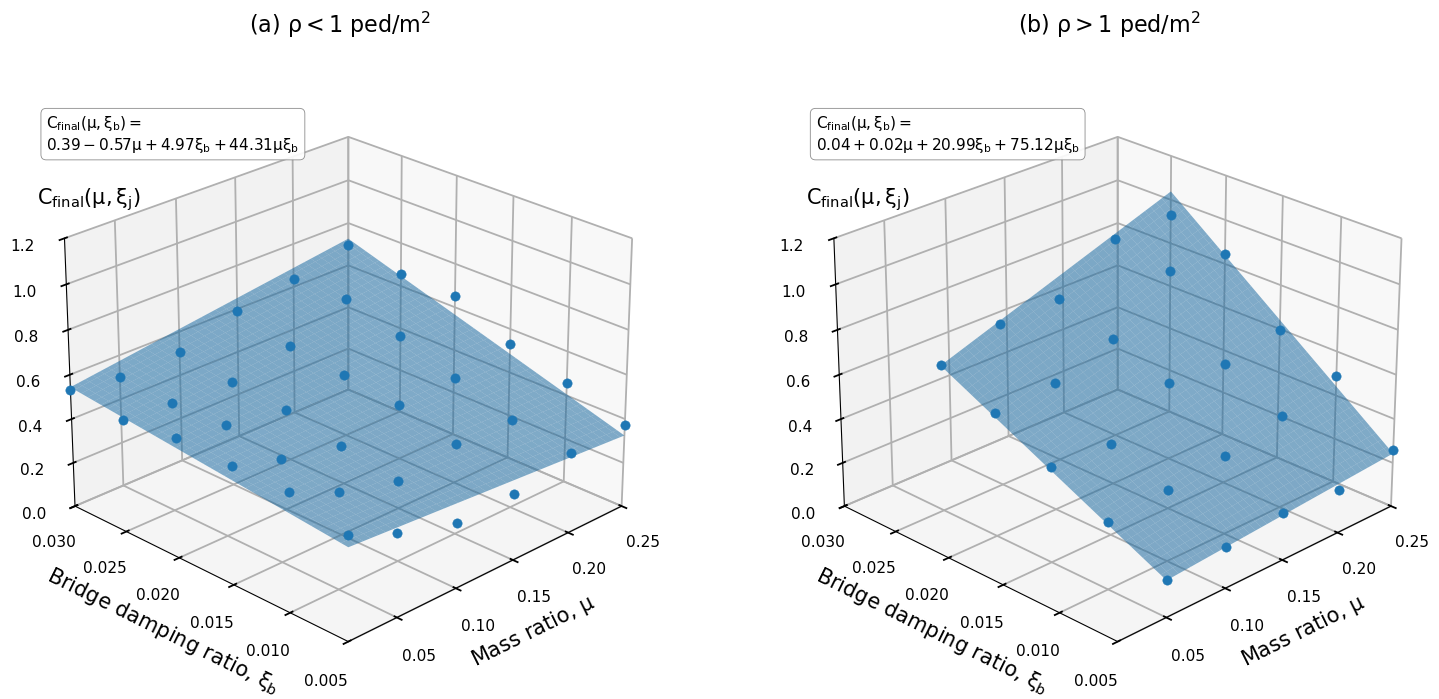

In [58]:
# ============================================================
# SIDE-BY-SIDE POPULATION-CALIBRATED C_psi SURFACES
#
# LEFT  : rho < 1 ped/m^2
# RIGHT : rho > 1 ped/m^2
#
# SAME x, y, z AXES
# z-axis = 0.2 to 1.2 at intervals of 0.2
# EQUATIONS DISPLAYED ON FIGURE
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 0. REQUIRED SAVED RESULTS
# ============================================================
#
# These should have been saved after running each calibration:
#
# AFTER rho < 1:
#
# a_low, b_low, c_low, d_low = a, b, c, d
# surface_low = surface_df.copy()
#
#
# AFTER rho > 1:
#
# a_high, b_high, c_high, d_high = a, b, c, d
# surface_high = surface_df.copy()
#
# ============================================================

required_vars = [
    "a_low",
    "b_low",
    "c_low",
    "d_low",
    "surface_low",
    "a_high",
    "b_high",
    "c_high",
    "d_high",
    "surface_high",
]

for var in required_vars:

    if var not in globals():

        raise NameError(
            f"{var} is not defined. "
            "Save the rho < 1 and rho > 1 results first."
        )


# ============================================================
# 1. PLOT STYLE
# ============================================================

plt.style.use('seaborn-v0_8-talk')

plt.rcParams['font.monospace'] = 'Ubuntu Mono'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 15
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['legend.fontsize'] = 11
plt.rcParams['figure.titlesize'] = 16
plt.rcParams['text.usetex'] = False
plt.rcParams['mathtext.default'] = 'regular'


# ============================================================
# 2. rho < 1 SURFACE
# ============================================================

mu_grid_low = np.linspace(
    surface_low["mu"].min(),
    surface_low["mu"].max(),
    120
)

xi_grid_low = np.linspace(
    surface_low["xi_b"].min(),
    surface_low["xi_b"].max(),
    120
)

MU_low, XI_low = np.meshgrid(
    mu_grid_low,
    xi_grid_low
)

C_low = (
    a_low
    + b_low * MU_low
    + c_low * XI_low
    + d_low * MU_low * XI_low
)


# ============================================================
# 3. rho > 1 SURFACE
# ============================================================

mu_grid_high = np.linspace(
    surface_high["mu"].min(),
    surface_high["mu"].max(),
    120
)

xi_grid_high = np.linspace(
    surface_high["xi_b"].min(),
    surface_high["xi_b"].max(),
    120
)

MU_high, XI_high = np.meshgrid(
    mu_grid_high,
    xi_grid_high
)

C_high = (
    a_high
    + b_high * MU_high
    + c_high * XI_high
    + d_high * MU_high * XI_high
)


# ============================================================
# 4. COMMON X AND Y AXIS LIMITS
# ============================================================

x_all = np.concatenate(
    [
        surface_low["mu"].to_numpy(dtype=float),
        surface_high["mu"].to_numpy(dtype=float)
    ]
)

y_all = np.concatenate(
    [
        surface_low["xi_b"].to_numpy(dtype=float),
        surface_high["xi_b"].to_numpy(dtype=float)
    ]
)


x_min = x_all.min()
x_max = x_all.max()

y_min = y_all.min()
y_max = y_all.max()


# ============================================================
# 5. COMMON X AND Y TICKS
# ============================================================

# Mass ratio
x_ticks = np.arange(
    0.05,
    0.251,
    0.05
)

# Damping ratio
y_ticks = np.arange(
    0.005,
    0.0301,
    0.005
)


# ============================================================
# 6. COMMON Z AXIS
# ============================================================

z_min = 0.0
z_max = 1.2

z_ticks = np.arange(
    0.0,
    1.201,
    0.2
)

z_ticklabels = [
    f"{z:.1f}"
    for z in z_ticks
]


# ============================================================
# 7. EQUATION STRINGS
# ============================================================

eq_low_plot = (
    r"$C_{final}(\mu,\xi_b) =$"
    "\n"
    rf"${a_low:.2f}"
    rf"{b_low:+.2f}\mu"
    rf"{c_low:+.2f}\xi_b"
    rf"{d_low:+.2f}\mu\xi_b$"
)


eq_high_plot = (
    r"$C_{final}(\mu,\xi_b) =$"
    "\n"
    rf"${a_high:.2f}"
    rf"{b_high:+.2f}\mu"
    rf"{c_high:+.2f}\xi_b"
    rf"{d_high:+.2f}\mu\xi_b$"
)


# Also print equations numerically
print(
    "\nrho < 1:\n"
    f"C_psi(mu,xi_b) = "
    f"{a_low:.8f} "
    f"{b_low:+.8f} mu "
    f"{c_low:+.8f} xi_b "
    f"{d_low:+.8f} mu xi_b"
)

print(
    "\nrho > 1:\n"
    f"C_psi(mu,xi_b) = "
    f"{a_high:.8f} "
    f"{b_high:+.8f} mu "
    f"{c_high:+.8f} xi_b "
    f"{d_high:+.8f} mu xi_b"
)


# ============================================================
# 8. FIGURE
# ============================================================

fig = plt.figure(
    figsize=(16, 7.2)
)


# ============================================================
# 9. LEFT PANEL — rho < 1
# ============================================================

ax1 = fig.add_subplot(
    1,
    2,
    1,
    projection="3d"
)


# ------------------------------------------------------------
# Surface
# ------------------------------------------------------------

ax1.plot_surface(
    MU_low,
    XI_low,
    C_low,
    alpha=0.55,
    linewidth=0
)


# ------------------------------------------------------------
# Calibration points
# ------------------------------------------------------------

ax1.scatter(
    surface_low["mu"],
    surface_low["xi_b"],
    surface_low["C_target_population"],
    s=45,
    depthshade=False
)


# ------------------------------------------------------------
# Title
# ------------------------------------------------------------

ax1.set_title(
    r"(a) $\rho < 1$ ped/m$^2$",
    pad=32
)


# ------------------------------------------------------------
# X / Y labels
# ------------------------------------------------------------

ax1.set_xlabel(
    r"Mass ratio, $\mu$",
    labelpad=13
)

ax1.set_ylabel(
    r"Bridge damping ratio, $\xi_b$",
    labelpad=13
)


# ------------------------------------------------------------
# Same x / y / z ranges
# ------------------------------------------------------------

ax1.set_xlim(
    x_min,
    x_max
)

ax1.set_ylim(
    y_min,
    y_max
)

ax1.set_zlim(
    z_min,
    z_max
)


# ------------------------------------------------------------
# Same ticks
# ------------------------------------------------------------

ax1.set_xticks(
    x_ticks
)

ax1.set_yticks(
    y_ticks
)

ax1.set_zticks(
    z_ticks
)

ax1.set_zticklabels(
    z_ticklabels
)


# ------------------------------------------------------------
# Remove automatic vertical z label
# ------------------------------------------------------------

ax1.set_zlabel("")


# ------------------------------------------------------------
# Horizontal C_psi label near top of vertical axis
# ------------------------------------------------------------

ax1.text2D(
    0.005,
    0.80,
    r"$C_{final}(\mu,\xi_j)$",
    transform=ax1.transAxes,
    rotation=0,
    ha="left",
    va="center",
    fontsize=15
)


# ------------------------------------------------------------
# Equation box
# ------------------------------------------------------------

ax1.text2D(
    0.02,
    0.94,
    eq_low_plot,
    transform=ax1.transAxes,
    va="top",
    ha="left",
    fontsize=11,
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="white",
        alpha=0.90,
        edgecolor="gray",
        linewidth=0.6
    )
)


# ------------------------------------------------------------
# Camera angle
# ------------------------------------------------------------

ax1.view_init(
    elev=25,
    azim=-135
)


# ============================================================
# 10. RIGHT PANEL — rho > 1
# ============================================================

ax2 = fig.add_subplot(
    1,
    2,
    2,
    projection="3d"
)


# ------------------------------------------------------------
# Surface
# ------------------------------------------------------------

ax2.plot_surface(
    MU_high,
    XI_high,
    C_high,
    alpha=0.55,
    linewidth=0
)


# ------------------------------------------------------------
# Calibration points
# ------------------------------------------------------------

ax2.scatter(
    surface_high["mu"],
    surface_high["xi_b"],
    surface_high["C_target_population"],
    s=45,
    depthshade=False
)


# ------------------------------------------------------------
# Title
# ------------------------------------------------------------

ax2.set_title(
    r"(b) $\rho > 1$ ped/m$^2$",
    pad=32
)


# ------------------------------------------------------------
# X / Y labels
# ------------------------------------------------------------

ax2.set_xlabel(
    r"Mass ratio, $\mu$",
    labelpad=13
)

ax2.set_ylabel(
    r"Bridge damping ratio, $\xi_b$",
    labelpad=13
)


# ------------------------------------------------------------
# Same x / y / z ranges
# ------------------------------------------------------------

ax2.set_xlim(
    x_min,
    x_max
)

ax2.set_ylim(
    y_min,
    y_max
)

ax2.set_zlim(
    z_min,
    z_max
)


# ------------------------------------------------------------
# Same ticks
# ------------------------------------------------------------

ax2.set_xticks(
    x_ticks
)

ax2.set_yticks(
    y_ticks
)

ax2.set_zticks(
    z_ticks
)

ax2.set_zticklabels(
    z_ticklabels
)


# ------------------------------------------------------------
# Remove automatic vertical z label
# ------------------------------------------------------------

ax2.set_zlabel("")


# ------------------------------------------------------------
# Horizontal C_psi label near top of vertical axis
# ------------------------------------------------------------

ax2.text2D(
    0.005,
    0.80,
    r"$C_{final}(\mu,\xi_j)$",
    transform=ax2.transAxes,
    rotation=0,
    ha="left",
    va="center",
    fontsize=15
)


# ------------------------------------------------------------
# Equation box
# ------------------------------------------------------------

ax2.text2D(
    0.02,
    0.94,
    eq_high_plot,
    transform=ax2.transAxes,
    va="top",
    ha="left",
    fontsize=11,
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="white",
        alpha=0.90,
        edgecolor="gray",
        linewidth=0.6
    )
)


# ------------------------------------------------------------
# Camera angle
# ------------------------------------------------------------

ax2.view_init(
    elev=25,
    azim=-135
)


# ============================================================
# 11. PANEL SPACING
# ============================================================

plt.subplots_adjust(
    left=0.035,
    right=0.985,
    bottom=0.06,
    top=0.91,
    wspace=0.025
)


# ============================================================
# 12. SAVE
# ============================================================

plt.savefig(
    "Cpsi_surfaces_side_by_side.png",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "Cpsi_surfaces_side_by_side.pdf",
    bbox_inches="tight"
)


# ============================================================
# 13. SHOW
# ============================================================

plt.show()

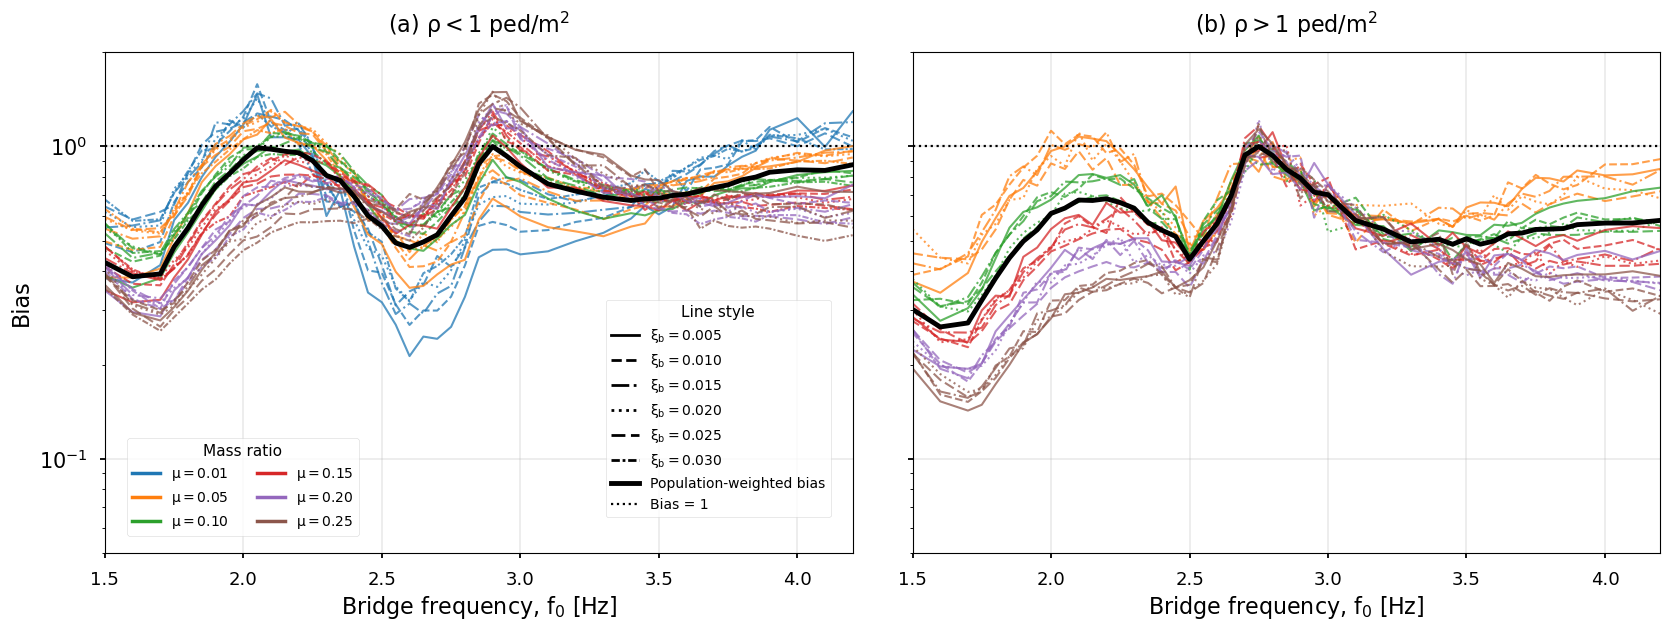

In [78]:
# ============================================================
# FINAL BIAS PLOTS SIDE BY SIDE
#
# LEFT  : rho < 1 ped/m^2
# RIGHT : rho > 1 ped/m^2
#
# Colour     = mass ratio, mu
# Line style = damping ratio, xi_b
# Black      = population-weighted bias
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


# ============================================================
# PLOT STYLE
# ============================================================

plt.style.use('seaborn-v0_8-talk')

plt.rcParams['font.monospace'] = 'Ubuntu Mono'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['xtick.labelsize'] = 13
plt.rcParams['ytick.labelsize'] = 15
plt.rcParams['legend.fontsize'] = 11
plt.rcParams['figure.titlesize'] = 15
plt.rcParams['text.usetex'] = False
plt.rcParams['mathtext.default'] = 'regular'


# ============================================================
# PREPARE COPIES
# ============================================================

low_df = final_df_low.copy()
high_df = final_df_high.copy()


# rho < 1 uses target_beamdamp
low_df["xi_plot"] = low_df["target_beamdamp"]

# rho > 1 uses xi_b
high_df["xi_plot"] = high_df["xi_b"]


# ============================================================
# COMMON mu AND xi LEVELS
# ============================================================

mu_levels = np.sort(
    np.unique(
        np.concatenate([
            low_df["mass_ratio"].to_numpy(dtype=float),
            high_df["mass_ratio"].to_numpy(dtype=float)
        ])
    )
)

xi_levels = np.sort(
    np.unique(
        np.concatenate([
            low_df["xi_plot"].to_numpy(dtype=float),
            high_df["xi_plot"].to_numpy(dtype=float)
        ])
    )
)


# ============================================================
# COMMON COLOURS FOR mu
# ============================================================

base_colors = (
    plt.rcParams["axes.prop_cycle"]
    .by_key()["color"]
)

mu_colors = {
    mu_value:
    base_colors[i % len(base_colors)]

    for i, mu_value
    in enumerate(mu_levels)
}


# ============================================================
# COMMON LINE STYLES FOR xi_b
# ============================================================

line_styles = [
    "-",
    "--",
    "-.",
    ":",
    (0, (5, 2)),
    (0, (3, 1, 1, 1)),
]

xi_styles = {
    xi_value:
    line_styles[i % len(line_styles)]

    for i, xi_value
    in enumerate(xi_levels)
}


# ============================================================
# FIGURE
# ============================================================

fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(17, 6.5),
    sharex=True,
    sharey=True
)


# ============================================================
# FUNCTION TO DRAW INDIVIDUAL BIAS LINES
# ============================================================

def plot_bias_panel(ax, df, weighted_df):

    for mu_value in mu_levels:

        for xi_value in xi_levels:

            sub = df[
                np.isclose(
                    df["mass_ratio"],
                    mu_value
                )
                &
                np.isclose(
                    df["xi_plot"],
                    xi_value
                )
            ].copy()

            if sub.empty:
                continue

            sub = sub.sort_values(
                "bridge_frequency"
            )

            ax.plot(
                sub["bridge_frequency"],
                sub["bias_final"],
                color=mu_colors[mu_value],
                linestyle=xi_styles[xi_value],
                linewidth=1.5,
                alpha=0.75
            )


    # --------------------------------------------------------
    # POPULATION-WEIGHTED BIAS
    # --------------------------------------------------------

    ax.plot(
        weighted_df["bridge_frequency"],
        weighted_df["weighted_bias"],
        color="black",
        linewidth=3.5,
        zorder=10
    )


    # --------------------------------------------------------
    # BIAS = 1
    # --------------------------------------------------------

    ax.axhline(
        1.0,
        color="black",
        linestyle=":",
        linewidth=1.6,
        zorder=9
    )


# ============================================================
# LEFT — rho < 1
# ============================================================

plot_bias_panel(
    ax1,
    low_df,
    weighted_bias_low
)

ax1.set_title(
    r"(a) $\rho < 1$ ped/m$^2$",
    pad=14
)

ax1.set_xlabel(
    r"Bridge frequency, $f_0$ [Hz]"
)

ax1.set_ylabel(
    "Bias"
)


# ============================================================
# RIGHT — rho > 1
# ============================================================

plot_bias_panel(
    ax2,
    high_df,
    weighted_bias_high
)

ax2.set_title(
    r"(b) $\rho > 1$ ped/m$^2$",
    pad=14
)

ax2.set_xlabel(
    r"Bridge frequency, $f_0$ [Hz]"
)


# ============================================================
# COMMON AXES
# ============================================================

for ax in [ax1, ax2]:

    ax.set_xlim(
        1.5,
        4.2
    )

    ax.set_xticks(
        np.arange(
            1.5,
            4.21,
            0.5
        )
    )

    ax.set_yscale(
        "log"
    )

    ax.set_ylim(
        0.05,
        2.0
    )

    ax.grid(
        True,
        alpha=0.25
    )


# ============================================================
# COMMON LEGEND FOR BOTH PANELS
# ============================================================

# ------------------------------------------------------------
# 1. COLOUR LEGEND — MASS RATIO mu
# ------------------------------------------------------------

mu_handles = [
    Line2D(
        [0],
        [0],
        color=mu_colors[mu_value],
        linestyle="-",
        linewidth=2.0,
        label=rf"$\mu={mu_value:.2f}$"
    )
    for mu_value in mu_levels
]


# ------------------------------------------------------------
# 2. LINE-STYLE LEGEND — DAMPING xi_b
# ------------------------------------------------------------

xi_handles = [
    Line2D(
        [0],
        [0],
        color="gray",
        linestyle=xi_styles[xi_value],
        linewidth=2.0,
        label=rf"$\xi_b={xi_value:.3f}$"
    )
    for xi_value in xi_levels
]


# ------------------------------------------------------------
# 3. SPECIAL LINES
# ------------------------------------------------------------

special_handles = [

    Line2D(
        [0],
        [0],
        color="black",
        linewidth=3.5,
        label="Population-weighted bias"
    ),

    Line2D(
        [0],
        [0],
        color="black",
        linestyle=":",
        linewidth=1.6,
        label="Bias = 1"
    )
]


# ============================================================
# COMMON LEGENDS
# Separate:
#   1. Colours  -> mass ratio mu
#   2. Linetypes -> damping ratio xi_b
# ============================================================

# ------------------------------------------------------------
# COLOUR LEGEND: mass ratio
# ------------------------------------------------------------

mu_handles = [
    Line2D(
        [0], [0],
        color=mu_colors[mu_value],
        linestyle="-",
        linewidth=2.5,
        label=rf"$\mu={mu_value:.2f}$"
    )
    for mu_value in mu_levels
]


# ------------------------------------------------------------
# LINE-STYLE LEGEND: damping ratio
# ------------------------------------------------------------

xi_handles = [
    Line2D(
        [0], [0],
        color="black",
        linestyle=xi_styles[xi_value],
        linewidth=2.0,
        label=rf"$\xi_b={xi_value:.3f}$"
    )
    for xi_value in xi_levels
]


# ------------------------------------------------------------
# SPECIAL BLACK LINES
# ------------------------------------------------------------

special_handles = [
    Line2D(
        [0], [0],
        color="black",
        linestyle="-",
        linewidth=3.5,
        label="Population-weighted bias"
    ),
    Line2D(
        [0], [0],
        color="black",
        linestyle=":",
        linewidth=1.6,
        label="Bias = 1"
    )
]


# ============================================================
# LEGENDS INSIDE LEFT PANEL
# ============================================================

# ------------------------------------------------------------
# COLOUR LEGEND: mass ratio
# ------------------------------------------------------------

mu_handles = [
    Line2D(
        [0], [0],
        color=mu_colors[mu_value],
        linestyle="-",
        linewidth=2.5,
        label=rf"$\mu={mu_value:.2f}$"
    )
    for mu_value in mu_levels
]


# ------------------------------------------------------------
# LINE-STYLE LEGEND: damping ratio
# ------------------------------------------------------------

xi_handles = [
    Line2D(
        [0], [0],
        color="black",
        linestyle=xi_styles[xi_value],
        linewidth=2.0,
        label=rf"$\xi_b={xi_value:.3f}$"
    )
    for xi_value in xi_levels
]


# ------------------------------------------------------------
# SPECIAL BLACK LINES
# ------------------------------------------------------------

special_handles = [
    Line2D(
        [0], [0],
        color="black",
        linestyle="-",
        linewidth=3.5,
        label="Population-weighted bias"
    ),
    Line2D(
        [0], [0],
        color="black",
        linestyle=":",
        linewidth=1.6,
        label="Bias = 1"
    )
]


# ------------------------------------------------------------
# FIRST LEGEND: line styles
# place on RIGHT side of left panel
# ------------------------------------------------------------

legend_style = ax1.legend(
    handles=xi_handles + special_handles,
    title="Line style",
    loc="upper right",
    bbox_to_anchor=(0.98, 0.52),
    frameon=True,
    fontsize=10,
    title_fontsize=11
)

ax1.add_artist(legend_style)


# ------------------------------------------------------------
# SECOND LEGEND: colours
# place at LEFT BOTTOM of left panel
# ------------------------------------------------------------

legend_mu = ax1.legend(
    handles=mu_handles,
    title="Mass ratio",
    loc="lower left",
    bbox_to_anchor=(0.02, 0.02),
    ncol=2,
    frameon=True,
    fontsize=10,
    title_fontsize=11
)

# ============================================================
# SPACING
# ============================================================

plt.subplots_adjust(
    left=0.07,
    right=0.985,
    bottom=0.13,
    top=0.90,
    wspace=0.08
)


# ============================================================
# SAVE
# ============================================================

plt.savefig(
    "final_bias_rho_low_high_side_by_side.png",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "final_bias_rho_low_high_side_by_side.pdf",
    bbox_inches="tight"
)


plt.show()

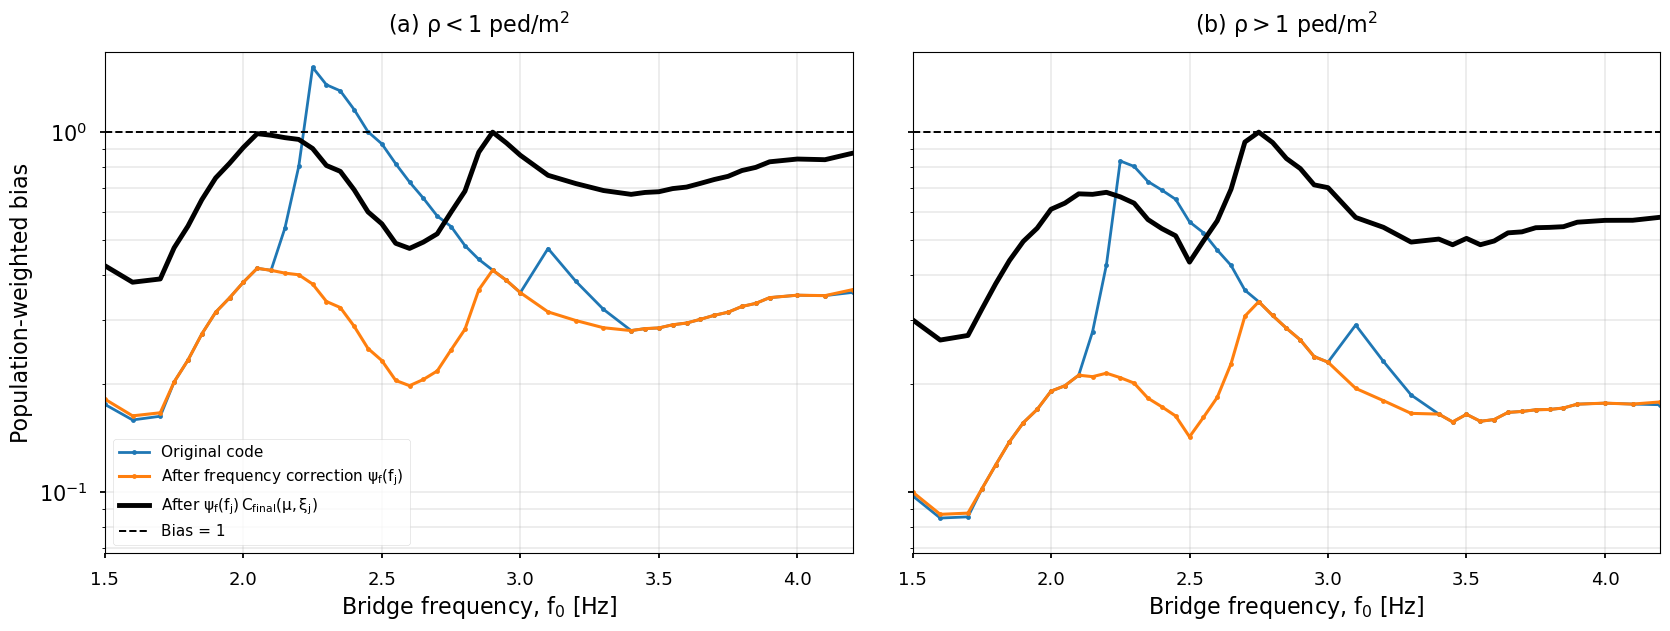

In [72]:
# ============================================================
# POPULATION-WEIGHTED BIAS COMPARISON — SIDE BY SIDE
#
# LEFT  : rho < 1 ped/m^2
# RIGHT : rho > 1 ped/m^2
#
# Shows:
#   1. Original code
#   2. After frequency correction psi_f
#   3. After complete psi_f * C_psi correction
#
# SAME x-axis
# SAME y-axis
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# PLOT STYLE
# ============================================================

plt.style.use('seaborn-v0_8-talk')

plt.rcParams['font.monospace'] = 'Ubuntu Mono'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['xtick.labelsize'] = 13
plt.rcParams['ytick.labelsize'] = 15
plt.rcParams['legend.fontsize'] = 11
plt.rcParams['figure.titlesize'] = 15
plt.rcParams['text.usetex'] = False
plt.rcParams['mathtext.default'] = 'regular'


# ============================================================
# CHECK INPUTS
# ============================================================

if "weighted_comparison_df" not in globals():
    raise RuntimeError(
        "weighted_comparison_df does not exist. "
        "Run the rho < 1 weighted-bias comparison code first."
    )

if "weighted_df" not in globals():
    raise RuntimeError(
        "weighted_df does not exist. "
        "Run the rho > 1 weighted-bias comparison code first."
    )


# ============================================================
# COMMON AXIS SETTINGS
# ============================================================

FMIN = 1.50
FMAX = 4.20


# Get all bias values from BOTH models
all_biases = np.concatenate([
    
    weighted_comparison_df["bias_original"].to_numpy(),
    weighted_comparison_df["bias_psi"].to_numpy(),
    weighted_comparison_df["bias_final"].to_numpy(),

    weighted_df["bias_original"].to_numpy(),
    weighted_df["bias_psi"].to_numpy(),
    weighted_df["bias_final"].to_numpy(),
])


positive_biases = all_biases[
    np.isfinite(all_biases)
    &
    (all_biases > 0)
]


# Same y limits for both plots
ymin = max(
    0.05,
    0.80 * positive_biases.min()
)

ymax = max(
    1.25,
    1.10 * positive_biases.max()
)


# ============================================================
# FIGURE
# ============================================================

fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(17, 6.5),
    sharex=True,
    sharey=True
)


# ============================================================
# LEFT PANEL — rho < 1
# ============================================================

ax1.plot(
    weighted_comparison_df["bridge_frequency"],
    weighted_comparison_df["bias_original"],
    marker="o",
    markersize=3.5,
    linewidth=2.0,
    label="Original code"
)


ax1.plot(
    weighted_comparison_df["bridge_frequency"],
    weighted_comparison_df["bias_psi"],
    marker="o",
    markersize=3.5,
    linewidth=2.2,
    label=r"After frequency correction $\psi_f(f_j)$"
)


ax1.plot(
    weighted_comparison_df["bridge_frequency"],
    weighted_comparison_df["bias_final"],
    color="black",
    linewidth=3.5,
    label=r"After $\psi_f(f_j)\,C_{final}(\mu,\xi_j)$"
)


ax1.axhline(
    1.0,
    color="black",
    linestyle="--",
    linewidth=1.4,
    label="Bias = 1"
)


ax1.set_title(
    r"(a) $\rho < 1$ ped/m$^2$",
    pad=14
)

ax1.set_xlabel(
    r"Bridge frequency, $f_0$ [Hz]"
)

ax1.set_ylabel(
    "Population-weighted bias"
)


# ============================================================
# RIGHT PANEL — rho > 1
# ============================================================

ax2.plot(
    weighted_df["bridge_frequency"],
    weighted_df["bias_original"],
    marker="o",
    markersize=3.5,
    linewidth=2.0,
    label="Original code"
)


ax2.plot(
    weighted_df["bridge_frequency"],
    weighted_df["bias_psi"],
    marker="o",
    markersize=3.5,
    linewidth=2.2,
    label=r"After frequency correction $\psi_f(f_j)$"
)


ax2.plot(
    weighted_df["bridge_frequency"],
    weighted_df["bias_final"],
    color="black",
    linewidth=3.5,
    label=r"After $\psi_f(f_j)\,C_{final}(\mu,\xi_j)$"
)


ax2.axhline(
    1.0,
    color="black",
    linestyle="--",
    linewidth=1.4,
    label="Bias = 1"
)


ax2.set_title(
    r"(b) $\rho > 1$ ped/m$^2$",
    pad=14
)

ax2.set_xlabel(
    r"Bridge frequency, $f_0$ [Hz]"
)


# ============================================================
# SAME AXES FOR BOTH PANELS
# ============================================================

for ax in [ax1, ax2]:

    ax.set_xlim(
        FMIN,
        FMAX
    )

    ax.set_xticks(
        np.arange(
            1.5,
            4.21,
            0.5
        )
    )

    ax.set_yscale(
        "log"
    )

    ax.set_ylim(
        ymin,
        ymax
    )

    ax.grid(
        True,
        which="both",
        alpha=0.25
    )


# ============================================================
# LEGENDS
# ============================================================

ax1.legend(
    loc="lower left",
    frameon=True
)




# ============================================================
# SPACING
# ============================================================

plt.subplots_adjust(
    left=0.07,
    right=0.985,
    bottom=0.13,
    top=0.90,
    wspace=0.08
)


# ============================================================
# SAVE
# ============================================================

plt.savefig(
    "population_weighted_bias_comparison_side_by_side.png",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "population_weighted_bias_comparison_side_by_side.pdf",
    bbox_inches="tight"
)


plt.show()